# DMI Flux Uncertainty Estimation -- Local Variation Analysis (C7b improved)

> Companion script: `model_fittingC7_estimate_variations.py`

> Input fits: stored Phase-2 outputs from `model_fittingC6_improved.py` (the C6 oxidative/dilution branch).

> Notebook role: inspect, summarize, and visualize uncertainty estimates produced by the C7 post-fit analysis.

C6 removes the old branch-split `f_lac` model and no longer fits `V_TCA` independently. The fitted voxel parameters are `MR_glc`, `V_lac_loss`, `V_ox`, and `phi_tca`; derived quantities include `T_max = eta * MR_glc`, `V_lac_source = MR_glc`, `V_TCA_total = V_ox / phi_tca`, and `V_dil_tca = V_TCA_total - V_ox`.


The deprecated aliases `V_lac = V_lac_source` and `V_out = V_lac_loss` may appear in compatibility tables, but they should not be interpreted as the B6 definitions.

## What uncertainty means here

C7 estimates local uncertainty around each stored C6 optimum using a finite-difference Jacobian of the residual-vector surrogate of the C6 loss. It is not a bootstrap and not a full Bayesian posterior; it is a reproducible local identifiability diagnostic.


## 1. Set Up The Workspace

This section loads the numerical and plotting packages, imports the v7 companion module, and prints the
most important file paths. Keeping this setup in one place makes it obvious which artifacts belong to v6
and which belong to v7.

The notebook deliberately imports the v7 companion script instead of duplicating its logic.
That keeps the notebook focused on visualization while the script remains the authoritative implementation.

In [1]:
import sys
from pathlib import Path

from IPython.display import display

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize  # used in Section 7 (Point 3: re-optimization)

NOTEBOOK_DIR = Path('/home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC')
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import model_fittingC7_estimate_variations as m7

DATA_DIR = m7.mf.DATA_DIR
SOURCE_RESULTS_PATH = DATA_DIR / m7.SOURCE_RESULTS_FILENAME
V7_RESULTS_PATH = DATA_DIR / m7.RESULTS_FILENAME
V7_SUMMARY_PATH = DATA_DIR / m7.SUMMARY_FILENAME
PLOTS_DIR = DATA_DIR / 'plotsC7_estimate_variations_oxDilution_KTfixed'
PLOTS_DIR.mkdir(exist_ok=True)

print(f'Using companion module: {m7.MODEL_TAG}')
print(f'Using C6 source fits from: {SOURCE_RESULTS_PATH}')
print(f'Using C7 uncertainty results from: {V7_RESULTS_PATH}')
print(f'Using C7 summary CSV from: {V7_SUMMARY_PATH}')
print(f'Plots will be saved to: {PLOTS_DIR}')

Using companion module: branch_split_noGly_vC7_uncertaintyLocalApprox_oxDilution_KTfixed
Using C6 source fits from: /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/fitC6b_results_MRI_fluxes_AllTissues_noGly_oxDilution_KTfixed.joblib.xz
Using C7 uncertainty results from: /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/fitC7_results_MRI_fluxes_AllTissues_noGly_oxDilution_KTfixed_uncertainty.joblib.xz
Using C7 summary CSV from: /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/fitC7_results_MRI_fluxes_AllTissues_noGly_oxDilution_KTfixed_uncertainty_summary.csv.xz
Plots will be saved to: /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/plotsC7_estimate_variations_oxDilution_KTfixed


## 2. Define Inputs And Configuration

This section defines how aggressively the notebook should try to generate missing uncertainty outputs.
The default is conservative: if the v7 joblib file already exists, load it; otherwise the notebook can
optionally compute it by calling the companion script on demand.

The explicit configuration cell below keeps the expensive actions visible and auditable.
It also separates the completed fits into refined trust tiers so later plots can distinguish between
well-identified fits, merely usable fits, fits that are boundary-sensitive, and fits whose local
approximation is weak or unstable.

In [2]:
def relabel_degraded_fits(results):
    """Relabel fits with n_fd_warnings > 0 and NaN trust_score as 'degraded'.

    Fits 47-w3-dia and 52-w6-norm had numerically unreliable finite-difference
    Jacobians (n_fd_warnings > 0), which caused NaN covariance diagnostics.
    Those two fits silently inherited a label derived from incomplete data.
    This function re-labels them 'degraded' so downstream code can handle them
    separately from fits whose local approximation is merely weak or boundary-sensitive.
    Mutation is in-place so all downstream tier lists see the updated label.
    """
    relabeled = 0
    for result in results:
        diag = result.get('uncertainty', {}).get('covariance_diagnostics', {})
        if not diag:
            continue
        n_fd_warnings = len(diag.get('fd_warnings', []))
        trust_score = diag.get('trust_score', float('nan'))
        if n_fd_warnings > 0 and (trust_score is None or np.isnan(trust_score)):
            diag['trust_label'] = 'degraded'
            relabeled += 1
    print(f'Relabeled {relabeled} fits as degraded (n_fd_warnings > 0 and trust_score = NaN).')
    return results


# If True, the notebook will call the v7 script logic to build the uncertainty output when
# the saved artifact is missing. Keeping this False by default avoids accidental long runs.
RUN_IF_MISSING = False

# Optional subsets allow quick interactive development on only a few samples.
MOUSE_IDS = None
WEEKS = None

if V7_RESULTS_PATH.exists():
    analyzed_results = joblib.load(V7_RESULTS_PATH)
elif RUN_IF_MISSING:
    analyzed_results, _ = m7.run_uncertainty_estimation(
        mouse_ids=set(MOUSE_IDS) if MOUSE_IDS is not None else None,
        weeks=set(WEEKS) if WEEKS is not None else None,
    )
else:
    raise FileNotFoundError(
        f'Missing {V7_RESULTS_PATH}. Set RUN_IF_MISSING = True to build the uncertainty artifact from the notebook.'
    )

analyzed_results = relabel_degraded_fits(analyzed_results)
analyzed_results = m7.apply_group_overrides(analyzed_results)

# Rebuild the summary from loaded results so curated group labels are used even
# when the saved CSV was produced before the mouse 54/56 condition correction.
df_summary = m7.summarize_results(analyzed_results)

well_results = [
    result
    for result in analyzed_results
    if result.get('uncertainty', {}).get('covariance_diagnostics', {}).get('trust_label') == 'well_identified'
    and result.get('include_in_summary', False)
]
usable_results = [
    result
    for result in analyzed_results
    if result.get('uncertainty', {}).get('covariance_diagnostics', {}).get('trust_label') == 'usable'
    and result.get('include_in_summary', False)
]
boundary_results = [
    result
    for result in analyzed_results
    if result.get('uncertainty', {}).get('covariance_diagnostics', {}).get('trust_label') == 'boundary_sensitive'
    and result.get('include_in_summary', False)
]
weak_results = [
    result
    for result in analyzed_results
    if result.get('uncertainty', {}).get('covariance_diagnostics', {}).get('trust_label') == 'weakly_identified'
    and result.get('include_in_summary', False)
]
unstable_results = [
    result
    for result in analyzed_results
    if result.get('uncertainty', {}).get('covariance_diagnostics', {}).get('trust_label') == 'unstable'
    or not result.get('include_in_summary', False)
]
degraded_results = [
    result
    for result in analyzed_results
    if result.get('uncertainty', {}).get('covariance_diagnostics', {}).get('trust_label') == 'degraded'
    and result.get('include_in_summary', False)
]

print(f'Loaded {len(analyzed_results)} uncertainty-enriched fits.')
print(f'Well-identified summary fits: {len(well_results)}')
print(f'Usable summary fits: {len(usable_results)}')
print(f'Boundary-sensitive summary fits: {len(boundary_results)}')
print(f'Weakly identified summary fits: {len(weak_results)}')
print(f'Degraded (NaN-diagnostic) summary fits: {len(degraded_results)}')
print(f'Excluded or unstable fits: {len(unstable_results)}')
display(df_summary.round(3))

Relabeled 0 fits as degraded (n_fd_warnings > 0 and trust_score = NaN).
Loaded 16 uncertainty-enriched fits.
Well-identified summary fits: 0
Usable summary fits: 0
Boundary-sensitive summary fits: 9
Weakly identified summary fits: 4
Degraded (NaN-diagnostic) summary fits: 0
Excluded or unstable fits: 3


,mouseID,week,group,success,include_in_summary,trust_label,trust_score,condition_number,effective_rank,max_abs_corr,n_fd_warnings,n_bound_hits,n_profile_checks,n_profile_issues,sigma2,rss,final_cost
7,53,basal,dia,False,False,boundary_sensitive,0.00,6.379490e+09,67,0.984,7,11,2,2,0.017,13.014,2.799
4,55,basal,dia,True,True,boundary_sensitive,0.00,7.020801e+09,71,0.995,8,11,2,2,0.006,4.497,1.562
0,47,w3,dia,True,True,boundary_sensitive,0.15,3.355529e+09,36,0.990,1,11,2,2,0.014,3.837,1.325
9,48,w3,dia,False,False,weakly_identified,0.30,6.877228e+09,75,0.983,0,2,2,2,0.006,5.917,1.913
14,53,w3,dia,True,True,weakly_identified,0.00,9.373716e+09,99,0.999,5,13,2,2,0.002,3.683,1.434
8,49,w3,norm,True,True,boundary_sensitive,0.00,6.177246e+09,79,0.995,4,15,2,2,0.006,5.694,1.865
13,48,w6,dia,True,True,boundary_sensitive,0.00,6.262812e+09,79,0.996,3,7,2,2,0.005,5.123,1.707
2,54,w6,dia,True,True,boundary_sensitive,0.15,5.875837e+09,67,0.983,1,11,2,2,0.010,8.180,2.239
12,51,w6,norm,True,True,boundary_sensitive,0.20,8.299090e+09,83,0.922,14,23,2,2,0.004,3.971,1.470
5,52,w6,norm,False,False,boundary_sensitive,0.15,6.144351e+09,63,0.993,1,3,2,2,0.008,5.745,1.862


## 3. Implement Core Functions

In notebook terms, the core functions are the reporting helpers that turn the saved uncertainty payload
into compact tables and plots. They do not recompute the covariance. Instead they decode the stored v7
schema into views that are easier to inspect interactively.

The helper functions below now keep six concepts separate:

1. fit-level diagnostics,
2. parameter-level uncertainty summaries,
3. correlation summaries and compact heatmap payloads,
4. profile-slice calibration summaries,
5. voxel and tissue uncertainty summaries,
6. mouse-level group summaries that respect the anti-pseudoreplication rule.

In [3]:
def fit_diagnostic_rows(results):
    rows = []
    for result in results:
        diag = result.get('uncertainty', {}).get('covariance_diagnostics', {})
        rows.append(
            {
                'mouseID': result['mouseID'],
                'week': result['week'],
                'group': result['group'],
                'trust_label': diag.get('trust_label', 'missing'),
                'trust_score': diag.get('trust_score', float('nan')),
                'condition_number': diag.get('condition_number', float('nan')),
                'effective_rank': diag.get('effective_rank', float('nan')),
                'max_abs_corr': diag.get('max_abs_corr', float('nan')),
                'n_bound_hits': len(diag.get('bound_hits', [])),
                'n_fd_warnings': len(diag.get('fd_warnings', [])),
                'n_profile_issues': sum(
                    check.get('profile_label') != 'consistent'
                    for check in result.get('uncertainty', {}).get('profile_checks', [])
                ),
                'sigma2': diag.get('sigma2', float('nan')),
                'rss': diag.get('rss', float('nan')),
                'final_cost': result.get('final_cost', float('nan')),
            }
        )
    return pd.DataFrame(rows).sort_values(['week', 'group', 'mouseID'])


def parameter_summary_rows(results):
    rows = []
    for result in results:
        for row in result.get('uncertainty', {}).get('parameter_summary', []):
            rows.append(
                {
                    'mouseID': result['mouseID'],
                    'week': result['week'],
                    'group': result['group'],
                    **row,
                }
            )
    return pd.DataFrame(rows)


def profile_check_rows(results):
    rows = []
    for result in results:
        for check in result.get('uncertainty', {}).get('profile_checks', []):
            rows.append(
                {
                    'mouseID': result['mouseID'],
                    'week': result['week'],
                    'group': result['group'],
                    'parameter_index': check.get('parameter_index', np.nan),
                    'parameter_label': check.get('parameter_label', ''),
                    'profile_label': check.get('profile_label', ''),
                    'estimate': check.get('estimate', float('nan')),
                    'se': check.get('se', float('nan')),
                    'min_scalar_rise': check.get('min_scalar_rise', float('nan')),
                    'max_abs_log10_ratio': check.get('max_abs_log10_ratio', float('nan')),
                }
            )
    return pd.DataFrame(rows)


def strongest_correlations_table(result):
    rows = []
    for row in result.get('uncertainty', {}).get('top_correlations', []):
        rows.append(
            {
                'corr': row['corr'],
                'abs_corr': row['abs_corr'],
                'left_level': row['left'].get('level', ''),
                'left_name': row['left'].get('name', ''),
                'left_tissue': row['left'].get('tissue', ''),
                'left_voxel_index': row['left'].get('voxel_index', np.nan),
                'right_level': row['right'].get('level', ''),
                'right_name': row['right'].get('name', ''),
                'right_tissue': row['right'].get('tissue', ''),
                'right_voxel_index': row['right'].get('voxel_index', np.nan),
            }
        )
    return pd.DataFrame(rows)


def correlation_heatmap_frame(result):
    payload = result.get('uncertainty', {}).get('correlation_heatmap', {})
    matrix = np.asarray(payload.get('matrix', []), dtype=float)
    labels = payload.get('labels', [])
    if matrix.size == 0:
        return pd.DataFrame()
    return pd.DataFrame(matrix, index=labels, columns=labels)


def build_mouse_level_summary(results):
    """Aggregate per-voxel flux estimates and draw-based uncertainty intervals to mouse-tissue level.

    This function produces one row per (mouseID, week, tissue) combination. For each tissue within
    each mouse-week fit, it:
    1. Collects all per-voxel flux estimates (MR_glc, V_lac_source, V_lac_loss, V_ox, phi_tca, V_TCA_total, V_dil_tca) within that tissue.
    2. Computes the mean flux value across voxels.
    3. Looks up draw-based 95% confidence intervals (2.5th and 97.5th percentiles) for each flux.
    4. Flags whether confidence intervals saturate parameter bounds (indicating the true uncertainty
       extends beyond the feasible region).

    Flux parameters and their units:
    - MR_glc:  glucose consumption rate [mM/min], bounds [0.001, 5.0]
    - phi_tca:   lactate net production fraction (dimensionless), bounds [0.0, 1.0]
    - V_lac:   lactate consumption rate [mM/min], bounds [0.0, 10.0]
    - V_ox:    oxidative TCA rate [mM/min], bounds [0.0, ~20] per tissue
    - V_TCA_total: derived effective TCA/Glx turnover [mM/min]

    V_TCA_total handling: V_TCA_total is derived from V_ox / phi_tca and summarized from C7 draw propagation.

    Parameters
    ----------
    results : list of dict
        Subset of analyzed_results that have include_in_summary=True.

    Returns
    -------
    pd.DataFrame
        One row per (mouseID, week, group, tissue) combination. Columns include:
        - Metadata: mouseID, week, group, tissue, trust_label, fit_converged, n_voxels
        - Tissue params: eta, V_x, KT, fv
        - Flux point estimates: MR_glc, V_lac_source, V_lac_loss, V_ox, phi_tca, V_TCA_total, V_dil_tca (mean across voxels)
        - Draw-based quantiles: *_draw_q025, *_draw_q975 for each flux
        - Saturation flags: *_lower_saturated, *_upper_saturated for MR_glc and phi_tca
    """
    rows = []
    for result in results:
        uncertainty = result.get('uncertainty', {})
        voxel_flux_summary = uncertainty.get('voxel_flux_summary', [])  # per-voxel flux estimates
        draw_summary = uncertainty.get('voxel_draw_summary', [])  # per-voxel MC draw quantiles
        draw_df = pd.DataFrame(draw_summary)
        for tissue_name, tissue_data in result['tissues'].items():
            tissue_voxel_rows = [row for row in voxel_flux_summary if row['tissue'] == tissue_name]
            if not tissue_voxel_rows:
                continue

            # Collect per-voxel flux estimates into buckets by name. Each flux name (e.g., 'MR_glc')
            # is expected to have an 'estimate' key within each voxel row. Defensive: use .get() with
            # None check to gracefully skip missing fields (e.g., V_TCA_total if uncertainty computation
            # skipped it or data predates C7 integration). Missing fluxes report as NaN.
            by_name = {}
            for row in tissue_voxel_rows:
                for name in ['MR_glc', 'V_lac_source', 'V_lac', 'V_lac_loss', 'V_out', 'V_ox', 'phi_tca', 'V_TCA_total', 'V_dil_tca']:
                    item = row.get(name)
                    if item is not None:
                        by_name.setdefault(name, []).append(item['estimate'])

            # Build summary row: tissue-level parameters (constant within tissue) plus
            # voxel-aggregated flux estimates.
            summary_row = {
                'mouseID': result['mouseID'],
                'week': result['week'],
                'group': result['group'],
                'trust_label': result.get('uncertainty', {}).get('covariance_diagnostics', {}).get('trust_label', 'missing'),
                'fit_converged': result.get('success', True),
                'tissue': tissue_name,
                'n_voxels': len(tissue_voxel_rows),
                'eta': tissue_data['eta'],  # transport multiplier used for T_max = eta*MR_glc
                'V_x': tissue_data['V_x'],      # transport rate [mM/min]
                'KT': tissue_data['KT'],        # literature constant (5.8 mM in C7b branch)
                'fv': tissue_data['fv'],        # blood volume fraction [dimensionless]
                # Voxel-aggregated flux estimates: mean across all voxels in tissue.
                # If a flux is missing from all voxels (by_name[name] is empty), report NaN.
                'MR_glc': float(np.mean(by_name['MR_glc'])) if 'MR_glc' in by_name else float('nan'),
                'V_lac_source': float(np.mean(by_name['V_lac_source'])) if 'V_lac_source' in by_name else float('nan'),
                'V_lac_loss': float(np.mean(by_name['V_lac_loss'])) if 'V_lac_loss' in by_name else float('nan'),
                'V_lac': float(np.mean(by_name['V_lac'])) if 'V_lac' in by_name else float('nan'),
                'V_out': float(np.mean(by_name['V_out'])) if 'V_out' in by_name else float('nan'),
                'V_ox': float(np.mean(by_name['V_ox'])) if 'V_ox' in by_name else float('nan'),
                'phi_tca': float(np.mean(by_name['phi_tca'])) if 'phi_tca' in by_name else float('nan'),
                # V_TCA_total point estimate: derived effective TCA/Glx turnover.
                'V_TCA_total': (
                    float(np.mean(by_name['V_TCA_total']))
                    if 'V_TCA_total' in by_name
                    else (
                        float(draw_df[draw_df['tissue'] == tissue_name][draw_df['name'] == 'V_TCA_total']['estimate'].mean())
                        if not draw_df.empty and not draw_df[(draw_df['tissue'] == tissue_name) & (draw_df['name'] == 'V_TCA_total')].empty
                        else float('nan')
                    )
                ),
            }

            # Append draw-based 95% confidence interval quantiles (q025, q975) for each flux.
            # Draw intervals are computed from Monte Carlo samples of the posterior; they reflect
            # the full uncertainty including model parameter uncertainty and measurement noise.
            if not draw_df.empty:
                sub = draw_df[draw_df['tissue'] == tissue_name]
                for name in ['MR_glc', 'V_lac_source', 'V_lac', 'V_lac_loss', 'V_out', 'V_ox', 'phi_tca', 'V_TCA_total', 'V_dil_tca']:
                    name_sub = sub[sub['name'] == name]
                    if not name_sub.empty:
                        # Average the quantiles across voxels (each voxel has its own draw-based CI).
                        summary_row[f'{name}_draw_q025'] = float(name_sub['draw_q025'].mean())
                        summary_row[f'{name}_draw_q975'] = float(name_sub['draw_q975'].mean())
                    else:
                        # No draws available for this flux.
                        summary_row[f'{name}_draw_q025'] = float('nan')
                        summary_row[f'{name}_draw_q975'] = float('nan')

            _sat_tol = 0.001
            for _bname, (_blo, _bhi) in [
                ('MR_glc', m7.mf.BOUNDS_PER_VOX[0]),
                ('V_lac_loss', m7.mf.BOUNDS_PER_VOX[1]),
                ('phi_tca', m7.mf.BOUNDS_PER_VOX[3]),
            ]:
                _span = _bhi - _blo
                _tol  = _sat_tol * _span
                _q975 = summary_row.get(f'{_bname}_draw_q975', float('nan'))
                _q025 = summary_row.get(f'{_bname}_draw_q025', float('nan'))
                summary_row[f'{_bname}_upper_saturated'] = bool(
                    np.isfinite(_q975) and float(_q975) >= _bhi - _tol
                )
                summary_row[f'{_bname}_lower_saturated'] = bool(
                    np.isfinite(_q025) and float(_q025) <= _blo + _tol
                )
            rows.append(summary_row)

    return pd.DataFrame(rows).sort_values(['week', 'group', 'mouseID', 'tissue'])


df_fit_diag = fit_diagnostic_rows(analyzed_results)
df_param = parameter_summary_rows(analyzed_results)
df_profile = profile_check_rows(analyzed_results)
df_mouse = build_mouse_level_summary([
    result for result in analyzed_results if result.get('include_in_summary', False)
])

print(f'Fit diagnostics rows: {len(df_fit_diag)}')
print(f'Parameter summary rows: {len(df_param)}')
print(f'Profile-check rows: {len(df_profile)}')
print(f'Mouse-level uncertainty rows: {len(df_mouse)}')

Fit diagnostics rows: 16
Parameter summary rows: 1157
Profile-check rows: 32
Mouse-level uncertainty rows: 38


## 4. Run The Initial Workflow

The next cells execute the reporting helpers on the loaded uncertainty artifact.
They answer the first practical questions one usually asks after uncertainty estimation:

- which fits look numerically stable versus boundary-sensitive,
- which parameters have the largest local intervals,
- which parameter pairs are strongly correlated,
- whether the saved profile slices look approximately quadratic near the optimum,
- how large the mouse-level uncertainty intervals are for the main reported fluxes.

In [4]:
display(df_fit_diag.round(3))

if not df_param.empty:
    df_param = df_param.copy()
    df_param['ci95_width'] = df_param['ci95_high'] - df_param['ci95_low']
    display(
        df_param.sort_values('ci95_width', ascending=False)[
            ['mouseID', 'week', 'group', 'level', 'tissue', 'voxel_index', 'name', 'estimate', 'se', 'ci95_low', 'ci95_high', 'ci95_width']
        ].head(25).round(4)
    )

if not df_profile.empty:
    display(
        df_profile.sort_values(['profile_label', 'max_abs_log10_ratio'], ascending=[True, False])[
            ['mouseID', 'week', 'group', 'parameter_label', 'profile_label', 'estimate', 'se', 'min_scalar_rise', 'max_abs_log10_ratio']
        ].round(4)
    )

representative_result = None
for candidate in boundary_results + weak_results + usable_results + well_results + analyzed_results:
    if candidate.get('uncertainty', {}).get('top_correlations'):
        representative_result = candidate
        break

if representative_result is not None:
    print(
        f"Representative correlation/profile diagnostics for mouse {representative_result['mouseID']} {representative_result['week']} "
        f"({representative_result['uncertainty']['covariance_diagnostics']['trust_label']})"
    )
    display(strongest_correlations_table(representative_result).round(4))
else:
    print('No correlation rows were available in the loaded uncertainty artifact.')

# Point 5: highlight non-converged fits before the main mouse table.
non_converged = df_mouse[df_mouse['fit_converged'] == False][
    ['mouseID', 'week', 'group', 'tissue', 'fit_converged', 'trust_label']
].drop_duplicates()
if not non_converged.empty:
    print('Non-converged fits (success=False from v6 optimizer) included in the summary:')
    display(non_converged)
else:
    print('All included fits have fit_converged = True.')

# Point 6: formatted interval table with bound-saturation markers.
def format_draw_interval(row, name):
    """Format a draw-based 95 % interval as a string with saturation markers.

    An upper-saturated endpoint is displayed as '>value' (the true upper tail
    extends beyond the bound); a lower-saturated endpoint as '<value'.
    A plain numeric range means neither end is pressing against a constraint.
    """
    q025 = row.get(f'{name}_draw_q025', float('nan'))
    q975 = row.get(f'{name}_draw_q975', float('nan'))
    upper_sat = row.get(f'{name}_upper_saturated', False)
    lower_sat = row.get(f'{name}_lower_saturated', False)
    if not np.isfinite(q025) or not np.isfinite(q975):
        return 'n/a'
    lo_str = f'<{q025:.3f}' if lower_sat else f'{q025:.3f}'
    hi_str = f'>{q975:.3f}' if upper_sat else f'{q975:.3f}'
    return f'[{lo_str}, {hi_str}]'

interval_display_rows = []
for _, row in df_mouse.iterrows():
    interval_display_rows.append({
        'mouseID':           row['mouseID'],
        'week':              row['week'],
        'group':             row['group'],
        'tissue':            row['tissue'],
        'fit_converged':     row['fit_converged'],
        'trust_label':       row['trust_label'],
        'MR_glc_interval':   format_draw_interval(row, 'MR_glc'),
        'phi_tca_interval':  format_draw_interval(row, 'phi_tca'),
        'MR_glc_upper_sat':  row.get('MR_glc_upper_saturated', False),
        'phi_tca_upper_sat': row.get('phi_tca_upper_saturated', False),
    })
df_mouse_display = pd.DataFrame(interval_display_rows)
display(df_mouse_display)

# Numeric table retained for downstream processing.
display(df_mouse.round(4))

,mouseID,week,group,trust_label,trust_score,condition_number,effective_rank,max_abs_corr,n_bound_hits,n_fd_warnings,n_profile_issues,sigma2,rss,final_cost
7,53,basal,dia,boundary_sensitive,0.00,6.379490e+09,67,0.984,11,7,2,0.017,13.014,2.799
4,55,basal,dia,boundary_sensitive,0.00,7.020801e+09,71,0.995,11,8,2,0.006,4.497,1.562
0,47,w3,dia,boundary_sensitive,0.15,3.355529e+09,36,0.990,11,1,2,0.014,3.837,1.325
9,48,w3,dia,weakly_identified,0.30,6.877228e+09,75,0.983,2,0,2,0.006,5.917,1.913
14,53,w3,dia,weakly_identified,0.00,9.373716e+09,99,0.999,13,5,2,0.002,3.683,1.434
8,49,w3,norm,boundary_sensitive,0.00,6.177246e+09,79,0.995,15,4,2,0.006,5.694,1.865
13,48,w6,dia,boundary_sensitive,0.00,6.262812e+09,79,0.996,7,3,2,0.005,5.123,1.707
2,54,w6,dia,boundary_sensitive,0.15,5.875837e+09,67,0.983,11,1,2,0.010,8.180,2.239
12,51,w6,norm,boundary_sensitive,0.20,8.299090e+09,83,0.922,23,14,2,0.004,3.971,1.470
5,52,w6,norm,boundary_sensitive,0.15,6.144351e+09,63,0.993,3,1,2,0.008,5.745,1.862


,mouseID,week,group,level,tissue,voxel_index,name,estimate,se,ci95_low,ci95_high,ci95_width
437,53,basal,dia,tissue,TibialisAnt,NaN,V_x,9.9824,93.8884,-174.0355,194.0003,368.0358
7,47,w3,dia,tissue,Gastrocnemius,NaN,V_x,9.9896,81.1732,-149.1069,169.0861,318.1930
18,47,w3,dia,tissue,Soleus,NaN,V_x,9.9844,69.6308,-126.4894,146.4582,272.9476
467,53,basal,dia,tissue,Soleus,NaN,V_x,8.9810,64.1906,-116.8302,134.7921,251.6223
452,53,basal,dia,tissue,Gastrocnemius,NaN,V_x,3.5062,59.3780,-112.8726,119.8850,232.7576
129,54,w6,dia,tissue,Gastrocnemius,NaN,V_x,9.9123,53.4154,-94.7798,114.6045,209.3843
54,45,w9,dia,tissue,Gastrocnemius,NaN,V_x,9.1922,52.5285,-93.7618,112.1461,205.9079
721,55,w9,dia,tissue,TibialisAnt,NaN,V_x,6.2995,51.1201,-93.8940,106.4931,200.3871
140,54,w6,dia,tissue,Soleus,NaN,V_x,8.3839,48.4540,-86.5841,103.3520,189.9362
43,45,w9,dia,tissue,TibialisAnt,NaN,V_x,8.9797,48.0521,-85.2007,103.1602,188.3609


,mouseID,week,group,parameter_label,profile_label,estimate,se,min_scalar_rise,max_abs_log10_ratio
21,56,w9,dia,"Soleus:v3:V_ox@(6, 8)",consistent,1.5496,20.9848,0.0025,0.2652
24,51,w6,norm,global:plasma_w,nonquadratic,0.7005,0.0822,0.0009,9.9365
25,51,w6,norm,"Soleus:v4:phi_tca@(7, 10)",nonquadratic,0.6007,0.3462,-0.0008,9.3875
5,54,w6,dia,"TibialisAnt:v5:V_ox@(6, 6)",nonquadratic,1.5283,7.4374,-0.0005,9.1651
1,47,w3,dia,"Gastrocnemius:v1:V_ox@(5, 12)",nonquadratic,1.9820,12.3070,0.0000,8.9349
3,45,w9,dia,"Gastrocnemius:v2:V_ox@(10, 9)",nonquadratic,1.5984,5.8171,0.0000,8.8134
8,55,basal,dia,Gastrocnemius:V_x,nonquadratic,5.8690,16.7620,-0.0007,8.5469
13,51,w9,norm,"Soleus:v5:V_ox@(9, 10)",nonquadratic,1.3808,24.0290,-0.0008,7.9989
23,55,w9,dia,"Soleus:v5:phi_tca@(4, 10)",nonquadratic,0.9091,3.5863,-0.0010,7.3626
10,52,w6,norm,TibialisAnt:V_x,nonquadratic,7.4707,47.8792,-0.0002,7.2955


Representative correlation/profile diagnostics for mouse 47 w3 (boundary_sensitive)


,corr,abs_corr,left_level,left_name,left_tissue,left_voxel_index,right_level,right_name,right_tissue,right_voxel_index
0,-0.9905,0.9905,voxel,V_lac_loss,Gastrocnemius,1.0,voxel,V_ox,Gastrocnemius,1.0
1,-0.9793,0.9793,voxel,V_lac_loss,Soleus,3.0,voxel,V_ox,Soleus,3.0
2,-0.8751,0.8751,voxel,V_lac_loss,Soleus,2.0,voxel,V_ox,Soleus,2.0
3,0.8734,0.8734,tissue,eta,Gastrocnemius,NaN,tissue,eta,Soleus,NaN
4,-0.8379,0.8379,voxel,V_lac_loss,Soleus,1.0,voxel,V_ox,Soleus,1.0
5,0.8257,0.8257,voxel,V_lac_loss,Soleus,3.0,voxel,phi_tca,Soleus,3.0
6,-0.8192,0.8192,voxel,V_ox,Soleus,3.0,voxel,phi_tca,Soleus,3.0
7,-0.8056,0.8056,tissue,V_x,Soleus,NaN,voxel,V_ox,Soleus,0.0
8,0.7898,0.7898,voxel,MR_glc,Soleus,0.0,voxel,MR_glc,Soleus,3.0
9,0.7821,0.7821,voxel,MR_glc,Soleus,0.0,voxel,MR_glc,Soleus,2.0


All included fits have fit_converged = True.


,mouseID,week,group,tissue,fit_converged,trust_label,MR_glc_interval,phi_tca_interval,MR_glc_upper_sat,phi_tca_upper_sat
0,55,basal,dia,Gastrocnemius,True,boundary_sensitive,"[<0.001, >5.000]","[<0.200, >1.000]",True,True
1,55,basal,dia,Soleus,True,boundary_sensitive,"[0.073, 4.267]","[<0.200, >1.000]",False,True
2,55,basal,dia,TibialisAnt,True,boundary_sensitive,"[0.088, 4.963]","[0.233, >1.000]",False,True
3,47,w3,dia,Gastrocnemius,True,boundary_sensitive,"[<0.001, 4.043]","[<0.200, >1.000]",False,True
4,47,w3,dia,Soleus,True,boundary_sensitive,"[0.052, 4.523]","[<0.200, >1.000]",False,True
5,53,w3,dia,Gastrocnemius,True,weakly_identified,"[<0.001, >5.000]","[0.653, >1.000]",True,True
6,53,w3,dia,Soleus,True,weakly_identified,"[<0.003, 4.768]","[0.274, >1.000]",False,True
7,53,w3,dia,TibialisAnt,True,weakly_identified,"[0.143, 2.823]","[0.212, >1.000]",False,True
8,49,w3,norm,Gastrocnemius,True,boundary_sensitive,"[<0.001, >5.000]","[0.584, >1.000]",True,True
9,49,w3,norm,Soleus,True,boundary_sensitive,"[<0.001, >5.000]","[0.519, >1.000]",True,True


,mouseID,week,group,trust_label,fit_converged,tissue,n_voxels,eta,V_x,KT,...,V_TCA_total_draw_q025,V_TCA_total_draw_q975,V_dil_tca_draw_q025,V_dil_tca_draw_q975,MR_glc_upper_saturated,MR_glc_lower_saturated,V_lac_loss_upper_saturated,V_lac_loss_lower_saturated,phi_tca_upper_saturated,phi_tca_lower_saturated
12,55,basal,dia,boundary_sensitive,True,Gastrocnemius,3,1.0000,5.8690,5.8,...,0.0000,10.0000,0.0,8.0000,True,True,True,True,True,True
13,55,basal,dia,boundary_sensitive,True,Soleus,7,1.0084,7.6969,5.8,...,0.0000,10.0000,0.0,8.0000,False,False,True,True,True,True
11,55,basal,dia,boundary_sensitive,True,TibialisAnt,4,1.4460,9.4348,5.8,...,0.0000,9.0054,0.0,7.0060,False,False,False,True,True,False
0,47,w3,dia,boundary_sensitive,True,Gastrocnemius,2,1.4020,9.9896,5.8,...,0.0000,10.0000,0.0,8.0000,False,True,True,True,True,True
1,47,w3,dia,boundary_sensitive,True,Soleus,4,1.2971,9.9844,5.8,...,0.0000,9.2927,0.0,7.2927,False,False,True,True,True,True
33,53,w3,dia,weakly_identified,True,Gastrocnemius,3,1.0047,5.7446,5.8,...,0.0000,3.7142,0.0,1.7291,True,True,True,True,True,False
34,53,w3,dia,weakly_identified,True,Soleus,9,1.0000,8.8194,5.8,...,0.0000,7.6699,0.0,5.7609,False,True,True,True,True,False
32,53,w3,dia,weakly_identified,True,TibialisAnt,9,1.1813,4.9528,5.8,...,0.0000,9.6167,0.0,7.6167,False,False,False,True,True,False
18,49,w3,norm,boundary_sensitive,True,Gastrocnemius,5,1.0296,8.9630,5.8,...,0.0000,4.3401,0.0,2.3447,True,True,True,True,True,False
19,49,w3,norm,boundary_sensitive,True,Soleus,6,1.0014,9.1504,5.8,...,0.3333,5.2911,0.0,3.2919,True,True,False,True,True,False


## Status of Diagnostic Notes In The C7b Branch

The diagnostic notes below were written for the v7 analysis (v6 fits with `KT`
fitted). In the C7b branch the situation is:

| Point | What it asks for | Status in C7b |
|-------|------------------|---------------|
| 1 | Reparameterize / fix `KT` | **Done in C6** -- `KT` fixed at 5.8 mM literature value. |
| 2 | Profile-likelihood CIs    | Done in 7b (Section 6 below); inherited unchanged. |
| 3 | Multi-start re-optimization for saddle points | Done in 7b (Section 7 below); inherited unchanged. |
| 4 | `degraded` trust tier for NaN diagnostics | Done in 7b (Section 2); inherited unchanged. |
| 5 | `fit_converged` column                    | Done in 7b (Section 3); inherited unchanged. |
| 6 | Bound-saturation markers                  | Done in 7b (Section 3/4); inherited unchanged. |
| 7 | Share `KT` across tissues                 | **Done in C6** -- a constant is the strongest possible sharing. |
| 8 | Tissue-mean-only parameterization         | Not implemented; kept per-voxel for spatial resolution. |

The original 7b diagnostic narrative follows below. Numbers cited there
(condition numbers, top-25 widest CIs, etc.) refer to the v6/v7 run; rerun
this notebook against C6/C7 outputs to obtain the corresponding C7b numbers.

---

## Diagnostic Notes and Suggested Improvements for Next Iteration

### Summary of observations from the v7 uncertainty analysis

#### Overall trust-tier result
- **0 fits reached `well_identified` or `usable`.**  All 16 fits landed in `boundary_sensitive` (7) or
  `weakly_identified` (9).  This is a global failure of identifiability, not an isolated outlier problem.
- Condition numbers are uniformly ~3–9 × 10⁹ and `max_abs_corr` is 0.996–1.000 across all fits —
  near-perfect collinearity in the parameter space.

#### The KT / V_x identifiability problem
- The top-25 widest-CI parameters are almost exclusively `KT` and `V_x` at the tissue level,
  with SE/estimate ratios of 2–10×.
- Because both parameters appear only as `V_x · S / (KT + S)`, many (KT, V_x) pairs are
  nearly interchangeable given the range of in-vivo glucose concentrations in the experiment.
  This algebraic collinearity cannot be fixed by adjusting bounds or convergence settings.
- `ci95_low` goes negative for both parameters (e.g. KT = 22.4 ± 55.2, ci95_low = −85.8)
  because the Gaussian approximation does not respect physical positivity constraints.
  These CIs should not be interpreted as meaningful uncertainty estimates.

#### Profile-slice calibration: mostly nonquadratic
- Only 2 of 28 profile slices are labelled `consistent`.
- 22/28 are `nonquadratic` with `max_abs_log10_ratio` ≈ 5–9, meaning the actual objective is
  nearly flat over the slice range while the local Hessian implies curvature.
  This confirms the Gaussian SE drastically misrepresents the true uncertainty shape.
- 4 slices are `slice_improves_away_from_optimum` (negative `min_scalar_rise`) for V_out and V_x
  parameters in mice 56-w9, 51-w9, 55-basal, 49-w9.  These are saddle-point or boundary-stop
  artefacts: the optimizer halted at a constraint edge, not a true local minimum.

#### Draw intervals spanning the full parameter space
- For most mice, the draw-based intervals are:
  `MR_glc` [0.001, 5.0], `phi_tca` [0.0, 1.0], `V_lac` [0.0, 10.0], `V_ox` [0.0, ~5–10].
  These span essentially the entire allowed range.  The draws are providing little information
  beyond "the data does not rule out any value in the feasible space".
- `MR_glc_draw_q975 = 5.0` (the bound) in the majority of rows, confirming the posterior
  saturates the upper bound rather than being shaped by the data.

#### Bound hits
- `n_bound_hits` ranges 0–8 per fit.  Mouse 54-w6-norm has 8 bound hits.
  `slice_improves_away_from_optimum` cases overlap with high-bound-hit fits.

#### Two fits with NaN diagnostics
- Mouse 47-w3-dia and 52-w6-norm have `trust_score = NaN`, `effective_rank = NaN`,
  `max_abs_corr = NaN`.  Both had `n_fd_warnings > 0`, indicating the finite-difference
  Jacobian computation was numerically unreliable for at least one parameter.
  These two fits should be flagged as `degraded` rather than silently reporting NaN.

#### One fit with `success = False`
- Mouse 51-w6-norm has `success = False` from the v6 optimizer but is still included in
  the summary with label `boundary_sensitive`.  This should be distinguished from fits that
  converged successfully but hit bounds.

#### Dominant source of correlations
- All top-20 strongest correlations are between the **same flux name across different voxels**
  within the same tissue (e.g. `MR_glc` voxel 0 vs voxel 1 in Gastrocnemius, corr ≈ 0.997).
  This is expected: tissue-level parameters (KT, V_x, eta) drive all voxels together,
  so voxels within a tissue are not independent measurements for the purpose of uncertainty.

---

### Suggested improvements for the next iteration

#### 1  Reparameterize to break KT / V_x collinearity (change for model_fitting6)
- Replace (KT, V_x) with the identifiable combination `V_x / KT` (the apparent first-order
  transport coefficient at low [glc]) plus a separate saturation indicator.
  Alternatively, fix KT to a literature value and fit only V_x (or vice versa).
- This is the single change most likely to improve identifiability across all fits.

#### 2  Use profile-likelihood CIs instead of Gaussian CIs (change for model_fitting7)
- Given that 22/28 profile slices are `nonquadratic`, the ±1.96×SE intervals are not valid.
  Compute and report profile-likelihood confidence intervals (walk the profile until the
  objective rises by the chi² threshold) for at least the tissue-level parameters KT, V_x, T_max.

#### 3  Address `slice_improves_away_from_optimum` by multi-start re-optimization (change for model_fitting7)
- The 4 cases where the profile slice descends from the stored optimum are optimizer artefacts.
  Add a targeted re-optimization pass for any fit that has `min_scalar_rise < −threshold`
  (suggest −0.003 based on the four cases above), starting from the perturbed point.

#### 4  Add a `degraded` trust tier for NaN-diagnostic fits (change for model_fitting7)
- Fits with `n_fd_warnings > 0` and resulting NaN covariance diagnostics should be labelled
  `degraded` rather than inheriting a label derived from partial data.  Their CIs should be
  suppressed or shown with a warning in all downstream plots.

#### 5  Flag `success = False` separately in the mouse-level table (change for model_fitting7)
- Add a `fit_converged` boolean column to `df_mouse` so downstream plots can mark or exclude
  the one non-converged fit (51-w6-norm) distinctly from converged-but-boundary fits.

#### 6  Report draw-bound-saturation explicitly (change for model_fitting7)
- Add a column `n_draws_at_upper_bound` / `n_draws_at_lower_bound` (count of MC draws
  within one step of the parameter bound) to the mouse-level summary.
  Intervals that saturate the bound should be displayed as `> X` or `< Y` rather than as
  a precise numeric range.

#### 7  Consider sharing KT / V_x across tissues or time points (change for model_fitting6)
- If biological reasoning supports a common KT per animal (or per group), fitting a shared
  KT across tissues within a mouse would dramatically reduce the dimensionality of the
  unidentified subspace and lower the condition number.

#### 8  Investigate whether the voxel-pooling rule hides within-tissue heterogeneity (change for model_fitting6)
- All top correlations are voxel-to-voxel within the same tissue at ~0.997.
  If tissue-level parameters are shared, the individual-voxel V_out parameters add
  parameters without adding independent information.  Consider whether a
  tissue-mean-only parameterization (no per-voxel metabolic rates) would be more
  identifiable at the cost of spatial resolution.

### Correlation And Profile Panels

The next cell renders two higher-information diagnostics for a selected fit.
The compact correlation heatmap focuses on the most uncertain parameters rather than every parameter in the model,
and the profile-slice panel checks whether the local quadratic approximation is behaving plausibly near the optimum.

These are calibration views: they help judge whether the saved covariance is merely usable, boundary-sensitive, or
genuinely weak around a specific mouse-week fit.

Fit quality ranking (best to worst):
   1. mouse  56 w9    (dia )  tier=boundary_sensitive    trust_score=0.30  n_bound_hits=2  final_cost=1.803
   2. mouse  49 w9    (norm)  tier=boundary_sensitive    trust_score=0.30  n_bound_hits=7  final_cost=1.958
   3. mouse  45 w9    (dia )  tier=boundary_sensitive    trust_score=0.20  n_bound_hits=13  final_cost=1.152
   4. mouse  51 w6    (norm)  tier=boundary_sensitive    trust_score=0.20  n_bound_hits=23  final_cost=1.470
   5. mouse  47 w3    (dia )  tier=boundary_sensitive    trust_score=0.15  n_bound_hits=11  final_cost=1.325
   6. mouse  54 w6    (dia )  tier=boundary_sensitive    trust_score=0.15  n_bound_hits=11  final_cost=2.239
   7. mouse  48 w6    (dia )  tier=boundary_sensitive    trust_score=0.00  n_bound_hits=7  final_cost=1.707
   8. mouse  55 basal (dia )  tier=boundary_sensitive    trust_score=0.00  n_bound_hits=11  final_cost=1.562
   9. mouse  49 w3    (norm)  tier=boundary_sensitive    trust_score=0.00  n_bound_hits=15  fi

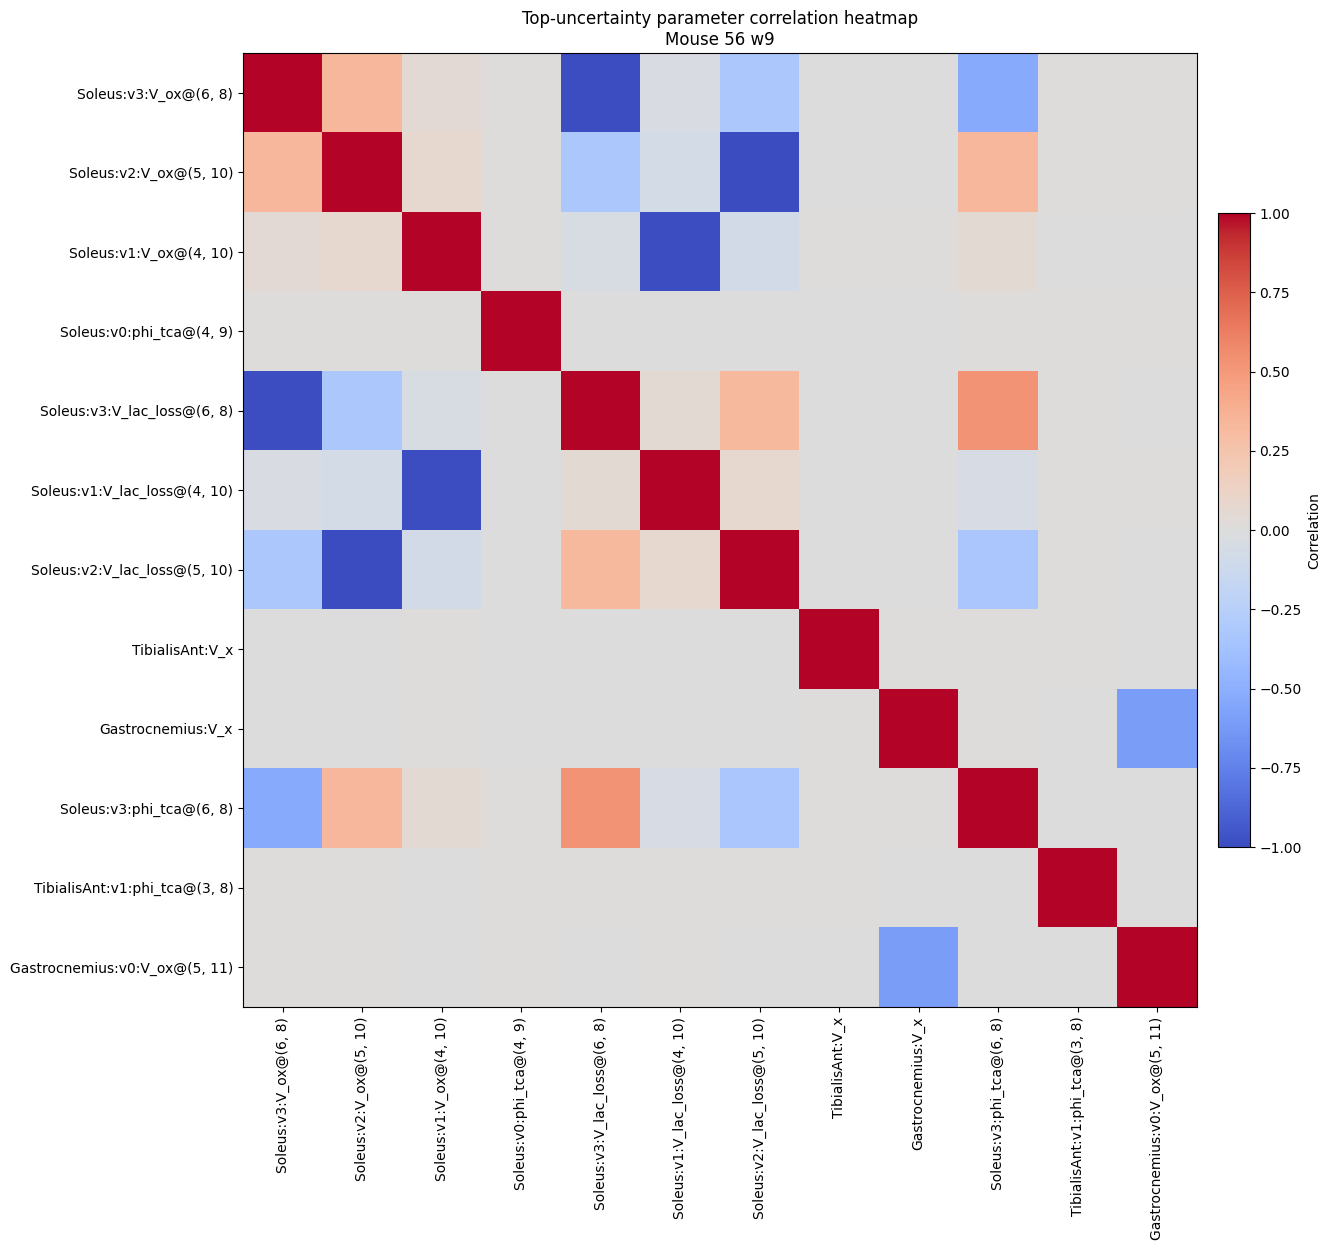

Saved correlation_heatmap_mouse56_w9.png


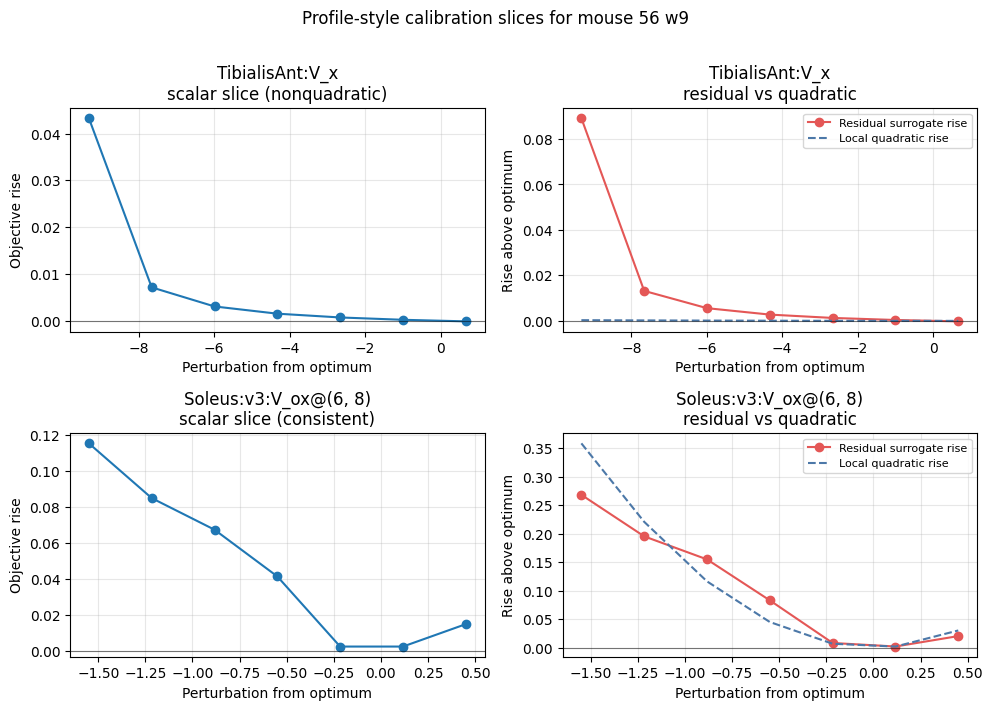

Saved profile_slices_mouse56_w9.png


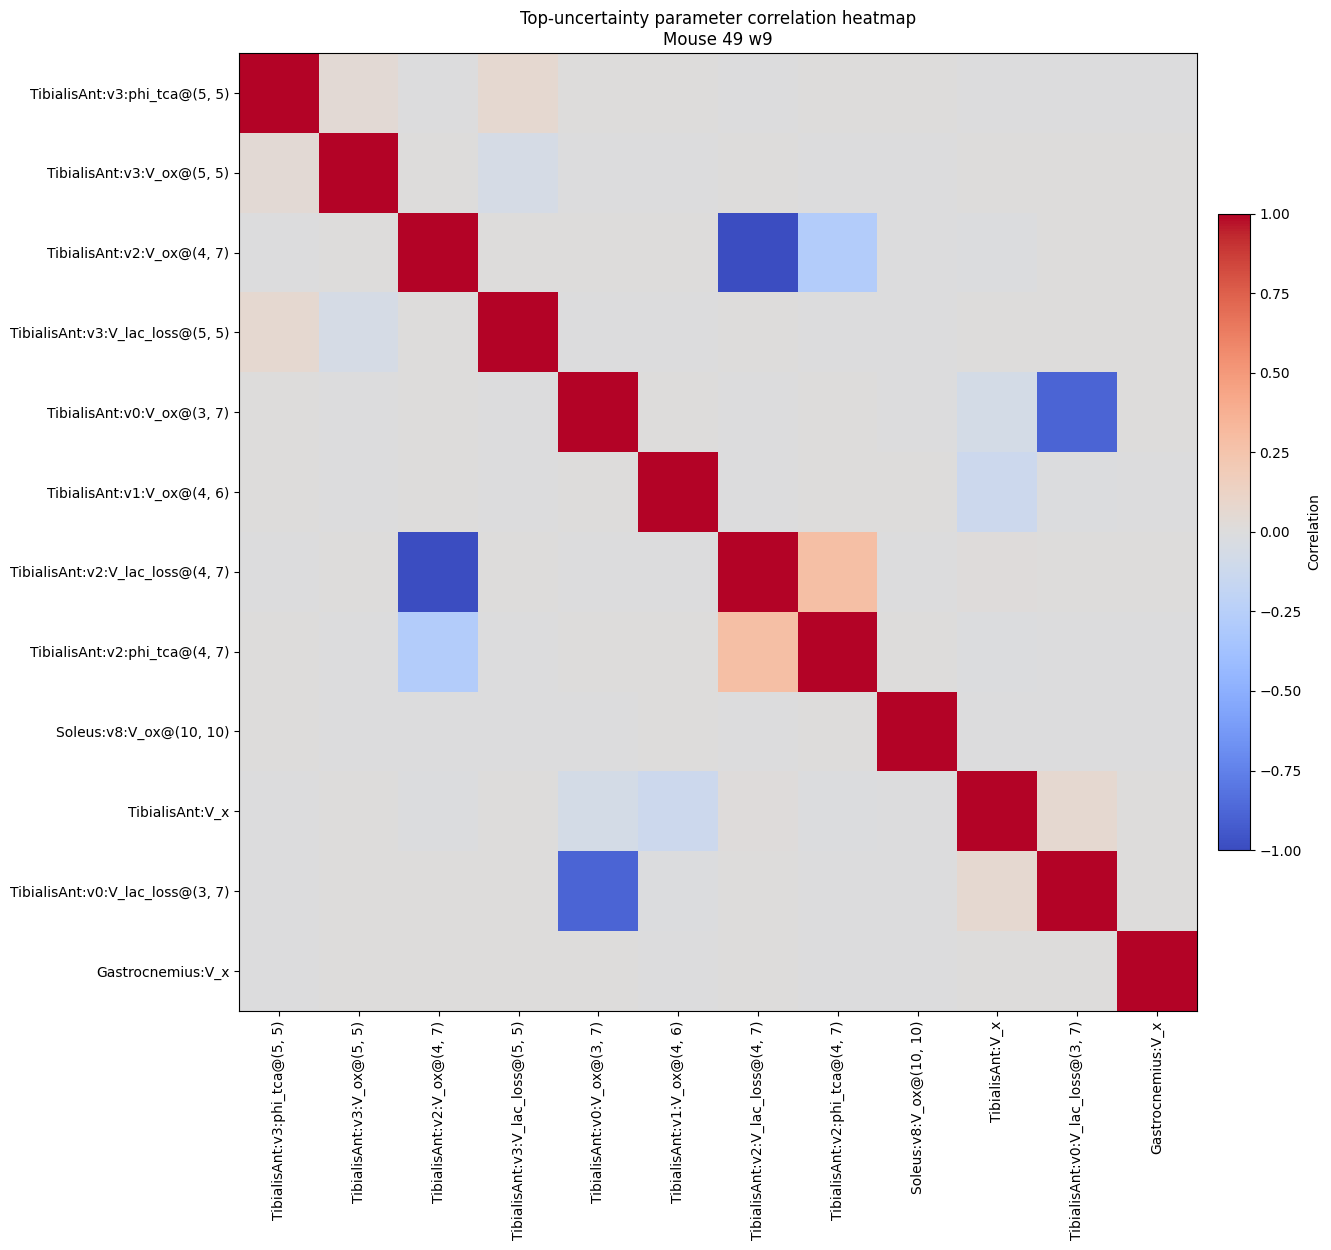

Saved correlation_heatmap_mouse49_w9.png


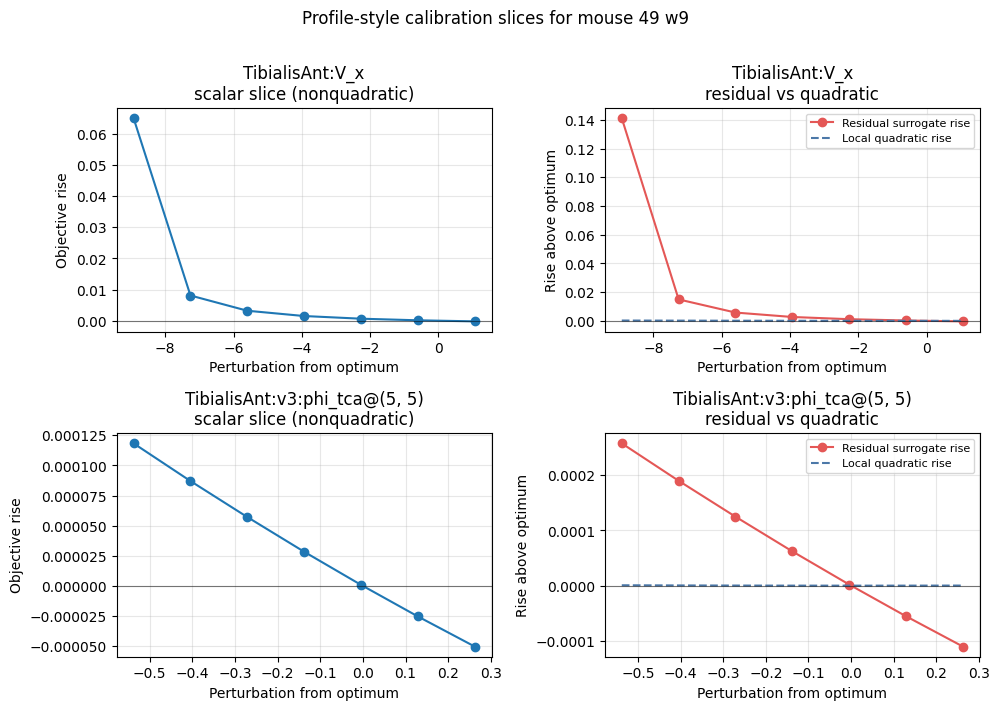

Saved profile_slices_mouse49_w9.png


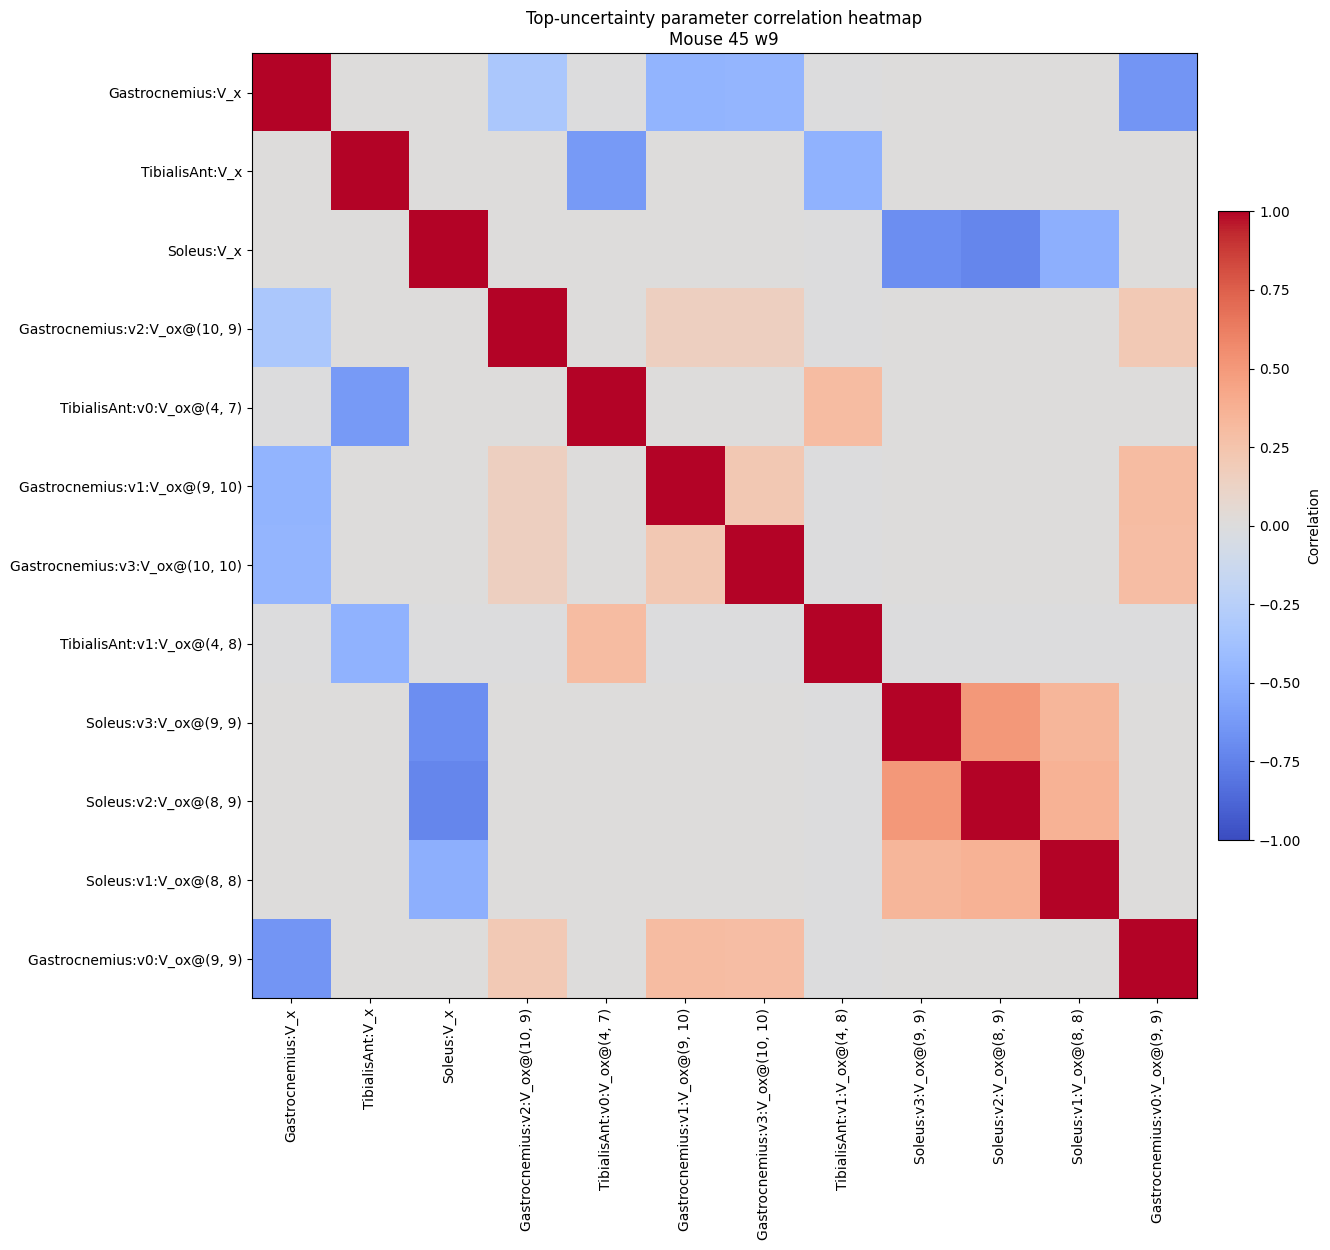

Saved correlation_heatmap_mouse45_w9.png


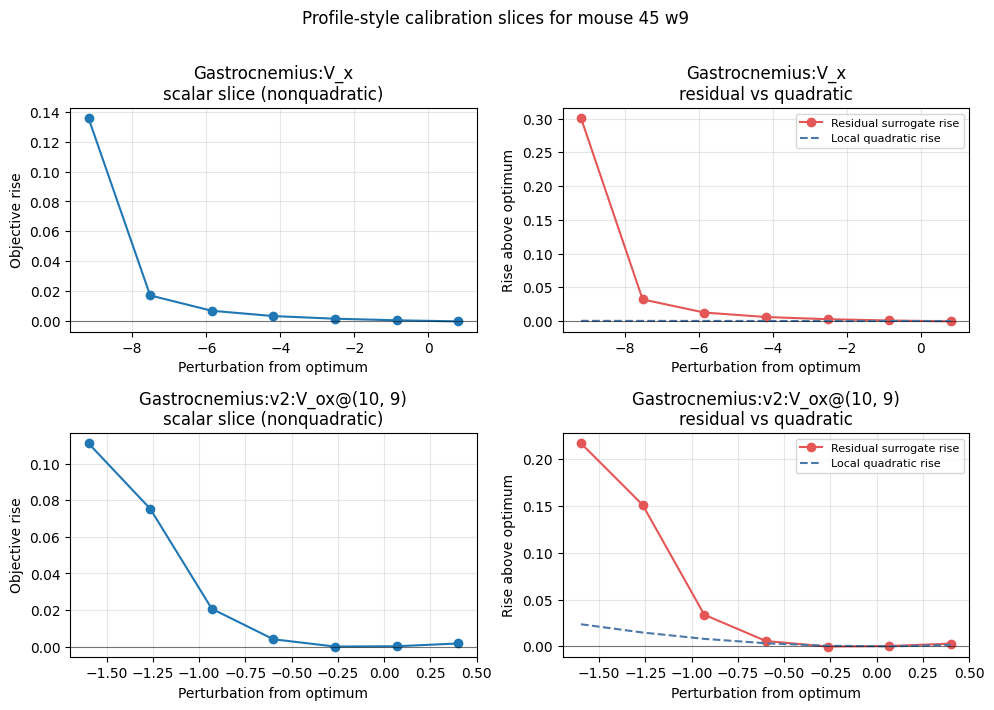

Saved profile_slices_mouse45_w9.png

--- WORST 3 fits ---


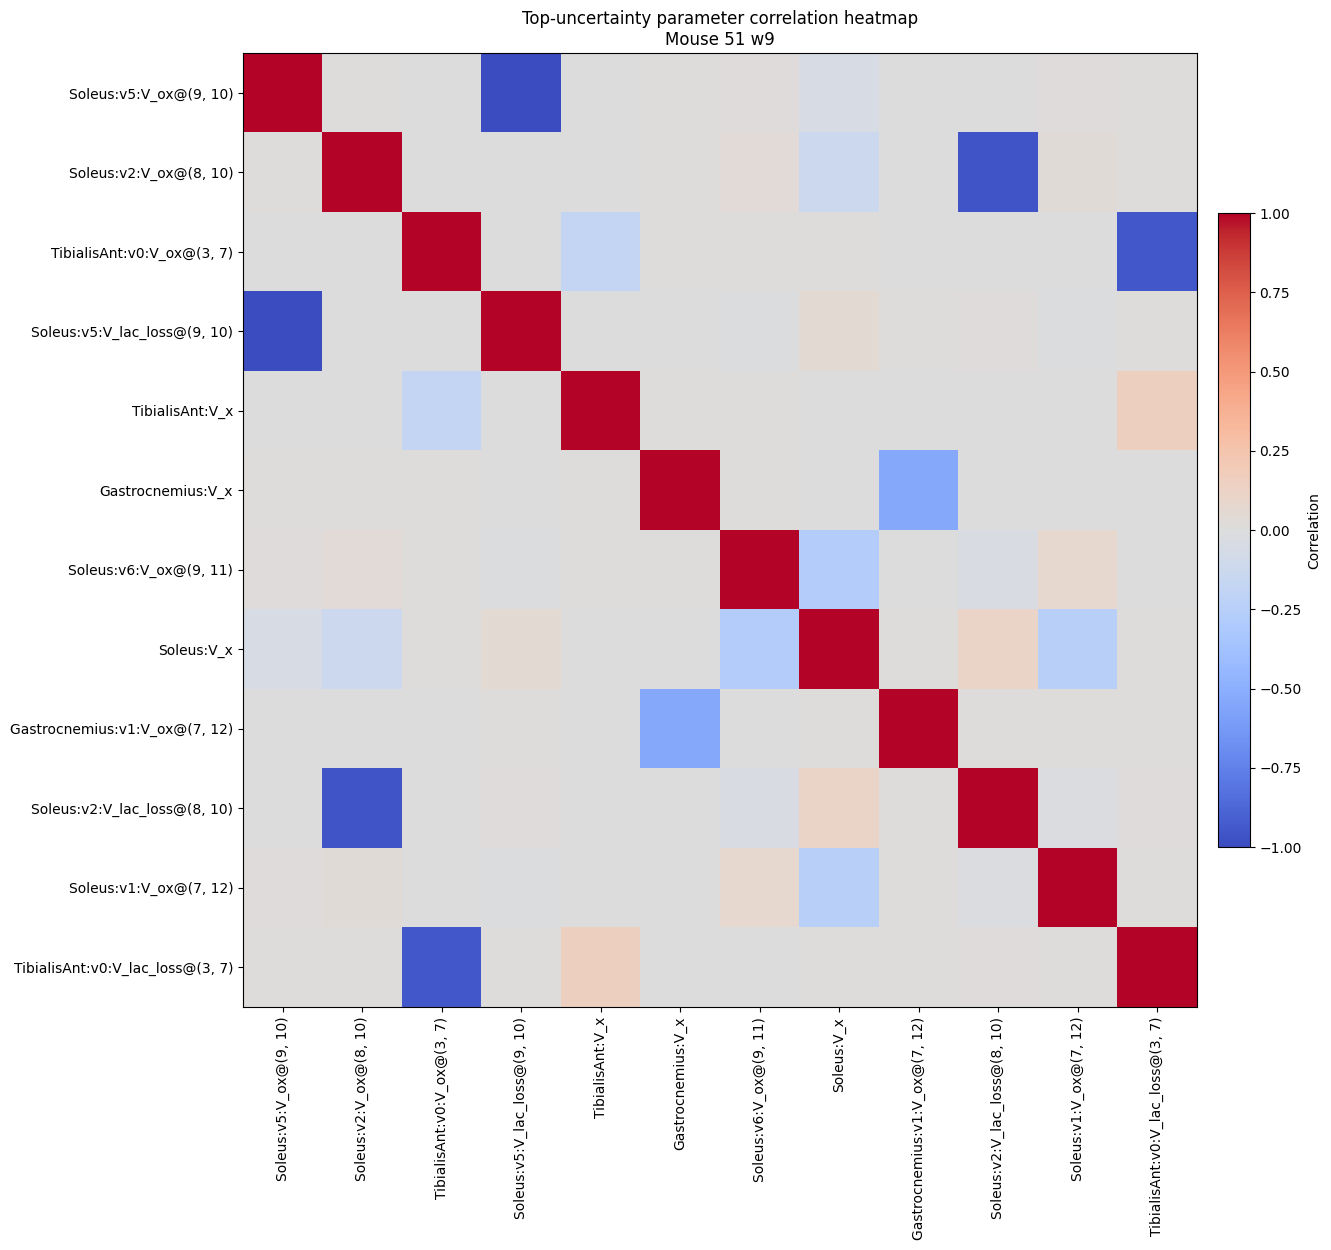

Saved correlation_heatmap_mouse51_w9.png


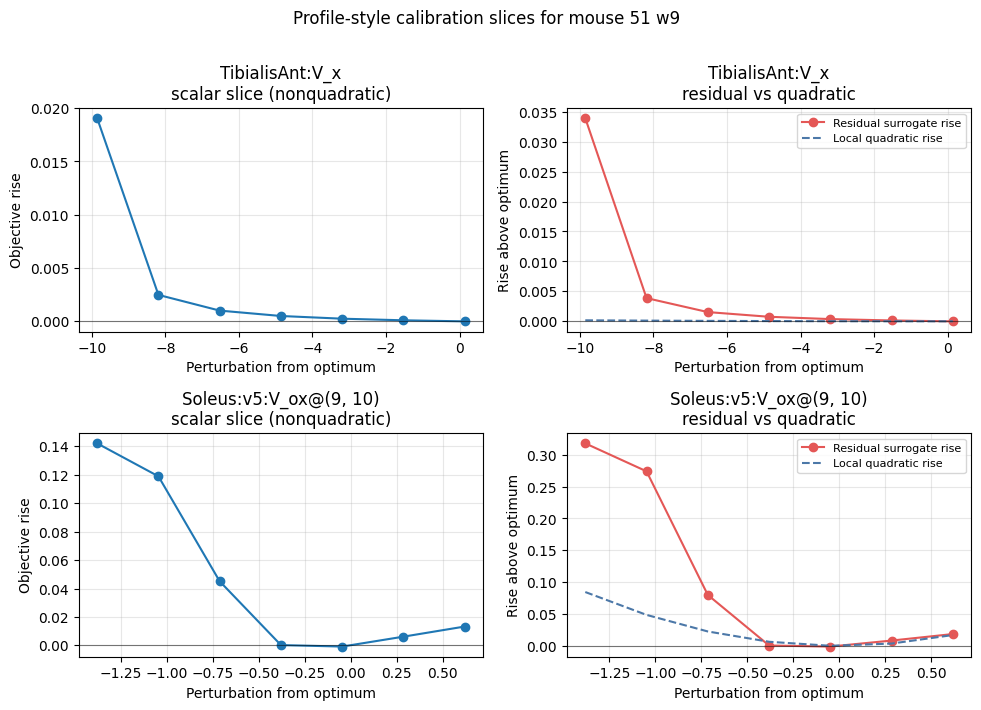

Saved profile_slices_mouse51_w9.png


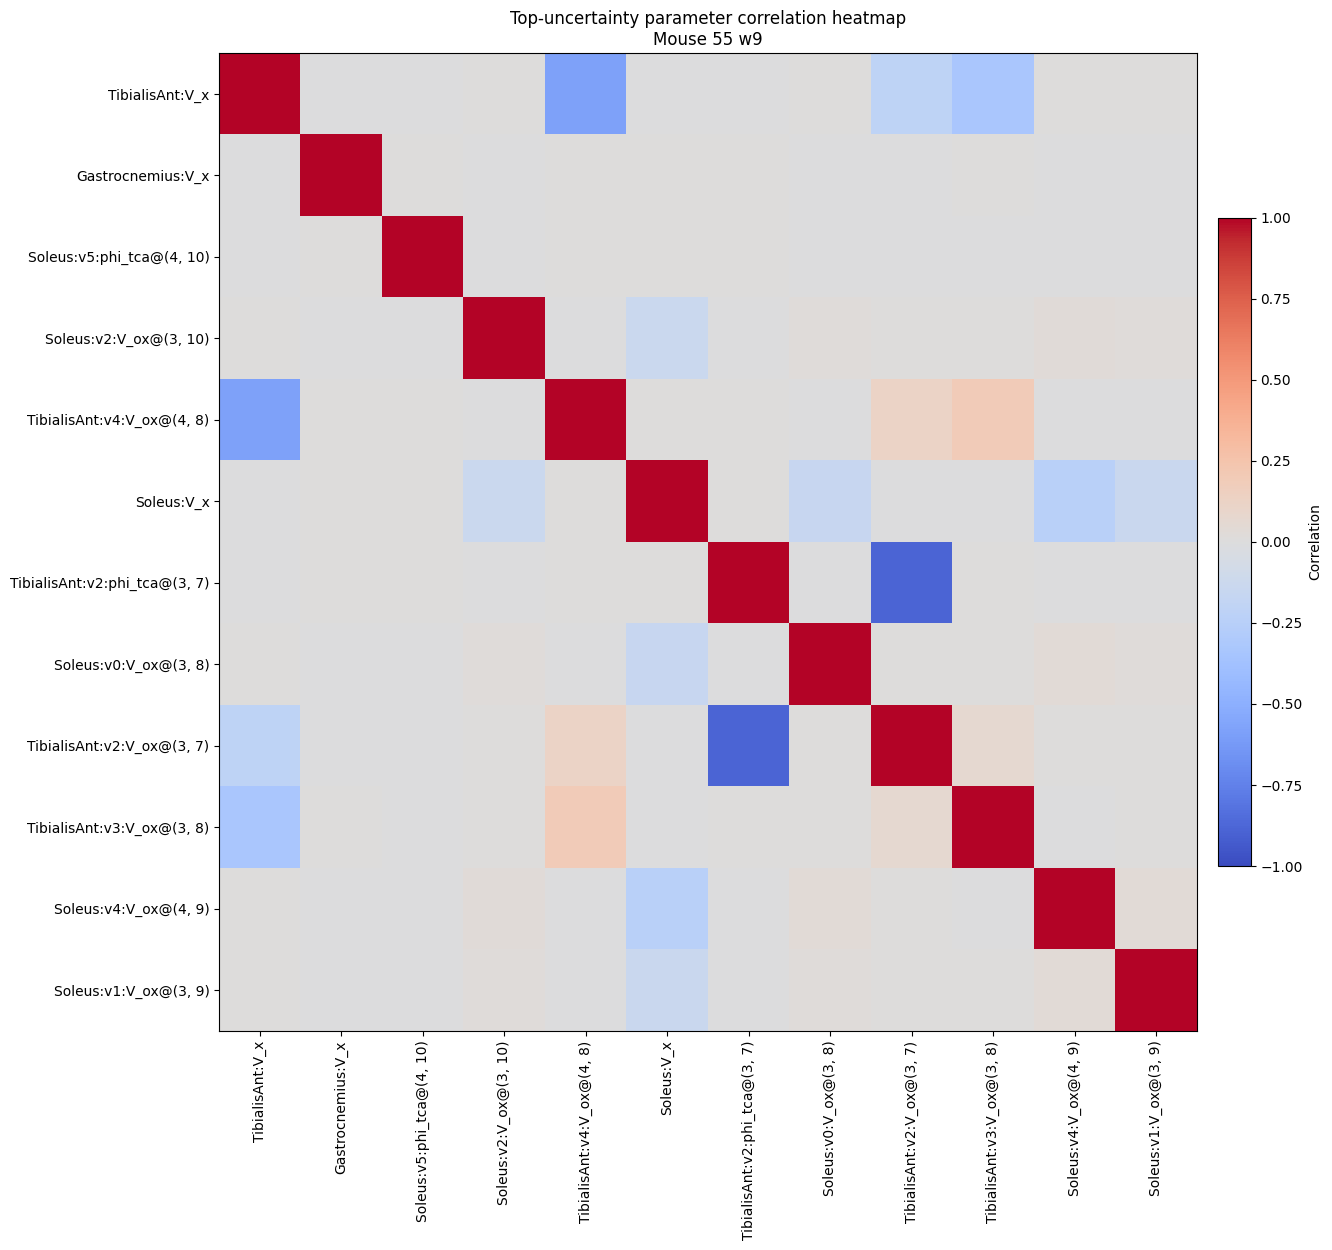

Saved correlation_heatmap_mouse55_w9.png


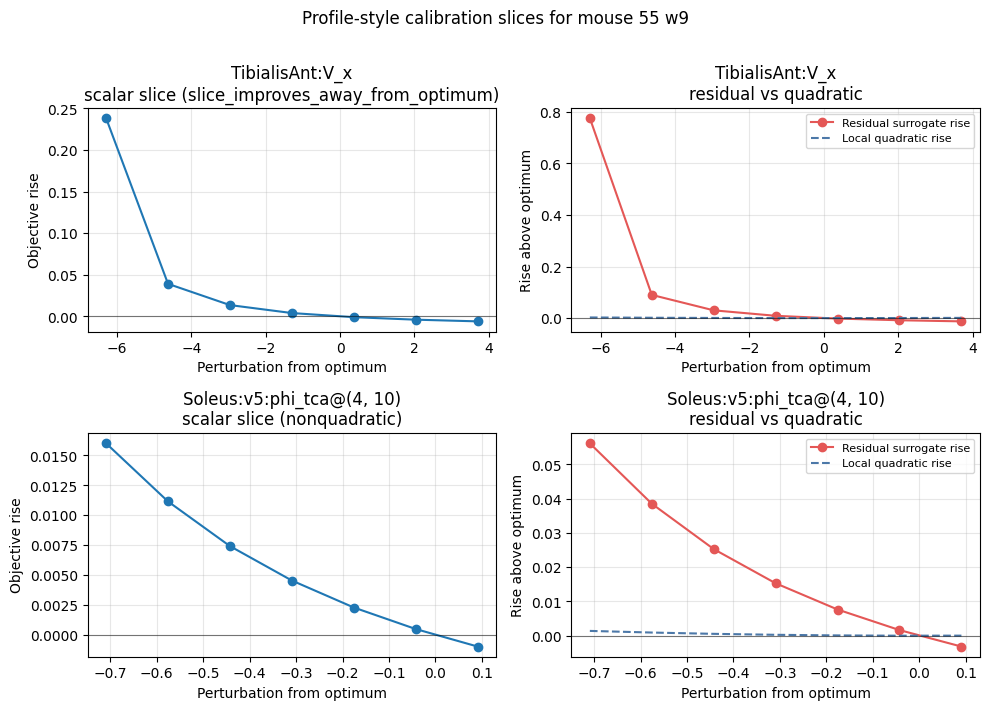

Saved profile_slices_mouse55_w9.png


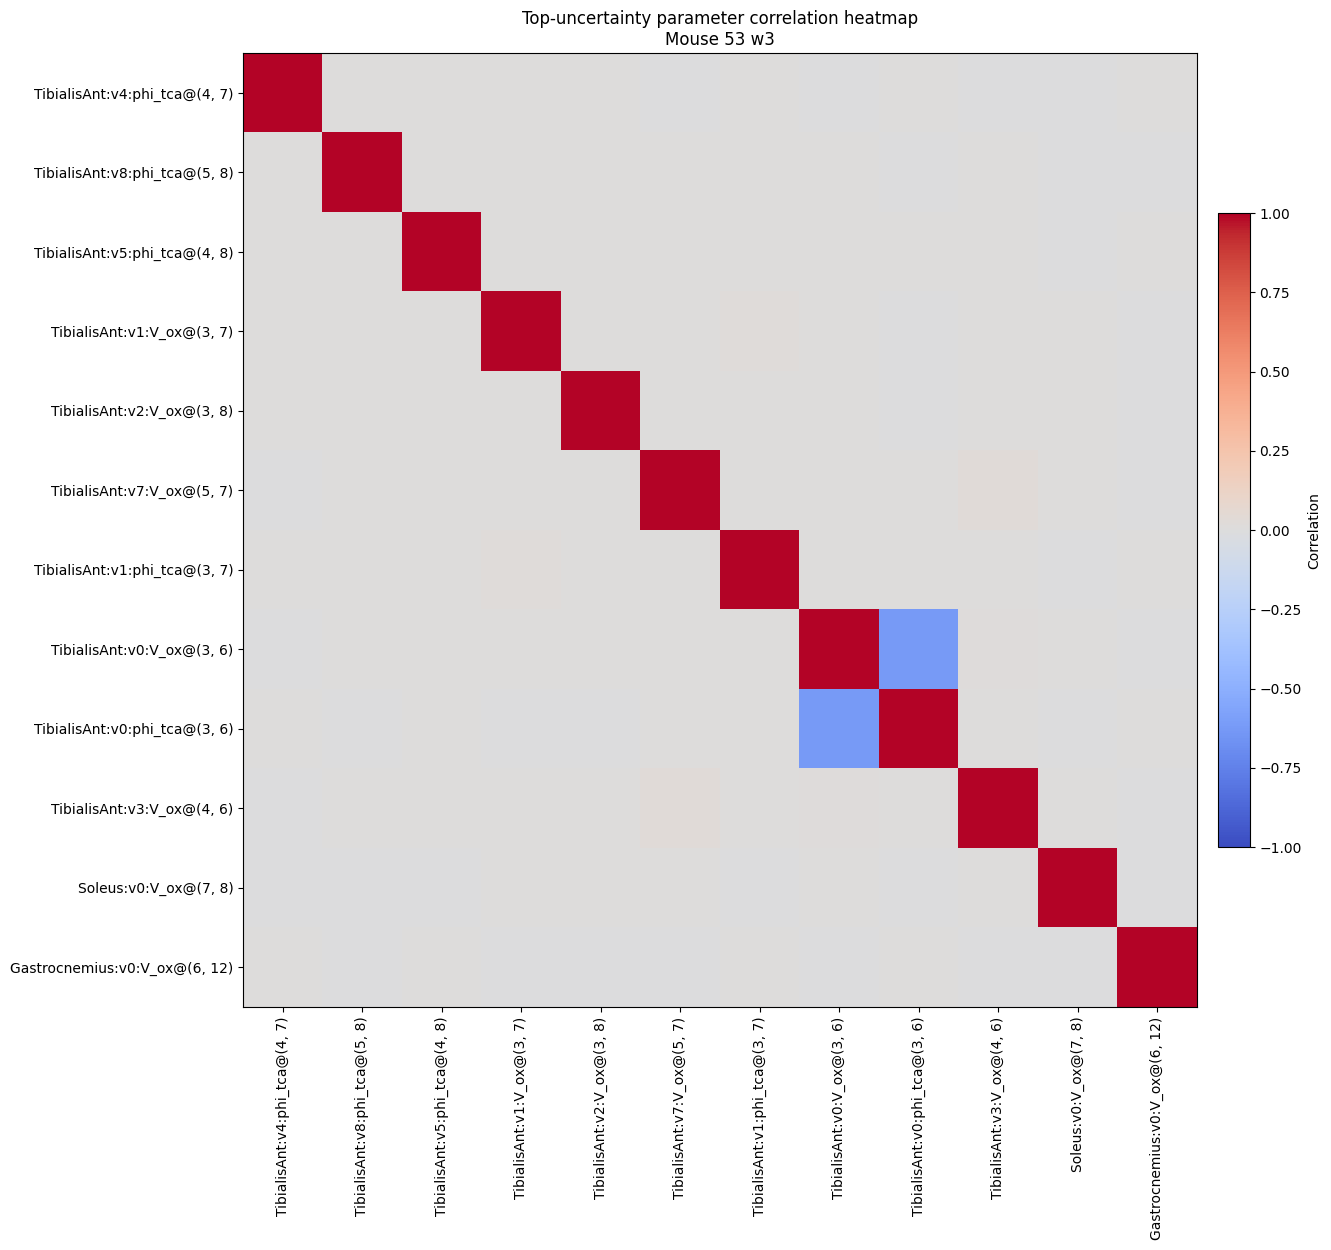

Saved correlation_heatmap_mouse53_w3.png


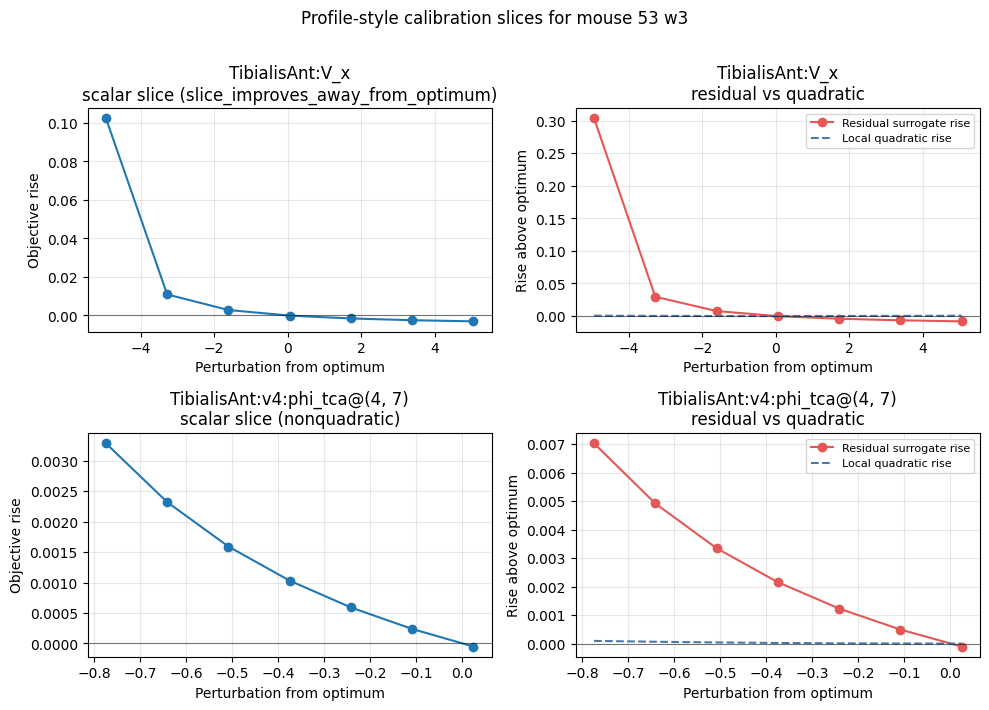

Saved profile_slices_mouse53_w3.png


In [5]:
TIER_ORDER = {'boundary_sensitive': 0, 'weakly_identified': 1, 'degraded': 2}


def rank_fits(results):
    """Rank fits best-to-worst by tier, then trust_score desc, n_bound_hits asc, final_cost asc.

    NaN trust_score (degraded fits) is mapped to -1.0 so they always sort last within their tier.
    """
    rows = []
    for result in results:
        diag = result.get('uncertainty', {}).get('covariance_diagnostics', {})
        ts = diag.get('trust_score', float('nan'))
        rows.append({
            'result': result,
            'tier': TIER_ORDER.get(diag.get('trust_label', 'degraded'), 99),
            'trust_score_sort': ts if np.isfinite(ts) else -1.0,
            'n_bound_hits': len(diag.get('bound_hits', [])),
            'final_cost': result.get('final_cost', float('inf')),
        })
    rows.sort(key=lambda r: (r['tier'], -r['trust_score_sort'], r['n_bound_hits'], r['final_cost']))
    return [r['result'] for r in rows]


summary_results = [r for r in analyzed_results if r.get('include_in_summary', False)]
ranked_results = rank_fits(summary_results)
best_3 = ranked_results[:3]
worst_3 = ranked_results[-3:]

print('Fit quality ranking (best to worst):')
for rank_i, r in enumerate(ranked_results):
    diag = r.get('uncertainty', {}).get('covariance_diagnostics', {})
    ts = diag.get('trust_score', float('nan'))
    nb = len(diag.get('bound_hits', []))
    print(f"  {rank_i+1:2d}. mouse {r['mouseID']:3d} {r['week']:5s} ({r['group']:4s})  "
          f"tier={diag.get('trust_label','?'):20s}  trust_score={ts:.2f}  n_bound_hits={nb}  "
          f"final_cost={r.get('final_cost', float('nan')):.3f}")

print('\nBest 3: ', [(r['mouseID'], r['week']) for r in best_3])
print('Worst 3:', [(r['mouseID'], r['week']) for r in worst_3])


def plot_correlation_heatmap(result, save_dir=PLOTS_DIR, show=False):
    heatmap_df = correlation_heatmap_frame(result)
    if heatmap_df.empty:
        print('No heatmap payload was available for this result.')
        return

    fig, ax = plt.subplots(figsize=(0.8 * len(heatmap_df.columns) + 4, 0.8 * len(heatmap_df.index) + 3))
    im = ax.imshow(heatmap_df.values, cmap='coolwarm', vmin=-1.0, vmax=1.0)
    ax.set_xticks(np.arange(len(heatmap_df.columns)))
    ax.set_yticks(np.arange(len(heatmap_df.index)))
    ax.set_xticklabels(heatmap_df.columns, rotation=90)
    ax.set_yticklabels(heatmap_df.index)
    ax.set_title(
        f"Top-uncertainty parameter correlation heatmap\nMouse {result['mouseID']} {result['week']}"
    )
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Correlation')
    plt.tight_layout()
    out_path = save_dir / f"correlation_heatmap_mouse{result['mouseID']}_{result['week']}.png"
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)
    print(f'Saved {out_path.name}')


def plot_profile_slices(result, save_dir=PLOTS_DIR, show=False):
    checks = result.get('uncertainty', {}).get('profile_checks', [])
    if not checks:
        print('No profile checks were available for this result.')
        return

    fig, axes = plt.subplots(len(checks), 2, figsize=(10, 3.6 * len(checks)), squeeze=False)
    for row_idx, check in enumerate(checks):
        grid_df = pd.DataFrame(check['grid'])

        ax_left = axes[row_idx, 0]
        ax_left.plot(grid_df['delta'], grid_df['scalar_rise'], marker='o', color='#1f77b4', label='v6 scalar objective rise')
        ax_left.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
        ax_left.set_title(f"{check['parameter_label']}\nscalar slice ({check['profile_label']})")
        ax_left.set_xlabel('Perturbation from optimum')
        ax_left.set_ylabel('Objective rise')
        ax_left.grid(True, alpha=0.3)

        ax_right = axes[row_idx, 1]
        ax_right.plot(grid_df['delta'], grid_df['residual_rise'], marker='o', color='#E45756', label='Residual surrogate rise')
        ax_right.plot(grid_df['delta'], grid_df['quadratic_rise'], linestyle='--', color='#4C78A8', label='Local quadratic rise')
        ax_right.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
        ax_right.set_title(f"{check['parameter_label']}\nresidual vs quadratic")
        ax_right.set_xlabel('Perturbation from optimum')
        ax_right.set_ylabel('Rise above optimum')
        ax_right.grid(True, alpha=0.3)
        ax_right.legend(fontsize=8)

    fig.suptitle(
        f"Profile-style calibration slices for mouse {result['mouseID']} {result['week']}",
        fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out_path = save_dir / f"profile_slices_mouse{result['mouseID']}_{result['week']}.png"
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)
    print(f'Saved {out_path.name}')


for tier_label, tier_fits in [('best', best_3), ('worst', worst_3)]:
    print(f'\n--- {tier_label.upper()} 3 fits ---')
    for result in tier_fits:
        if not result.get('uncertainty', {}).get('top_correlations'):
            print(f"  Mouse {result['mouseID']} {result['week']}: no top_correlations payload, skipping heatmap.")
        else:
            plot_correlation_heatmap(result, show=True)
        plot_profile_slices(result, show=True)


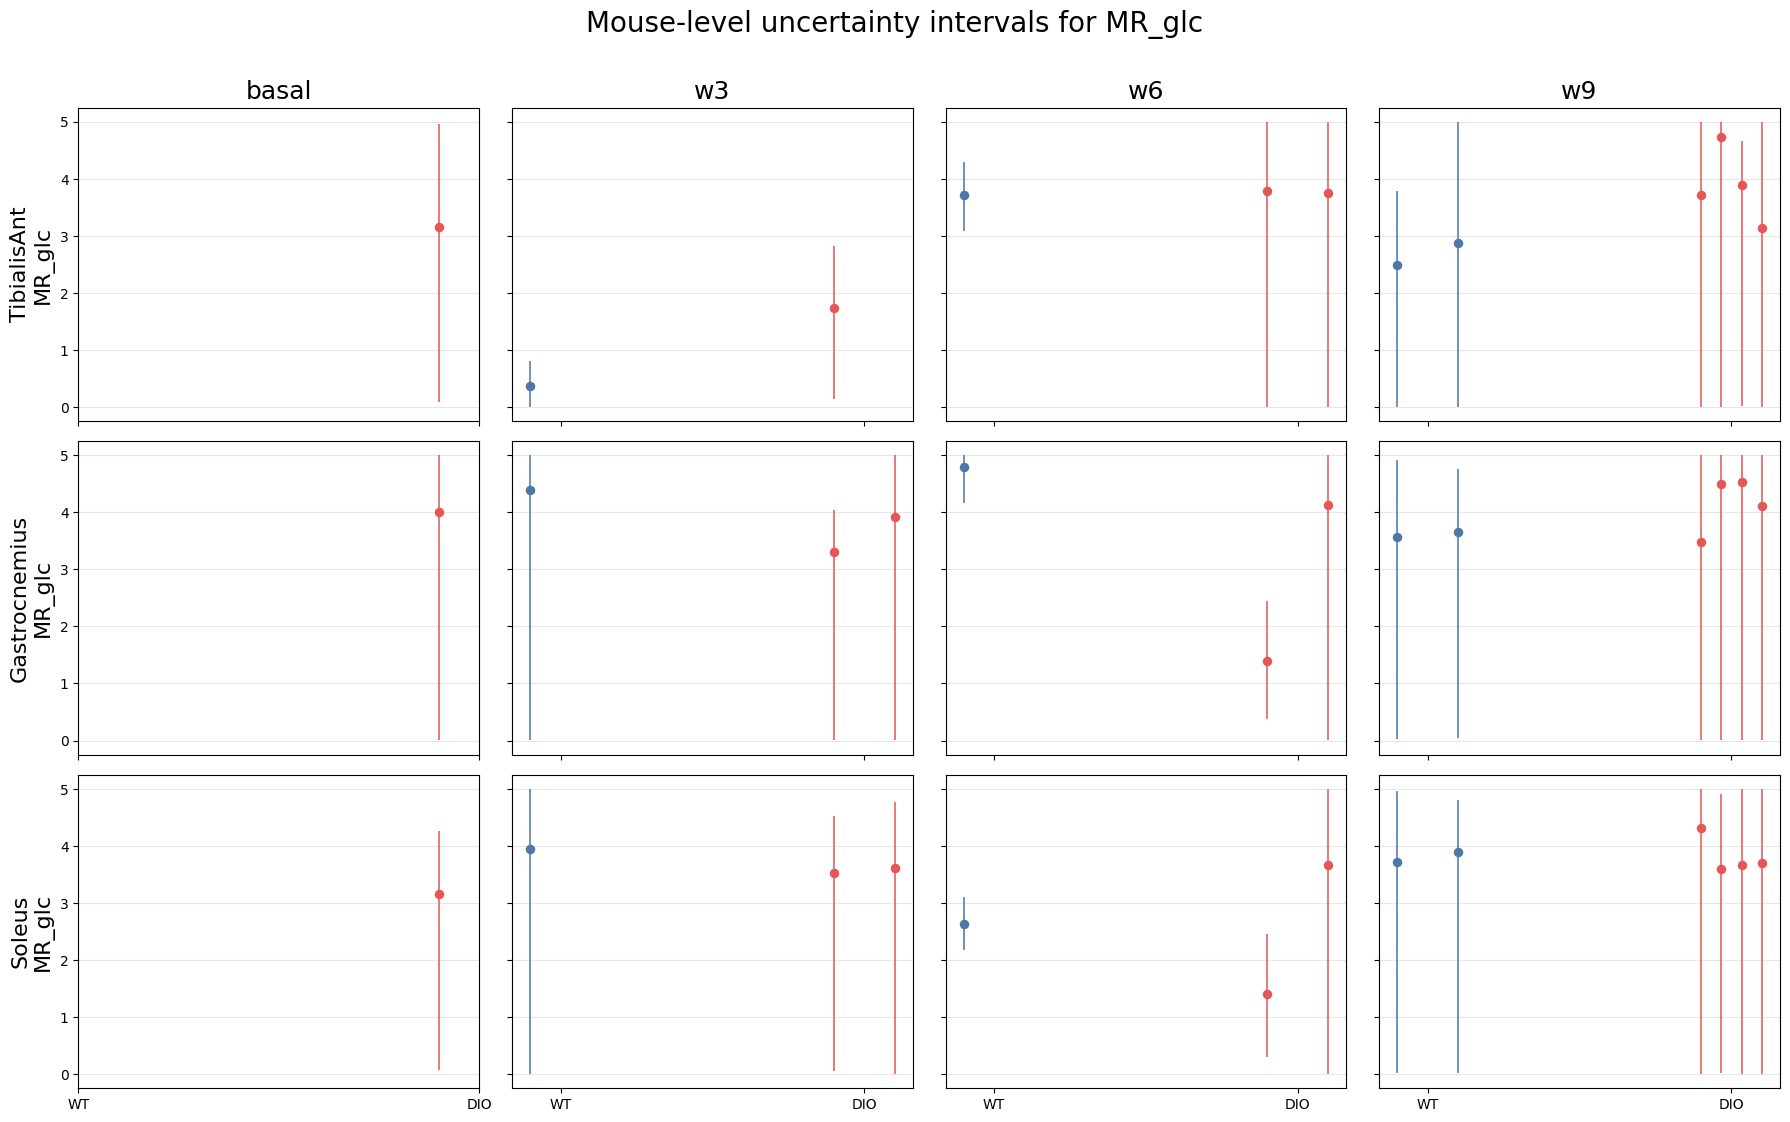

Saved mouse_level_uncertainty_MR_glc.png


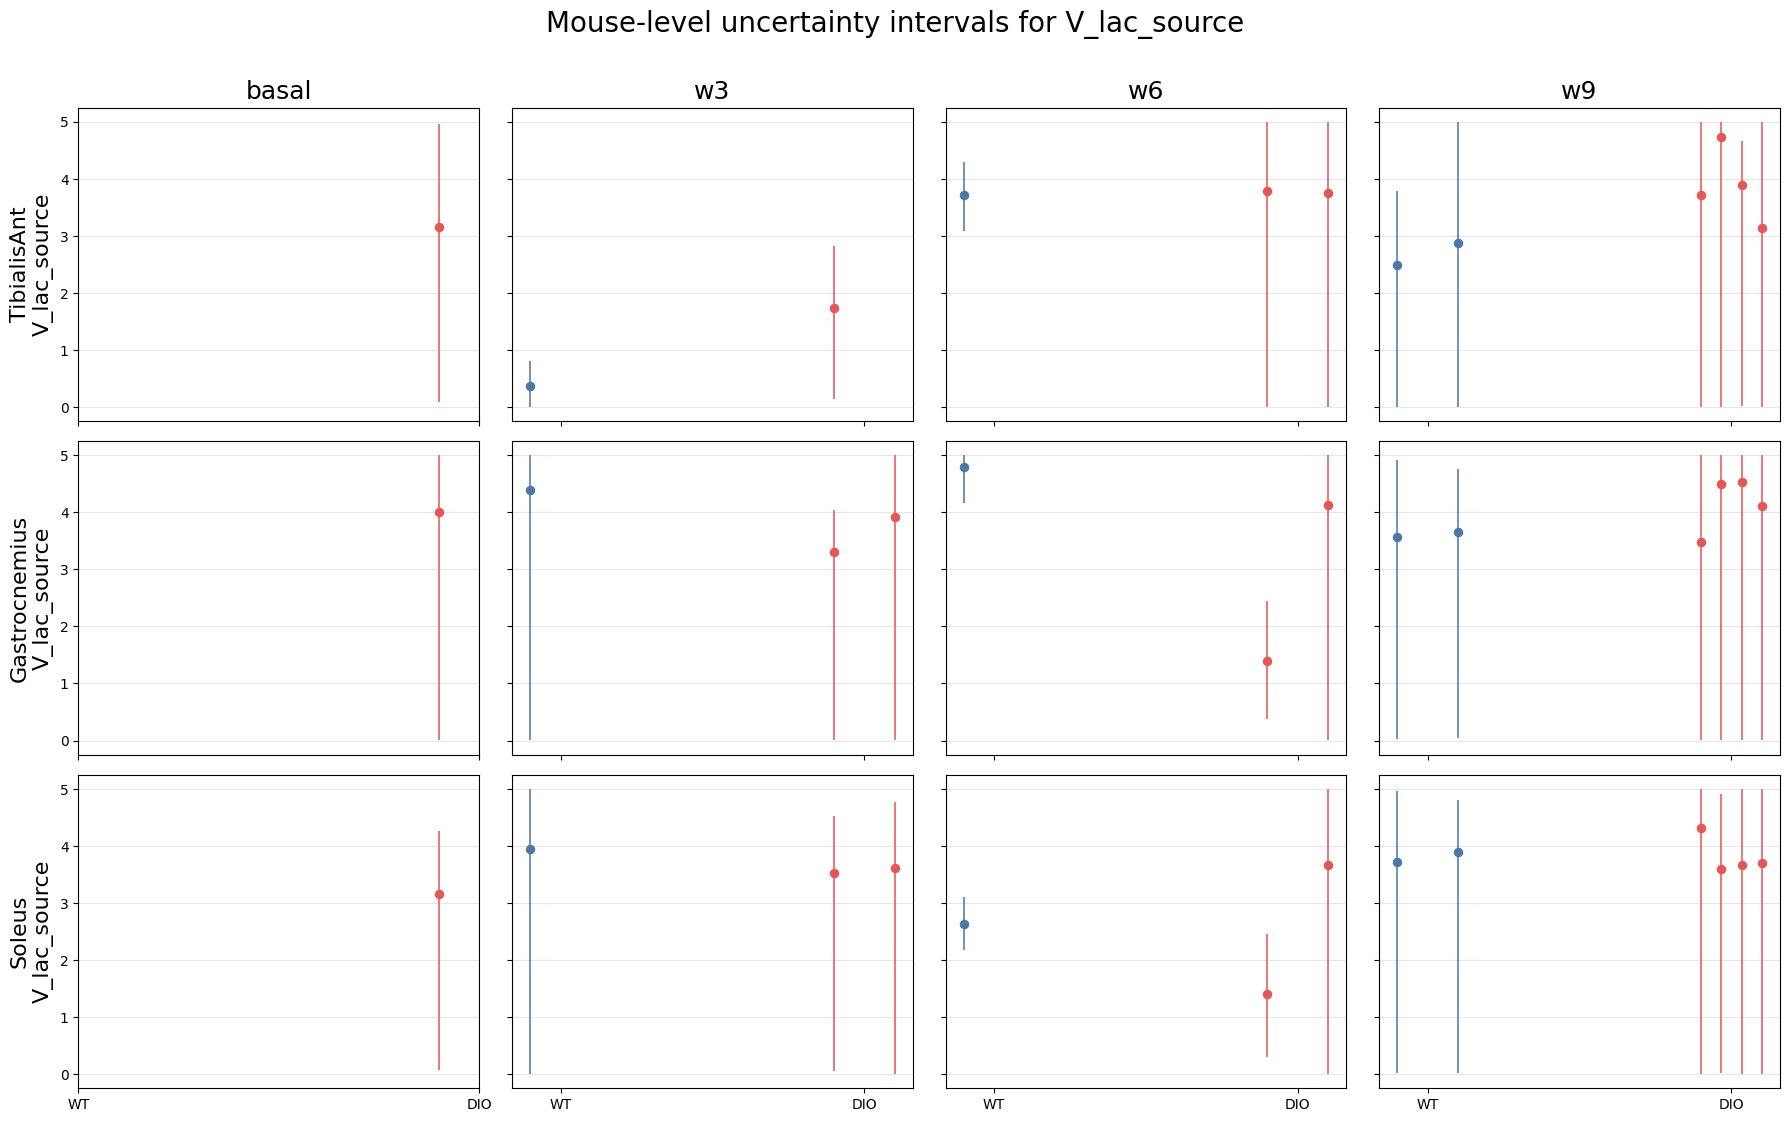

Saved mouse_level_uncertainty_V_lac_source.png


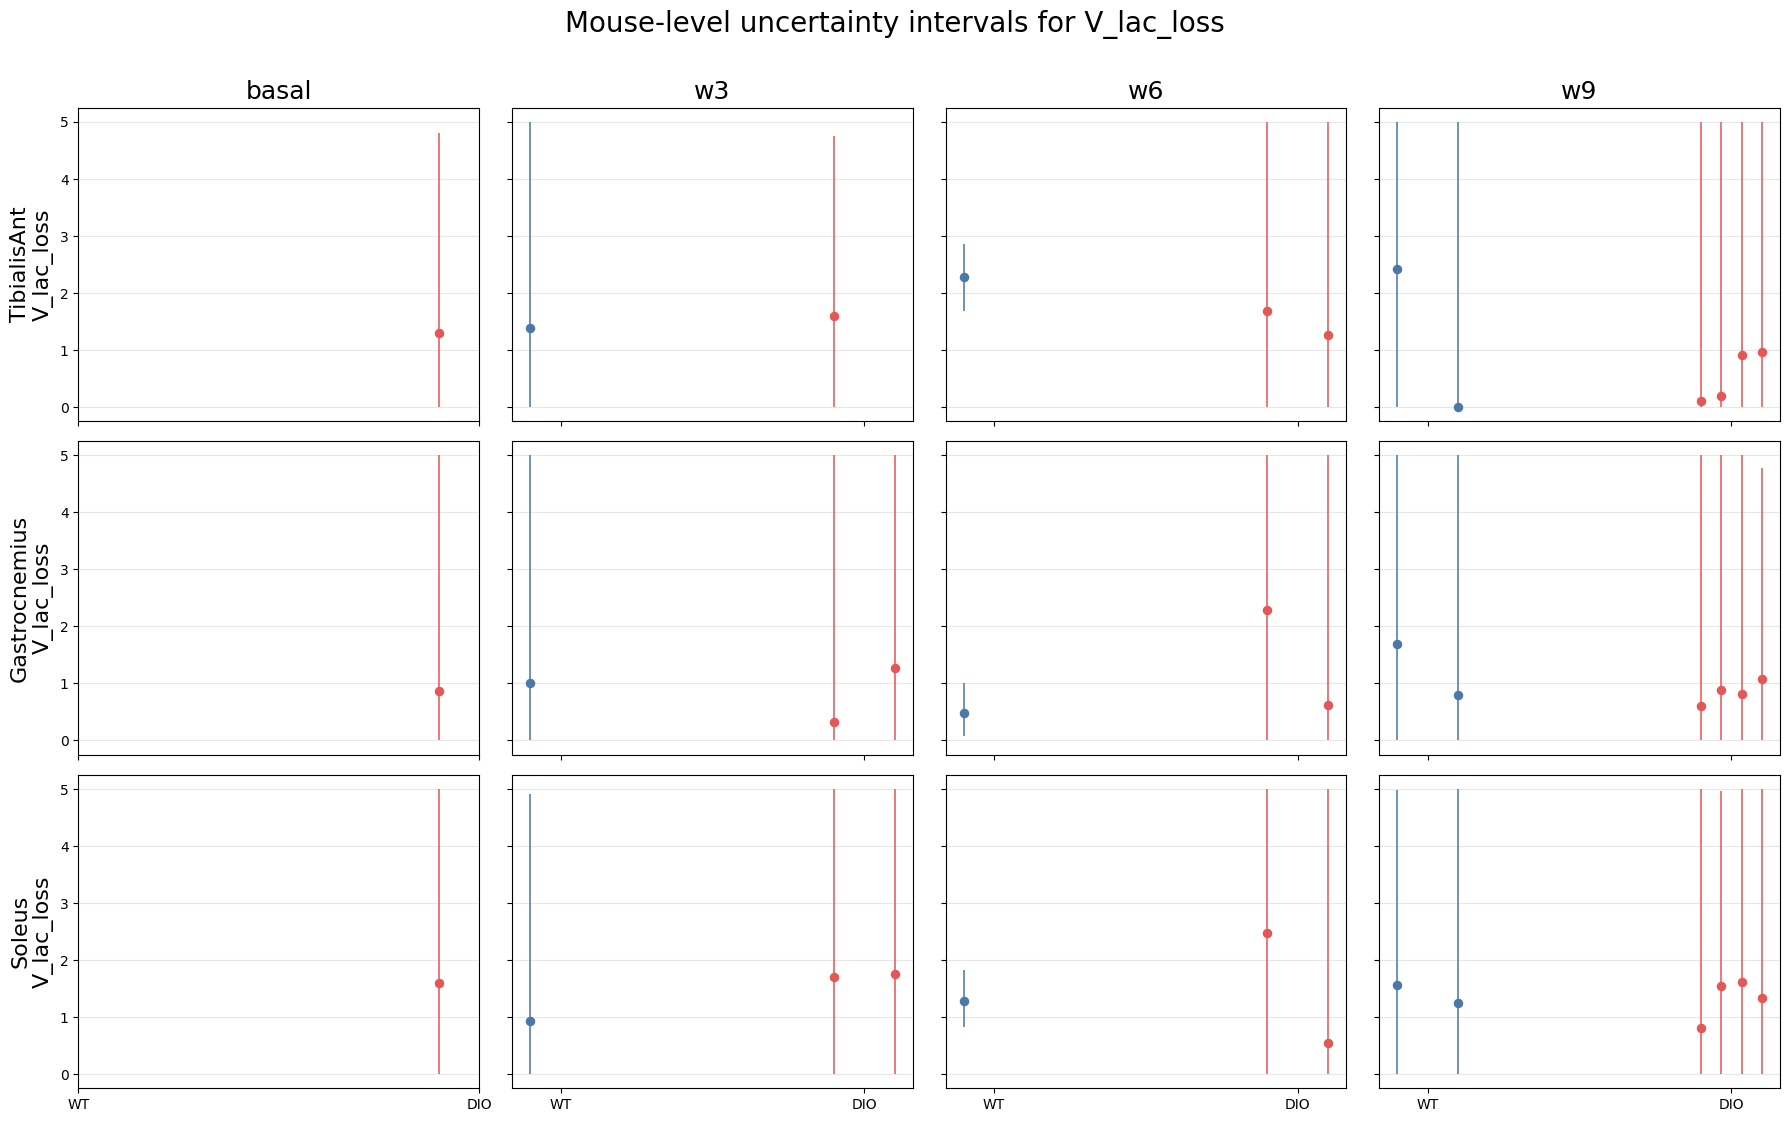

Saved mouse_level_uncertainty_V_lac_loss.png


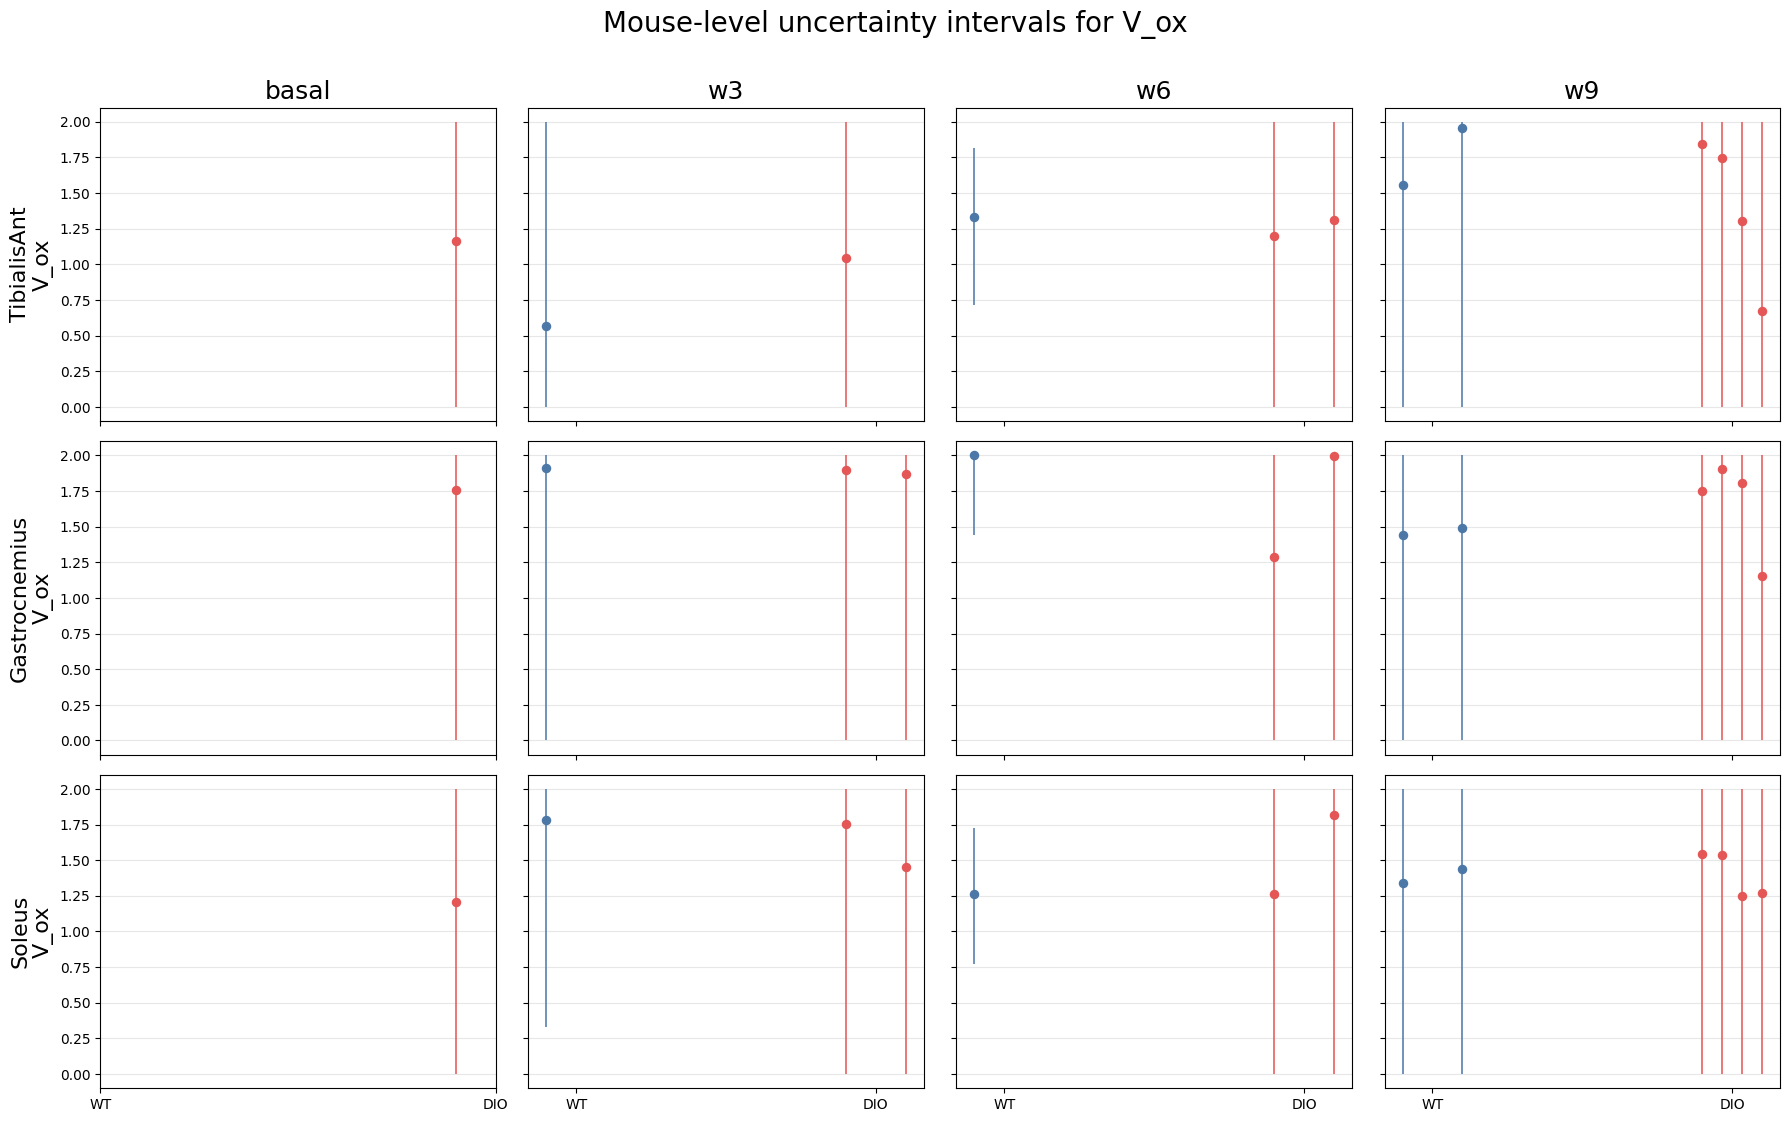

Saved mouse_level_uncertainty_V_ox.png


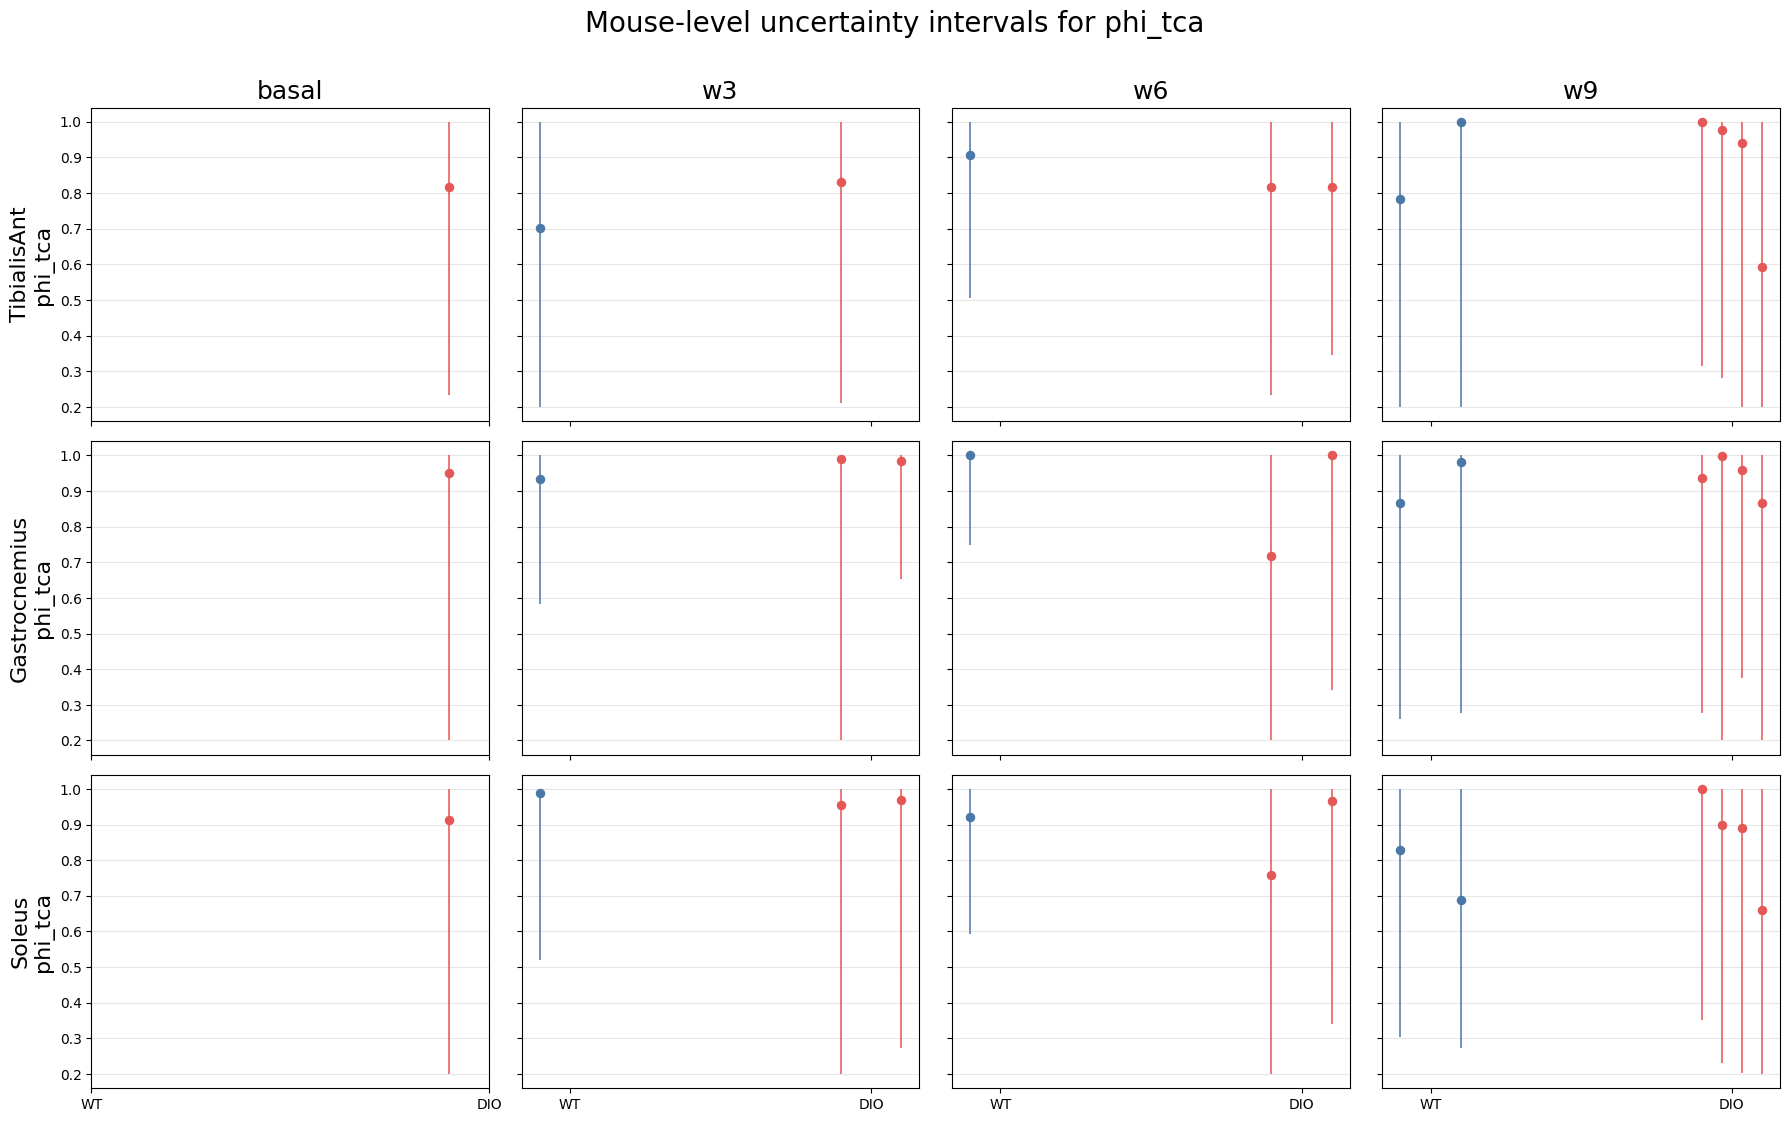

Saved mouse_level_uncertainty_phi_tca.png


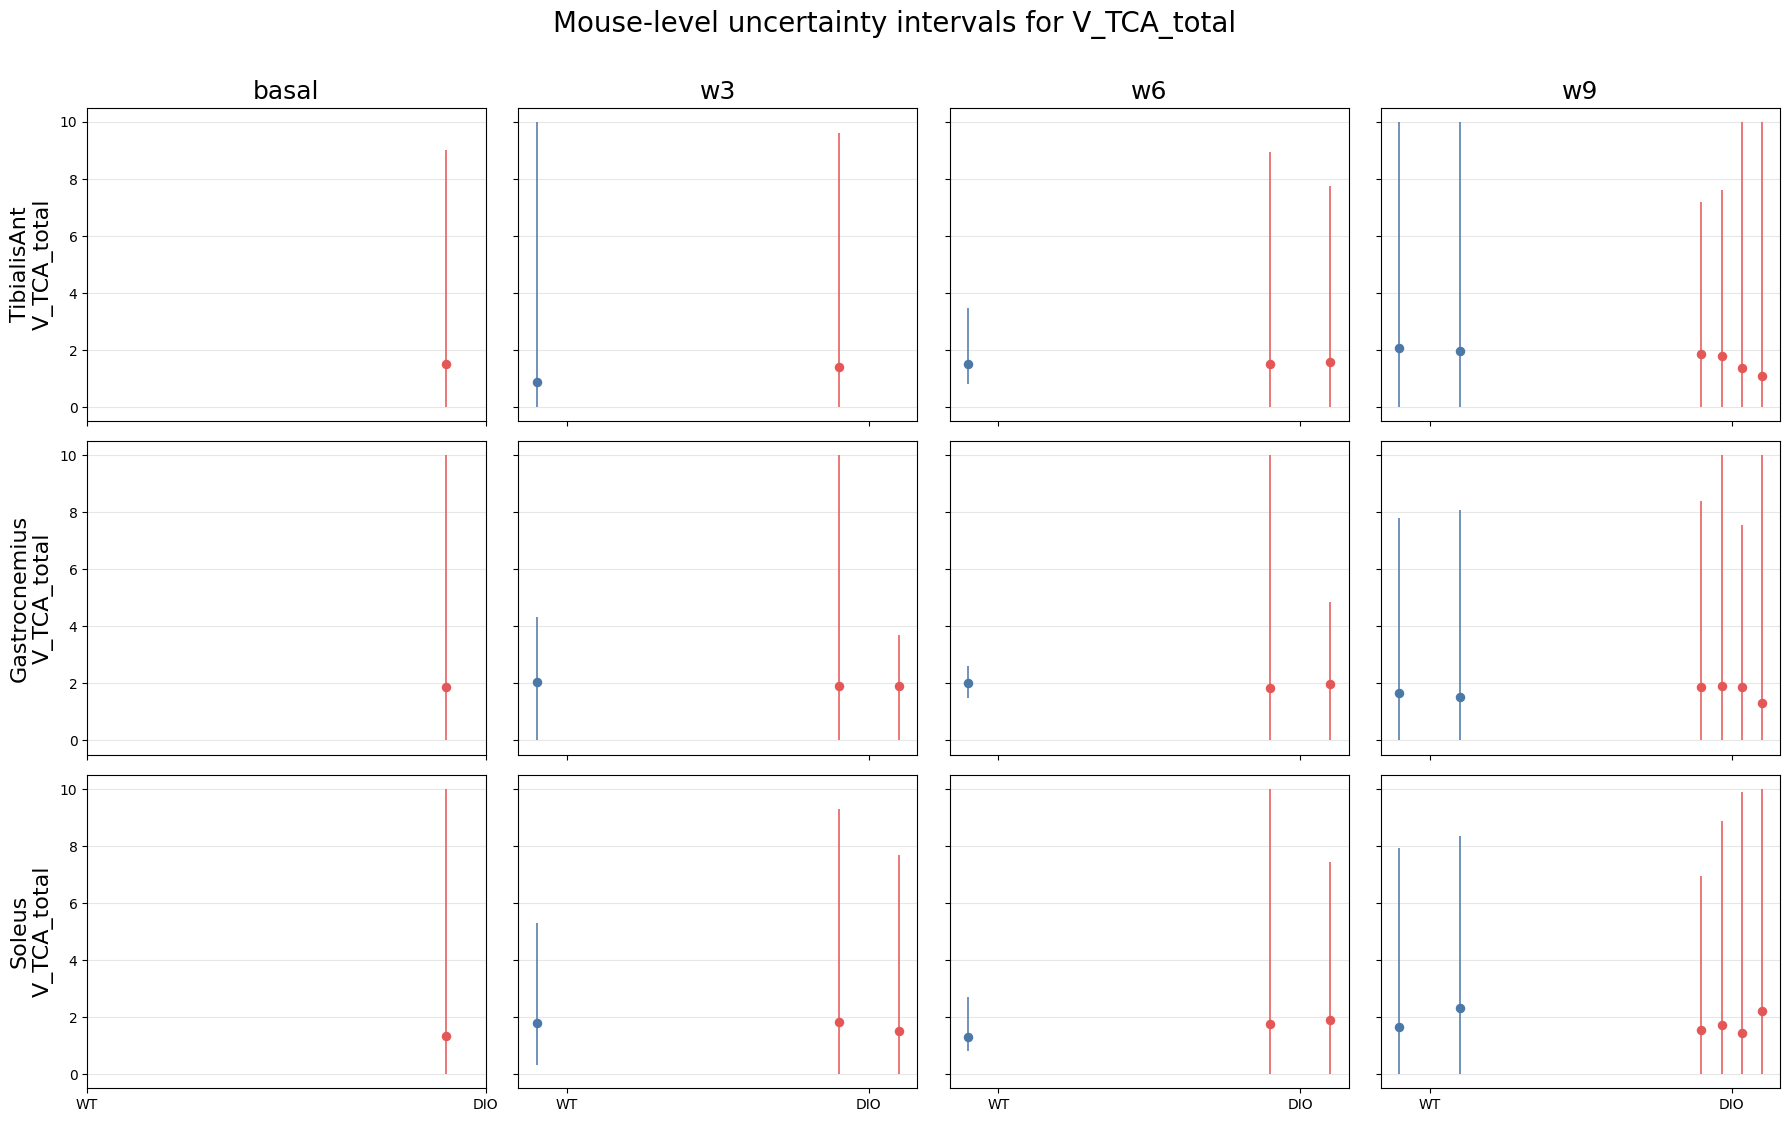

Saved mouse_level_uncertainty_V_TCA_total.png


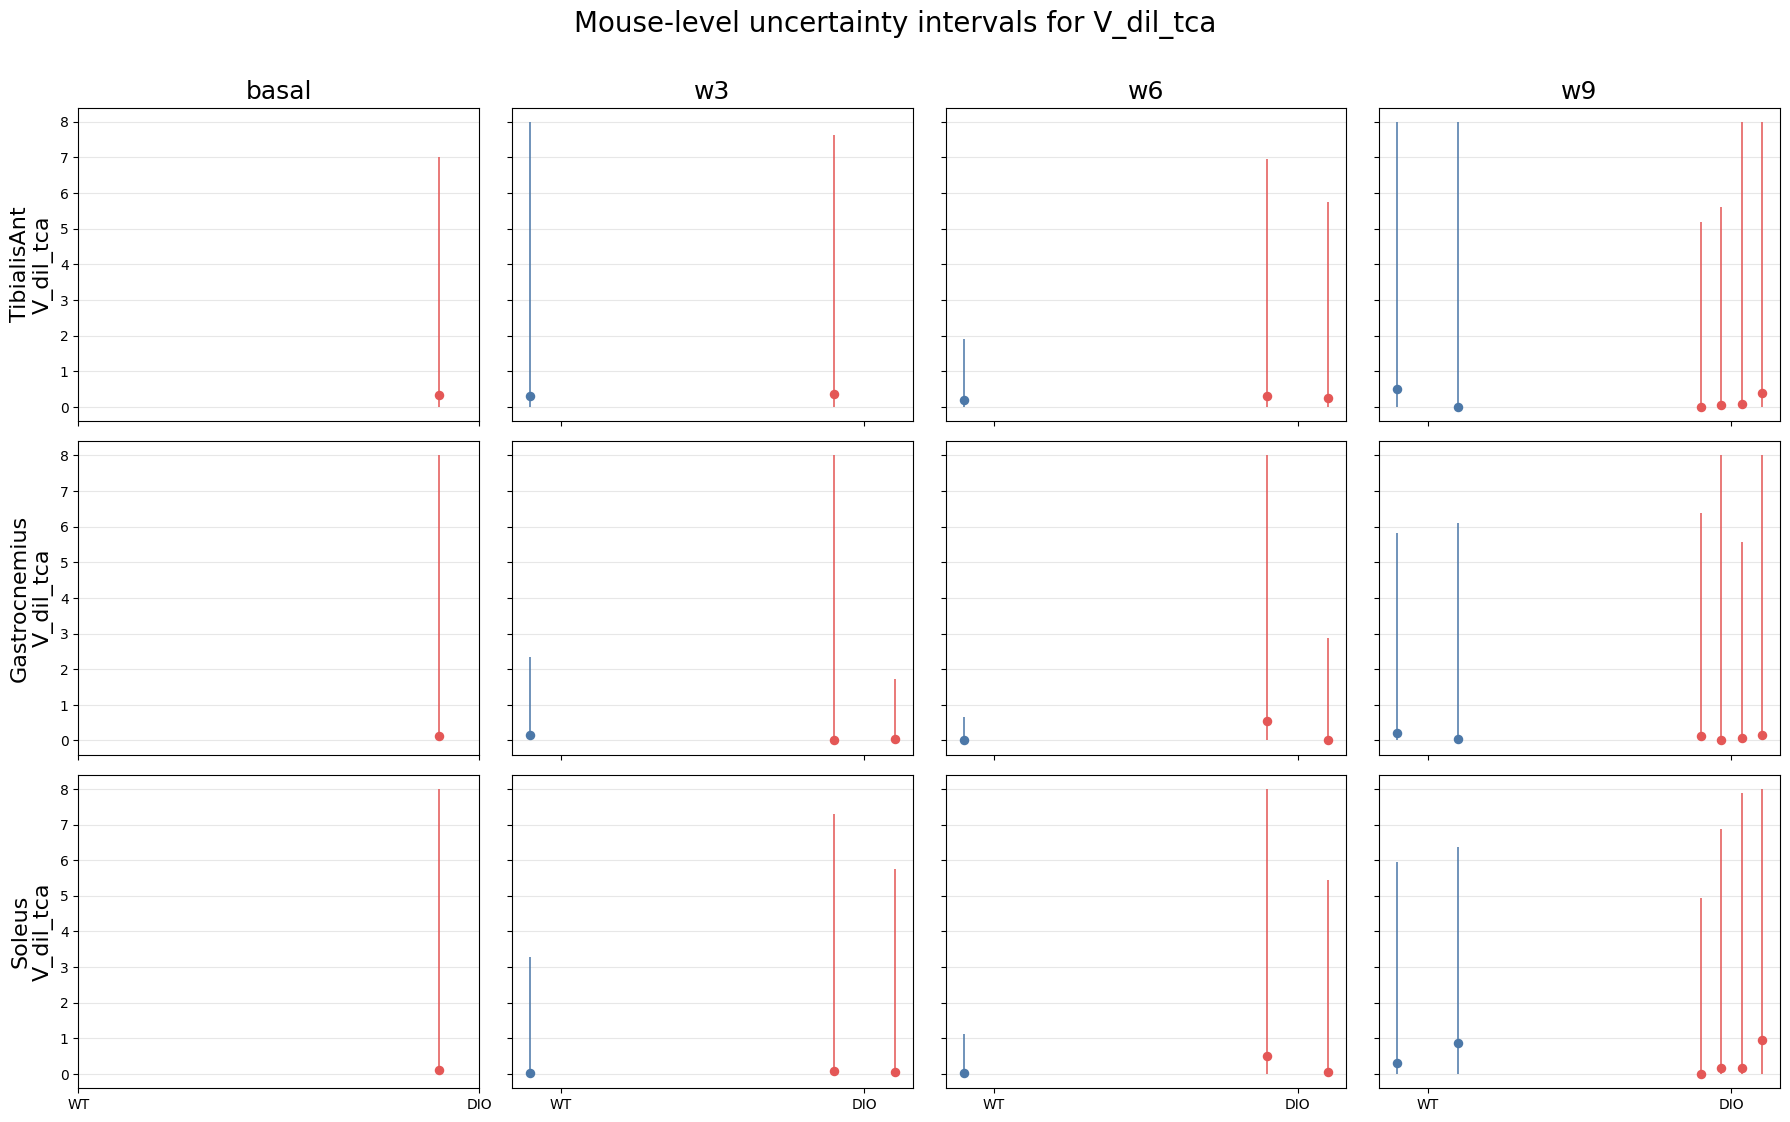

Saved mouse_level_uncertainty_V_dil_tca.png


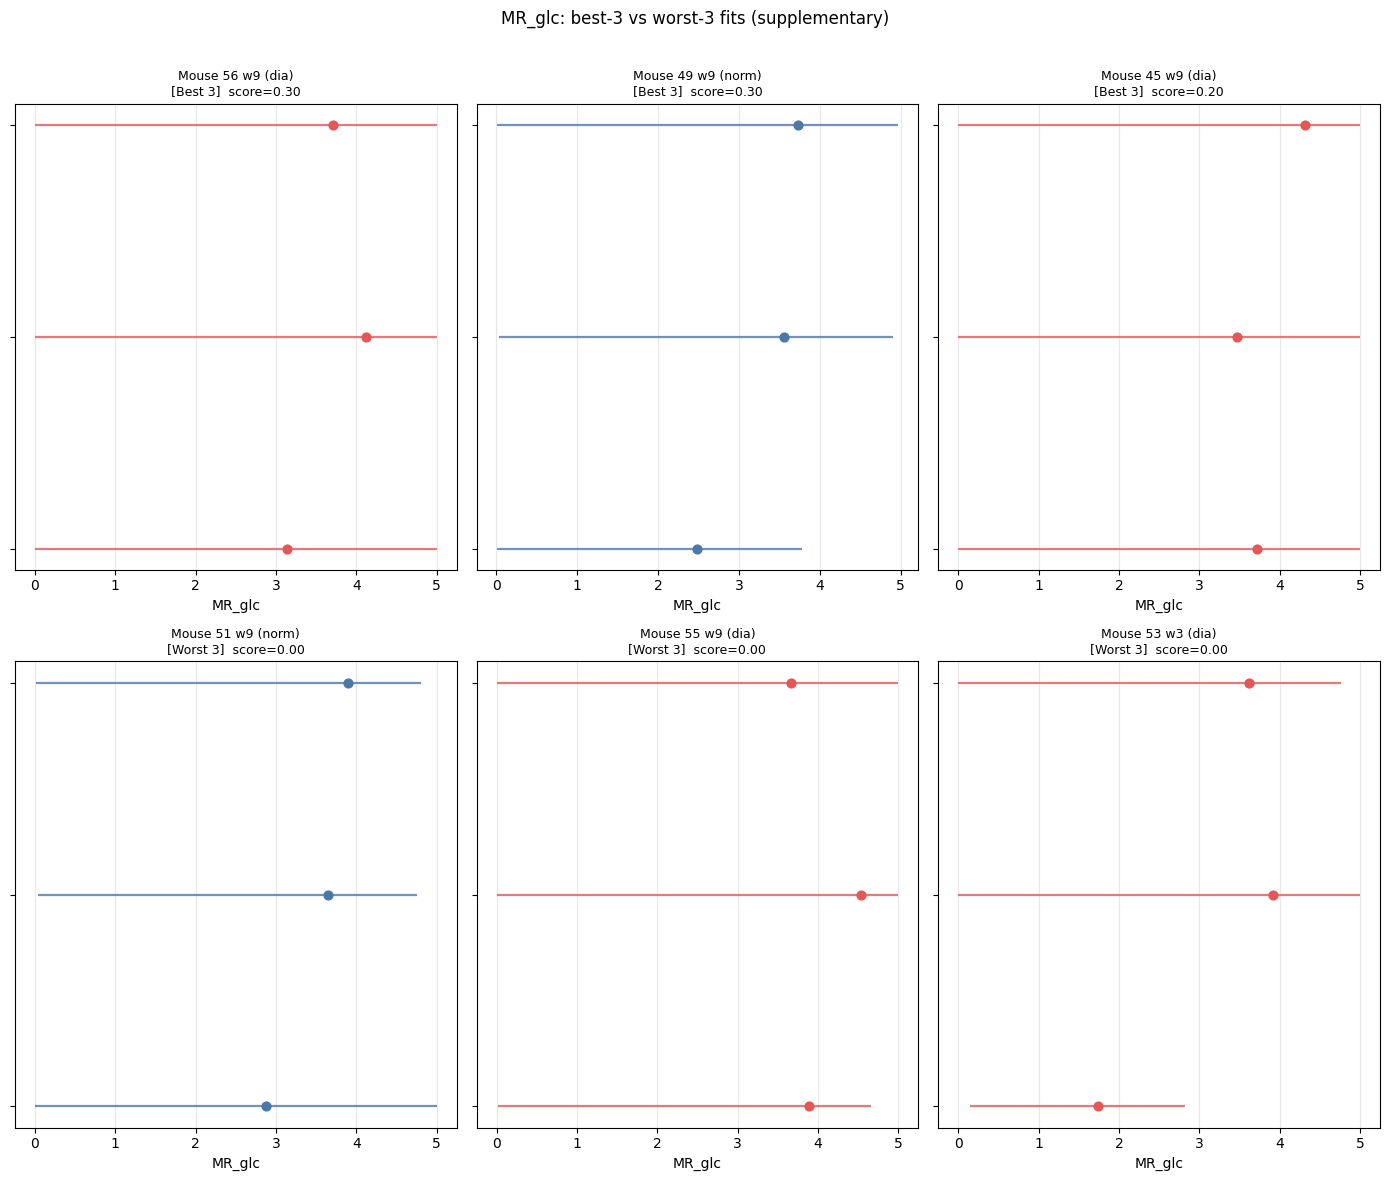

Saved ranked_comparison_MR_glc.png


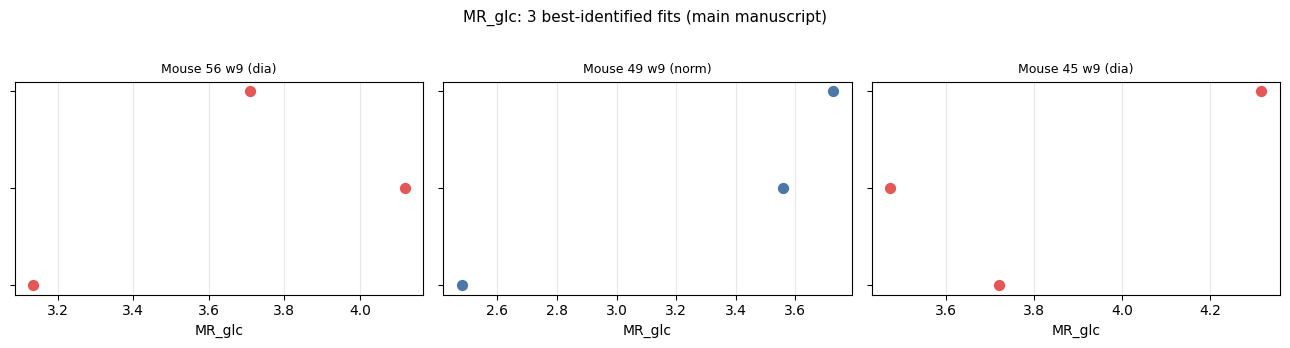

Saved best3_main_MR_glc.png


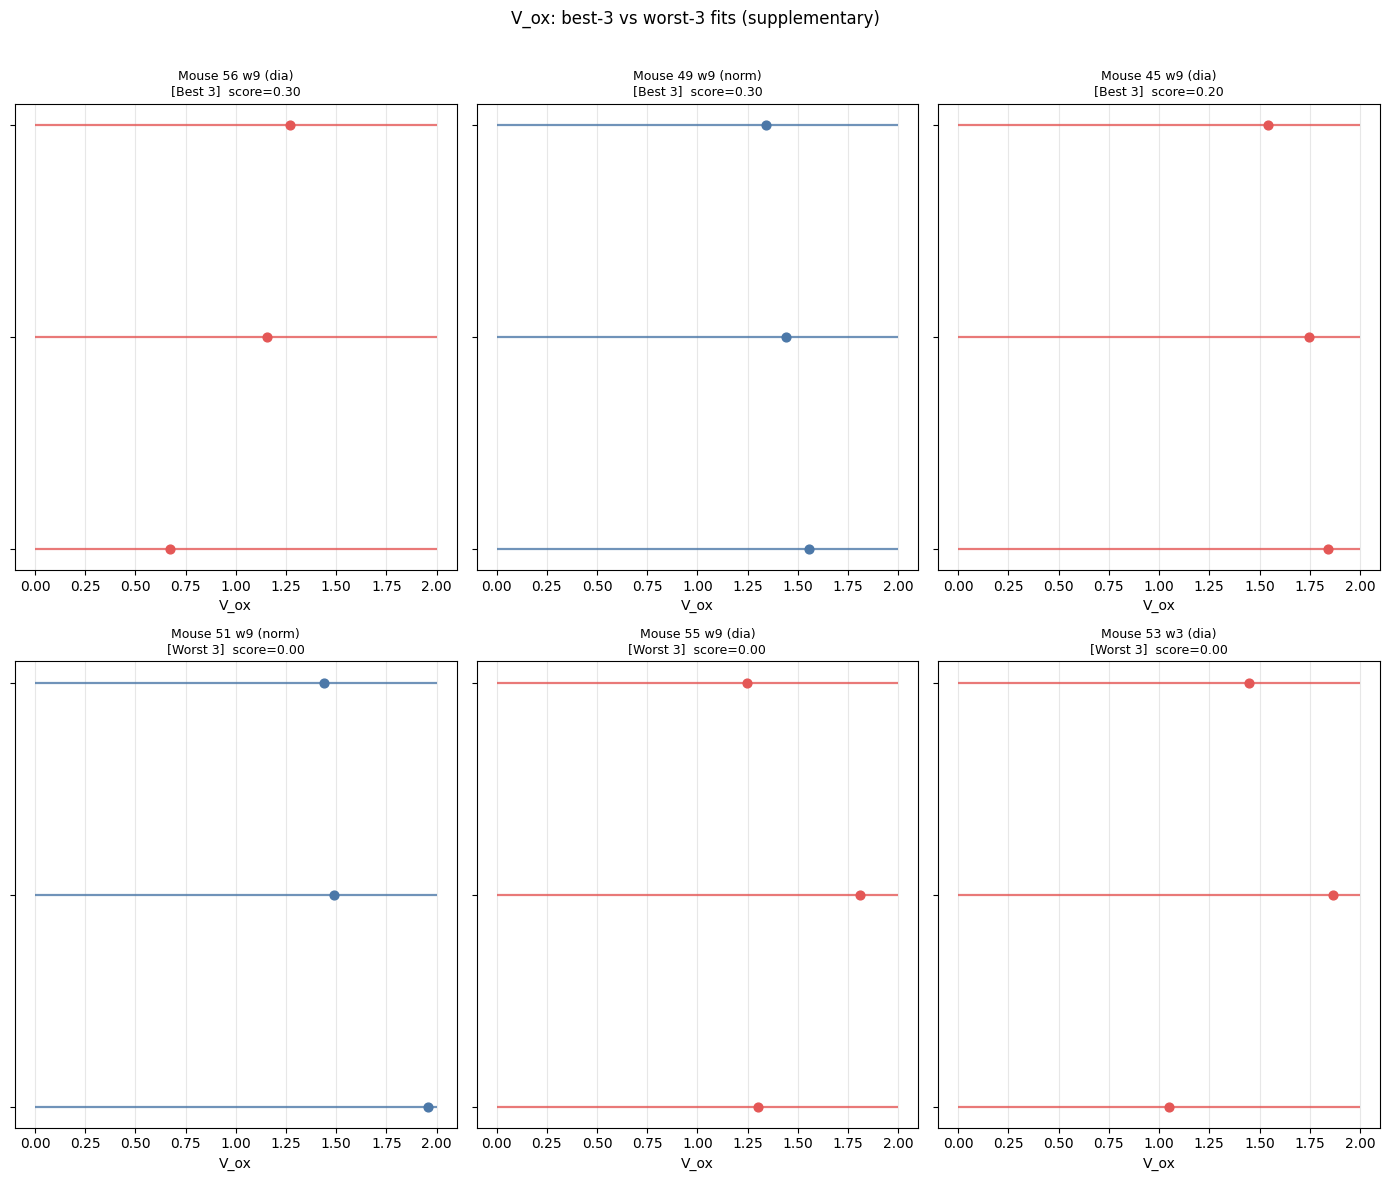

Saved ranked_comparison_V_ox.png


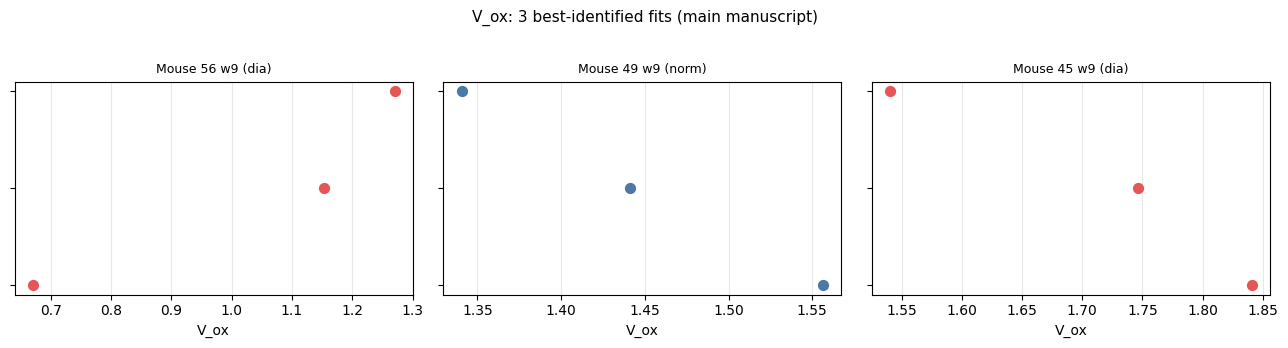

Saved best3_main_V_ox.png


In [6]:
def plot_mouse_level_intervals(df, parameter, save_dir=PLOTS_DIR, show=False):
    if df.empty:
        return

    weeks_present = sorted(df['week'].unique(), key=lambda wk: m7.mf.WEEKS.index(wk) if wk in m7.mf.WEEKS else 99)
    tissues_present = [tissue for tissue in m7.mf.TISSUES if tissue in set(df['tissue'])]
    fig, axes = plt.subplots(
        len(tissues_present),
        len(weeks_present),
        figsize=(4.5 * len(weeks_present), 3.8 * len(tissues_present)),
        sharex='col',
        sharey='row',
    )
    axes = np.array(axes, dtype=object)
    if len(tissues_present) == 1:
        axes = axes[np.newaxis, :]
    if len(weeks_present) == 1:
        axes = axes[:, np.newaxis]

    group_colors = {'norm': '#4C78A8', 'dia': '#E45756'}
    for tissue_idx, tissue in enumerate(tissues_present):
        for week_idx, week in enumerate(weeks_present):
            ax = axes[tissue_idx, week_idx]
            sub = df[(df['tissue'] == tissue) & (df['week'] == week)]
            for group_idx, group in enumerate(['norm', 'dia']):
                gsub = sub[sub['group'] == group].reset_index(drop=True)
                if gsub.empty:
                    continue
                values = gsub[parameter].values
                lows = gsub.get(f'{parameter}_draw_q025', pd.Series(np.nan, index=gsub.index)).values
                highs = gsub.get(f'{parameter}_draw_q975', pd.Series(np.nan, index=gsub.index)).values
                x = np.full(len(gsub), group_idx, dtype=float) + np.linspace(-0.10, 0.10, len(gsub))
                ax.scatter(x, values, color=group_colors[group], s=34, zorder=3)
                valid = np.isfinite(lows) & np.isfinite(highs)
                if np.any(valid):
                    ax.vlines(x[valid], lows[valid], highs[valid], color=group_colors[group], alpha=0.8, linewidth=1.4)

            ax.set_xticks([0, 1])
            ax.set_xticklabels(['WT', 'DIO'])
            if tissue_idx == 0:
                ax.set_title(week, fontsize=18)
            if week_idx == 0:
                ax.set_ylabel(f'{tissue}\n{parameter}', fontsize=16)
            ax.grid(True, axis='y', alpha=0.3)

    fig.suptitle(f'Mouse-level uncertainty intervals for {parameter}', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out_path = save_dir / f'mouse_level_uncertainty_{parameter}.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)
    print(f'Saved {out_path.name}')


def plot_ranked_mouse_intervals_comparison(df, parameter, best_results, worst_results,
                                           save_dir=PLOTS_DIR, show=False):
    """Side-by-side best-3 / worst-3 mouse-level uncertainty plot for supplementary material.

    Layout: 2 rows (best / worst) x 3 columns (one per ranked fit).
    Tissues are stacked on the y-axis; the draw-based 95 % interval is shown as a horizontal bar.
    """
    group_colors = {'norm': '#4C78A8', 'dia': '#E45756'}
    tissues_present = [t for t in m7.mf.TISSUES if t in set(df['tissue'])]

    fig, axes = plt.subplots(
        2, 3,
        figsize=(14, 4 * len(tissues_present)),
        sharey='row',
    )

    for row_idx, (tier_label, tier_fits) in enumerate([('Best 3', best_results), ('Worst 3', worst_results)]):
        for col_idx, result in enumerate(tier_fits):
            ax = axes[row_idx, col_idx]
            mid, wk, grp = result['mouseID'], result['week'], result['group']
            sub = df[(df['mouseID'] == mid) & (df['week'] == wk)]
            color = group_colors.get(grp, 'gray')
            for t_idx, tissue in enumerate(tissues_present):
                tsub = sub[sub['tissue'] == tissue]
                if tsub.empty:
                    continue
                est = float(tsub[parameter].iloc[0])
                lo_col = f'{parameter}_draw_q025'
                hi_col = f'{parameter}_draw_q975'
                lo = float(tsub[lo_col].iloc[0]) if lo_col in tsub.columns else float('nan')
                hi = float(tsub[hi_col].iloc[0]) if hi_col in tsub.columns else float('nan')
                ax.scatter([est], [t_idx], color=color, s=40, zorder=3)
                if np.isfinite(lo) and np.isfinite(hi):
                    ax.hlines(t_idx, lo, hi, color=color, linewidth=1.6, alpha=0.8)
            ax.set_yticks(range(len(tissues_present)))
            ax.set_yticklabels(tissues_present if col_idx == 0 else [])
            diag = result.get('uncertainty', {}).get('covariance_diagnostics', {})
            ax.set_title(
                f'Mouse {mid} {wk} ({grp})\n[{tier_label}]  score={diag.get("trust_score", float("nan")):.2f}',
                fontsize=9,
            )
            ax.set_xlabel(parameter)
            ax.grid(True, axis='x', alpha=0.3)

    fig.suptitle(f'{parameter}: best-3 vs worst-3 fits (supplementary)', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out_path = save_dir / f'ranked_comparison_{parameter}.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)
    print(f'Saved {out_path.name}')


def plot_best3_mouse_intervals(df, parameter, best_results,
                               save_dir=PLOTS_DIR, show=False):
    """Simplified best-3-only plot for the main manuscript.

    Layout: 1 row x 3 columns (one per best fit), tissues on y-axis.
    Shows only the point estimate (no draw-interval spans) so the figure
    stays readable when intervals span the full parameter range.
    """
    group_colors = {'norm': '#4C78A8', 'dia': '#E45756'}
    tissues_present = [t for t in m7.mf.TISSUES if t in set(df['tissue'])]

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)

    for col_idx, result in enumerate(best_results):
        ax = axes[col_idx]
        mid, wk, grp = result['mouseID'], result['week'], result['group']
        sub = df[(df['mouseID'] == mid) & (df['week'] == wk)]
        color = group_colors.get(grp, 'gray')
        for t_idx, tissue in enumerate(tissues_present):
            tsub = sub[sub['tissue'] == tissue]
            if tsub.empty:
                continue
            est = float(tsub[parameter].iloc[0])
            ax.scatter([est], [t_idx], color=color, s=50, zorder=3)
        ax.set_yticks(range(len(tissues_present)))
        ax.set_yticklabels(tissues_present if col_idx == 0 else [])
        ax.set_title(f'Mouse {mid} {wk} ({grp})', fontsize=9)
        ax.set_xlabel(parameter)
        ax.grid(True, axis='x', alpha=0.3)

    fig.suptitle(f'{parameter}: 3 best-identified fits (main manuscript)', fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    out_path = save_dir / f'best3_main_{parameter}.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)
    print(f'Saved {out_path.name}')


df_mouse['V_dil_tca'] = df_mouse['V_TCA_total'] - df_mouse['V_ox']
for parameter in ['MR_glc', 'V_lac_source', 'V_lac_loss', 'V_ox', 'phi_tca', 'V_TCA_total', 'V_dil_tca']:
    plot_mouse_level_intervals(df_mouse, parameter, show=True)

for parameter in ['MR_glc', 'V_ox']:
    plot_ranked_mouse_intervals_comparison(df_mouse, parameter, best_3, worst_3, show=True)
    plot_best3_mouse_intervals(df_mouse, parameter, best_3, show=True)


## 6. Profile-Likelihood Confidence Intervals for Tissue-Level Parameters

This section addresses Point 2 from the diagnostic notes.  Because 22 of 28 profile
slices are labelled `nonquadratic`, the ±1.96×SE Gaussian intervals reported in
Section 4 are not valid representations of the actual uncertainty shape.

The profile-likelihood approach used here walks the v6 scalar objective in each direction
from the stored optimum until the objective rises by the chi² threshold:

    delta_threshold = 0.5 × chi²_0.95(1) × sigma2  =  0.5 × 3.841 × sigma2

sigma2 is the noise-variance estimate stored in `covariance_diagnostics` for each fit.
The walk uses linearly spaced steps up to `max_sigma_walk` standard errors in each
direction and locates the crossing point by linear interpolation.  A boundary that
reaches the parameter box constraint before the threshold is met is flagged as
`profile_lo_at_bound` or `profile_hi_at_bound`; in those cases the true CI extends at
least to the constraint edge but cannot be determined from this data alone.

CIs are computed for the remaining tissue-level fitted parameters (eta, V_x) for up to 3 representative
fits to keep computation tractable.  `degraded` results are excluded because their sigma2
is unreliable.  The comparison table shows the Gaussian CI alongside the profile CI so
the reader can judge the degree of non-Gaussianity for each parameter.

In [7]:
def compute_profile_ci(result, param_indices, n_steps=15, max_sigma_walk=4.0):
    """Walk the scalar objective to compute profile-likelihood CIs.

    For each parameter index in param_indices, the v6 scalar objective is evaluated on
    a one-dimensional grid in both directions from the stored optimum.  The 95 % CI
    boundary is located by linear interpolation between the grid step that first exceeds
    delta_threshold and the previous step.

    delta_threshold = 0.5 * 3.841 * sigma2  (chi^2_0.95(1) scaled by the noise variance)

    This is the correct calibration for a chi-squared statistic derived from a
    least-squares objective when sigma2 is the residual noise variance.  The resulting
    intervals are *fixed-profile* CIs (other parameters held at their stored values), not
    full profile-likelihood CIs that would require re-optimizing at each grid point.

    Parameters
    ----------
    result : dict
        One entry from analyzed_results.  Must have a valid covariance_diagnostics
        subtree with sigma2 > 0.
    param_indices : list of int
        Indices into packed.theta for which to compute CIs.
    n_steps : int
        Number of evenly spaced steps per direction from the optimum.
    max_sigma_walk : float
        Maximum walk extent expressed in Gaussian standard errors.

    Returns
    -------
    list of dict
        One entry per index, with keys: index, label, level, tissue, name, estimate,
        se, gaussian_lo, gaussian_hi, gaussian_width, profile_lo, profile_hi,
        profile_width, delta_threshold, profile_lo_at_bound, profile_hi_at_bound.
    """
    if not param_indices:
        return []

    packed = m7.pack_result(result)
    diag = result.get('uncertainty', {}).get('covariance_diagnostics', {})
    sigma2 = diag.get('sigma2', float('nan'))
    if not np.isfinite(sigma2) or sigma2 <= 0:
        return []

    delta_threshold = 0.5 * 3.841 * sigma2

    # Build lookup from parameter position to stored Gaussian summary row.
    param_summary = {
        row['index']: row
        for row in result.get('uncertainty', {}).get('parameter_summary', [])
        if 'index' in row
    }
    base_obj = m7.scalar_objective(packed.theta, packed)
    rows = []

    for idx in param_indices:
        info = packed.parameter_info[idx]
        lo, hi = packed.bounds[idx]
        estimate = float(packed.theta[idx])
        gauss_row = param_summary.get(idx, {})
        se = float(gauss_row.get('se', float('nan')))
        gaussian_lo = float(gauss_row.get('ci95_low', float('nan')))
        gaussian_hi = float(gauss_row.get('ci95_high', float('nan')))

        def walk_direction(direction, _lo=lo, _hi=hi, _est=estimate, _se=se,
                           _packed=packed, _base=base_obj, _dt=delta_threshold,
                           _ns=n_steps, _msw=max_sigma_walk, _idx=idx):
            """Walk in one direction and return the CI boundary by linear interpolation.

            direction = +1 walks toward the upper bound, -1 toward the lower bound.
            Returns the last point reached if the threshold is never exceeded.
            """
            if np.isfinite(_se) and _se > 0:
                step_size = _msw * _se / _ns
            else:
                half_span = (_est - _lo) if direction < 0 else (_hi - _est)
                step_size = max(half_span / _ns, 1e-8) if half_span > 0 else 1e-8

            prev_rise = 0.0
            prev_val  = _est
            for step_i in range(1, _ns + 1):
                raw_val  = _est + direction * step_i * step_size
                test_val = float(np.clip(raw_val, _lo, _hi))
                theta_test = _packed.theta.copy()
                theta_test[_idx] = test_val
                try:
                    obj_rise = m7.scalar_objective(theta_test, _packed) - _base
                except Exception:
                    break
                if obj_rise >= _dt:
                    denom = obj_rise - prev_rise
                    frac  = (_dt - prev_rise) / denom if abs(denom) > 1e-12 else 0.5
                    return prev_val + direction * frac * step_size
                if test_val in (_lo, _hi):
                    return test_val
                prev_rise = obj_rise
                prev_val  = test_val
            return prev_val

        profile_lo = walk_direction(-1)
        profile_hi = walk_direction(+1)

        rows.append({
            'index':               idx,
            'label':               m7.parameter_short_label(info),
            'level':               info.get('level', ''),
            'tissue':              info.get('tissue', ''),
            'name':                info.get('name', ''),
            'estimate':            estimate,
            'se':                  se,
            'gaussian_lo':         gaussian_lo,
            'gaussian_hi':         gaussian_hi,
            'gaussian_width':      float(gaussian_hi - gaussian_lo)
                                   if np.isfinite(gaussian_lo) and np.isfinite(gaussian_hi)
                                   else float('nan'),
            'profile_lo':          float(profile_lo),
            'profile_hi':          float(profile_hi),
            'profile_width':       float(profile_hi - profile_lo),
            'delta_threshold':     float(delta_threshold),
            'profile_lo_at_bound': bool(np.isclose(profile_lo, lo, atol=1e-6)),
            'profile_hi_at_bound': bool(np.isclose(profile_hi, hi, atol=1e-6)),
        })

    return rows


# --- Execution: compute profile CIs for tissue-level parameters (eta, V_x, KT) ---
# Degraded results are excluded because their sigma2 is not reliable.
# C7b: KT is now a fixed literature constant (no longer in packed.theta),
# so the profile-CI request is restricted to the remaining tissue-level
# fitted parameters T_max and V_x.
_tissue_ci_names = {'eta', 'V_x'}
_ci_candidates = [
    r for r in (boundary_results + weak_results + usable_results + well_results)
    if np.isfinite(
        r.get('uncertainty', {}).get('covariance_diagnostics', {}).get('sigma2', float('nan'))
    )
]
ci_representative = _ci_candidates[:3]  # limit to 3 fits; each walk calls scalar_objective

all_profile_ci_rows = []
for result in ci_representative:
    _packed_ci = m7.pack_result(result)
    _tissue_indices = [
        idx for idx, info in enumerate(_packed_ci.parameter_info)
        if info.get('level') == 'tissue' and info.get('name') in _tissue_ci_names
    ]
    _ci_rows = compute_profile_ci(result, _tissue_indices, n_steps=15, max_sigma_walk=4.0)
    for _row in _ci_rows:
        _row['mouseID'] = result['mouseID']
        _row['week']    = result['week']
        _row['group']   = result['group']
    all_profile_ci_rows.extend(_ci_rows)

if all_profile_ci_rows:
    df_profile_ci = pd.DataFrame(all_profile_ci_rows)
    _display_cols = [
        'mouseID', 'week', 'group', 'tissue', 'name',
        'estimate', 'se',
        'gaussian_lo', 'gaussian_hi', 'gaussian_width',
        'profile_lo',  'profile_hi',  'profile_width',
        'profile_lo_at_bound', 'profile_hi_at_bound',
    ]
    display(df_profile_ci[_display_cols].round(4))
    _n_at_bound = int(df_profile_ci['profile_lo_at_bound'].sum()
                      + df_profile_ci['profile_hi_at_bound'].sum())
    print(f'\nProfile CI boundaries hitting a parameter bound: {_n_at_bound} '
          f'(out of {2 * len(df_profile_ci)} total boundaries computed)')
else:
    df_profile_ci = pd.DataFrame()
    print('No valid candidates for profile-likelihood CI computation '
          '(remaining results may all be degraded or missing sigma2).')

,mouseID,week,group,tissue,name,estimate,se,gaussian_lo,gaussian_hi,gaussian_width,profile_lo,profile_hi,profile_width,profile_lo_at_bound,profile_hi_at_bound
0,47,w3,dia,Gastrocnemius,eta,1.4020,0.3474,0.7211,2.0830,1.3619,1.2406,1.5997,0.3591,False,False
1,47,w3,dia,Gastrocnemius,V_x,9.9896,81.1732,-149.1069,169.0861,318.1930,7.2618,10.0000,2.7382,False,True
2,47,w3,dia,Soleus,eta,1.2971,0.2757,0.7569,1.8374,1.0806,1.2132,1.3748,0.1616,False,False
3,47,w3,dia,Soleus,V_x,9.9844,69.6308,-126.4894,146.4582,272.9476,9.1530,10.0000,0.8470,False,True
4,45,w9,dia,TibialisAnt,eta,1.0000,0.3425,0.3287,1.6713,1.3426,1.0000,1.0438,0.0438,True,False
5,45,w9,dia,TibialisAnt,V_x,8.9797,48.0521,-85.2007,103.1602,188.3609,7.1142,10.0000,2.8858,False,True
6,45,w9,dia,Gastrocnemius,eta,1.0118,0.3537,0.3186,1.7050,1.3864,1.0000,1.3777,0.3777,True,False
7,45,w9,dia,Gastrocnemius,V_x,9.1922,52.5285,-93.7618,112.1461,205.9079,8.5198,10.0000,1.4802,False,True
8,45,w9,dia,Soleus,eta,1.0000,0.3397,0.3342,1.6658,1.3316,1.0000,1.0984,0.0984,True,False
9,45,w9,dia,Soleus,V_x,8.7611,46.3516,-82.0864,99.6086,181.6949,8.4369,10.0000,1.5631,False,True



Profile CI boundaries hitting a parameter bound: 13 (out of 32 total boundaries computed)


## 7. Multi-Start Re-Optimization for Saddle-Point Artifacts

This section addresses Point 3 from the diagnostic notes.  Four profile slices have
`min_scalar_rise < -0.003`, meaning the v6 scalar objective descends when a parameter
is perturbed away from the stored solution.  This indicates the optimizer stopped at a
constraint edge or saddle point rather than a true local minimum.

The affected fits are identified from `df_profile` using the same threshold.  For each
(fit, parameter) pair where the descent occurs:

1. The stored profile grid is scanned to find the grid point with the lowest scalar rise.
2. A copy of the stored theta is perturbed so that the offending parameter equals that
   grid-point value.  All other parameters remain at their stored v6 values.
3. `scipy.optimize.minimize` (L-BFGS-B) is run from the perturbed start with the same
   box bounds used by v6.
4. The resulting objective is compared to the original.  A difference greater than 1e-6
   is labelled `improved = True`.

This does not modify the stored results; it only reports findings.  An `improved` result
means the stored v6 solution is not the best local minimum found by L-BFGS-B from this
perturbed start, and those fits should be re-run through the full v6 pipeline before
any downstream analysis is finalized.

In [8]:
def reoptimize_saddle_point_fits(results, threshold=-0.003, maxiter=30, maxfun=600):
    """Identify saddle-point artifacts and attempt re-optimization from perturbed starts.

    For each fit that has a profile check with min_scalar_rise < threshold, L-BFGS-B is
    run from a perturbed starting point.  The perturbed start is the stored theta with the
    offending parameter set to the grid point that achieved the lowest objective on the
    stored profile slice.

    This is a diagnostic only: it does not update the stored results.  An 'improved' row
    in the output table signals that the analyst should re-run the full v6 optimization
    for that mouse-week combination.

    Parameters
    ----------
    results : list of dict
        Subset of analyzed_results to check.
    threshold : float
        Profile slices with min_scalar_rise below this value trigger re-optimization.
    maxiter, maxfun : int
        L-BFGS-B budget limits.  The objective is ODE-heavy and SciPy estimates
        gradients by finite differences, so maxfun is the practical runtime brake.

    Returns
    -------
    pd.DataFrame
        One row per (fit, parameter) pair that triggered re-optimization, with columns:
        mouseID, week, group, param_label, param_index, original_objective,
        best_grid_rise, new_objective, objective_improvement,
        improved, optimizer_success.
    """
    rows = []
    for result in results:
        profile_checks = result.get('uncertainty', {}).get('profile_checks', [])
        saddle_checks = [
            check for check in profile_checks
            if check.get('min_scalar_rise', 0.0) < threshold
        ]
        if not saddle_checks:
            continue

        packed   = m7.pack_result(result)
        base_obj = m7.scalar_objective(packed.theta, packed)

        for check in saddle_checks:
            param_idx = int(check['parameter_index'])
            grid      = check.get('grid', [])
            if not grid:
                continue

            best_grid_row   = min(grid, key=lambda r: r['scalar_rise'])
            best_grid_value = float(best_grid_row['value'])
            best_grid_rise  = float(best_grid_row['scalar_rise'])

            theta_start            = packed.theta.copy()
            theta_start[param_idx] = best_grid_value

            try:
                opt_result = minimize(
                    fun=m7.scalar_objective,
                    x0=theta_start,
                    args=(packed,),
                    method='L-BFGS-B',
                    bounds=packed.bounds,
                    options={'maxiter': maxiter, 'maxfun': maxfun, 'ftol': 1e-8, 'gtol': 1e-6},
                )
                new_obj     = float(opt_result.fun)
                improved    = new_obj < base_obj - 1e-6
                opt_success = bool(opt_result.success)
            except Exception:
                new_obj     = float('nan')
                improved    = False
                opt_success = False

            rows.append({
                'mouseID':               result['mouseID'],
                'week':                  result['week'],
                'group':                 result['group'],
                'param_label':           check.get('parameter_label', ''),
                'param_index':           param_idx,
                'original_objective':    base_obj,
                'best_grid_rise':        best_grid_rise,
                'new_objective':         new_obj,
                'objective_improvement': base_obj - new_obj,
                'improved':              improved,
                'optimizer_success':     opt_success,
            })

    return pd.DataFrame(rows) if rows else pd.DataFrame(
        columns=['mouseID', 'week', 'group', 'param_label', 'param_index',
                 'original_objective', 'best_grid_rise', 'new_objective',
                 'objective_improvement', 'improved', 'optimizer_success']
    )


# --- Execution: identify and re-optimize saddle-point fits ---
_saddle_keys = set(
    (int(row['mouseID']), str(row['week']))
    for _, row in df_profile[df_profile['min_scalar_rise'] < -0.003].iterrows()
)
_saddle_results = [
    r for r in analyzed_results
    if (int(r['mouseID']), str(r['week'])) in _saddle_keys
]

print(f'Fits with profile slices descending below the stored optimum '
      f'(min_scalar_rise < -0.003): {len(_saddle_keys)}')
for _mid, _wk in sorted(_saddle_keys):
    print(f'  Mouse {_mid}-{_wk}')


RUN_SADDLE_REOPTIMIZATION = False
file_to_save = DATA_DIR / 'fit7b_results_saddle_point_reoptimization.csv.xz'
if Path(file_to_save).exists():
    print(f'File {file_to_save} already exists; skipping re-optimization and loading existing results.')
    df_saddle = pd.read_csv(file_to_save)
elif RUN_SADDLE_REOPTIMIZATION:
    df_saddle = reoptimize_saddle_point_fits(_saddle_results, threshold=-0.003, maxiter=30, maxfun=600)
    df_saddle.to_csv(file_to_save, index=False)
else:
    print('Skipping saddle re-optimization. Set RUN_SADDLE_REOPTIMIZATION = True to run this optional diagnostic.')
    df_saddle = pd.DataFrame(
        columns=['mouseID', 'week', 'group', 'param_label', 'param_index',
                 'original_objective', 'best_grid_rise', 'new_objective',
                 'objective_improvement', 'improved', 'optimizer_success']
    )

if not df_saddle.empty:
    display(df_saddle.round(6))
    _n_improved = int(df_saddle['improved'].sum())
    print(f'\nRe-optimization found a better solution for '
          f'{_n_improved} / {len(df_saddle)} saddle-point case(s).')
    if _n_improved > 0:
        print('These fits should be re-run through the full v6 pipeline before '
              'downstream analysis is finalized.')
else:
    print('No saddle-point artifacts found at threshold -0.003.')

Fits with profile slices descending below the stored optimum (min_scalar_rise < -0.003): 2
  Mouse 53-w3
  Mouse 55-w9
Skipping saddle re-optimization. Set RUN_SADDLE_REOPTIMIZATION = True to run this optional diagnostic.
No saddle-point artifacts found at threshold -0.003.


## 5. Validate Results With Basic Checks

The notebook ends with lightweight checks that confirm the saved v7 artifact has the expected structure.
These checks are intentionally simple: they are designed to catch broken schemas or accidental misuse of
voxel-level draws in place of mouse-level summaries, not to prove the statistical approximation is perfect.

The updated checks also verify that the new profile-slice and correlation-heatmap payloads are present for
the representative fit used in the visual diagnostics.

In [9]:
assert len(analyzed_results) > 0, 'The notebook expects at least one analyzed result.'
assert {'mouseID', 'week', 'group', 'trust_label', 'trust_score'}.issubset(df_fit_diag.columns)
assert len(df_mouse) <= sum(
    len(result['tissues']) for result in analyzed_results if result.get('include_in_summary', False)
), 'Mouse-level table should contain at most one row per (mouseID, week, tissue).'
assert {'profile_label', 'parameter_label'}.issubset(df_profile.columns)

if representative_result is not None:
    assert len(representative_result['uncertainty']['parameter_summary']) == len(
        representative_result['uncertainty']['parameter_info']
    )
    assert representative_result['uncertainty'].get('correlation_heatmap', {}).get('matrix')
    assert representative_result['uncertainty'].get('profile_checks')

# --- Point 4: every degraded result should have NaN trust_score ---
for _r in degraded_results:
    _ts = _r.get('uncertainty', {}).get('covariance_diagnostics', {}).get('trust_score')
    assert _ts is None or np.isnan(_ts), (
        f"Degraded result mouse {_r['mouseID']}-{_r['week']} should have NaN "
        f"trust_score but got {_ts}"
    )

# --- Point 5: fit_converged column must be present ---
assert 'fit_converged' in df_mouse.columns, (
    'df_mouse missing fit_converged; check build_mouse_level_summary.'
)

# --- Point 6: saturation columns must be present for MR_glc and phi_tca ---
for _sat_col in ['MR_glc_upper_saturated', 'MR_glc_lower_saturated',
                  'phi_tca_upper_saturated', 'phi_tca_lower_saturated']:
    assert _sat_col in df_mouse.columns, f'df_mouse missing {_sat_col}.'

# --- Point 2: compute_profile_ci with no indices returns empty list (no exception) ---
if ci_representative:
    assert compute_profile_ci(ci_representative[0], []) == [], (
        'compute_profile_ci with empty param_indices should return [].'
    )
if not df_profile_ci.empty:
    _required = {'estimate', 'profile_lo', 'profile_hi', 'gaussian_lo', 'gaussian_hi',
                 'delta_threshold', 'profile_lo_at_bound', 'profile_hi_at_bound'}
    assert not (_required - set(df_profile_ci.columns)), (
        'df_profile_ci missing expected columns.'
    )

# --- Point 3: saddle re-optimization output shape contract ---
if not df_saddle.empty:
    _required_s = {'mouseID', 'week', 'improved', 'original_objective',
                   'new_objective', 'objective_improvement', 'optimizer_success'}
    assert not (_required_s - set(df_saddle.columns)), (
        'df_saddle missing expected columns.'
    )
    for _, _row in df_saddle[df_saddle['improved']].iterrows():
        assert _row['new_objective'] < _row['original_objective'], (
            f"Row marked improved but new_objective >= original_objective: {dict(_row)}"
        )


print('Notebook validation checks passed.')

Notebook validation checks passed.


## 6. Data for publication

In [10]:
# tmparr = [str(mouseID)+'__'+str(week) for mouseID, week in zip(df_summary['mouseID'], df_summary['week'])]
# df_summary.index = tmparr
# tmparr = [str(mouseID)+'__'+str(week) for mouseID, week in zip(df_fit_diag['mouseID'], df_fit_diag['week'])]
# df_fit_diag.index = tmparr

# tmp_df = pd.concat([df_summary, df_fit_diag[['fit_converged']]], axis=1, join='inner', lsuffix='_summary', rsuffix='_fit_diag')
df_publish_fit_summary = df_summary[
    ['mouseID', 'week', 'group', 'trust_label', 'rss', 'n_bound_hits', 'success']
].copy().rename(columns={'success': 'fit_converged'})
display(df_publish_fit_summary.round(3))

df_publish_fit_summary.to_csv('fit7b_results_summary_of_MRI_fitting.csv.xz', index=False)

,mouseID,week,group,trust_label,rss,n_bound_hits,fit_converged
7,53,basal,dia,boundary_sensitive,13.014,11,False
4,55,basal,dia,boundary_sensitive,4.497,11,True
0,47,w3,dia,boundary_sensitive,3.837,11,True
9,48,w3,dia,weakly_identified,5.917,2,False
14,53,w3,dia,weakly_identified,3.683,13,True
8,49,w3,norm,boundary_sensitive,5.694,15,True
13,48,w6,dia,boundary_sensitive,5.123,7,True
2,54,w6,dia,boundary_sensitive,8.180,11,True
12,51,w6,norm,boundary_sensitive,3.971,23,True
5,52,w6,norm,boundary_sensitive,5.745,3,False


## Paper figures (conference)

Cohort-level figures and aggregate table for the MRI-fitting section of the paper.

These cells are appended at the end of the notebook and do not depend on any cells
besides those that build `analyzed_results`, `df_fit_diag`, `df_mouse`. Fig 1
additionally loads C6's per-timepoint joblib (`SOURCE_RESULTS_PATH`) because the
raw obs/pred time-courses are not retained in `analyzed_results`.

Outputs:
- `paper_fig1_fit_quality.png`   -- pooled predicted-vs-observed + R^2 distribution
- `paper_fig2_uncertainty.png`   -- trust-tier fractions + CI-width vs estimate
- `paper_fig3_flux_intervals.png` -- per-flux estimates by group x week x tissue
- `paper_fig3_flux_intervals_w9.png` -- w9-only fitted-flux estimates used by FBA
- `supp_table_w9_mri_flux_means_by_tissue_state.csv` -- w9 condition-level mean MRI-derived fluxes by tissue/state
- `paper_table1_aggregate_diagnostics.csv` -- group x week aggregate diagnostics


Loaded 16 C6 fits from fitC6b_results_MRI_fluxes_AllTissues_noGly_oxDilution_KTfixed.joblib.xz
Using 16 fits that are also in analyzed_results.
df_pvo:   8268 timepoints, df_r2:    690 (fit,voxel,met) rows.


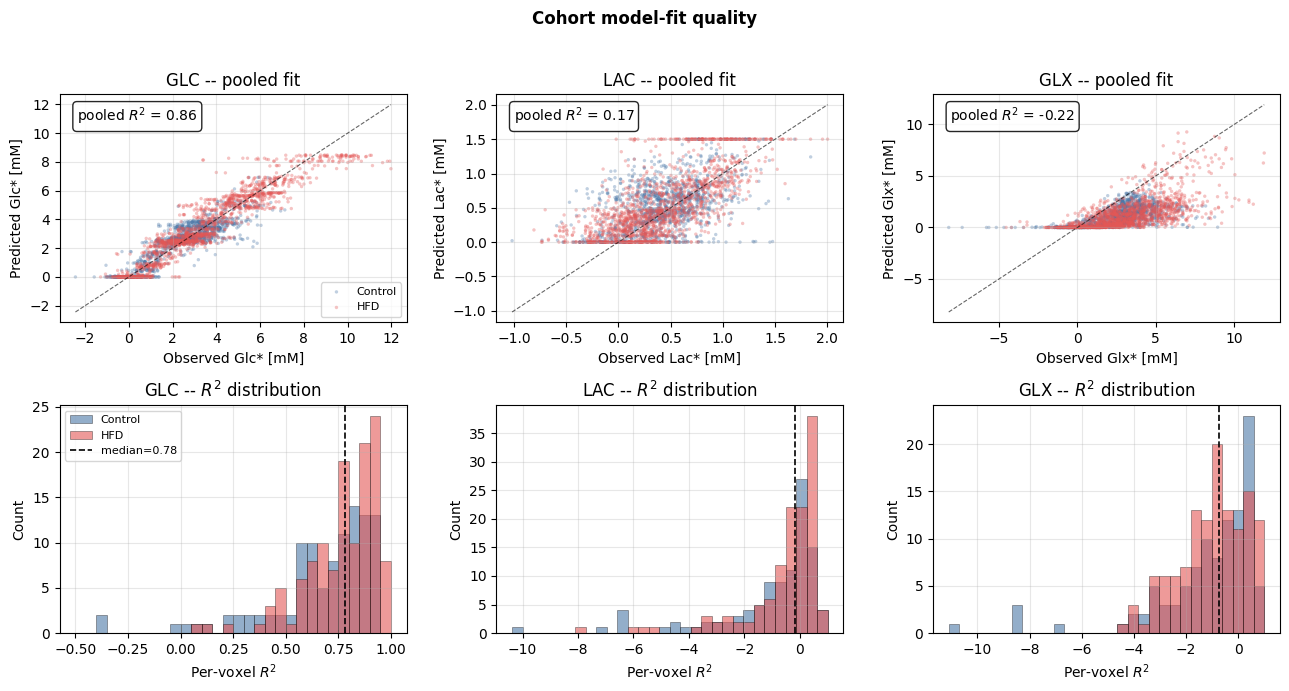

Saved /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/plotsC7_estimate_variations_oxDilution_KTfixed/paper_fig1_fit_quality.png


In [11]:
# ============================================================
# Fig 1 -- Cohort model-fit quality (pooled obs vs pred + R^2 distribution)
# ============================================================
# Inputs:  SOURCE_RESULTS_PATH (C6 joblib with per-timepoint obs/pred),
#          df_fit_diag (for filtering to fits considered analyzable).
# Output:  PLOTS_DIR / 'paper_fig1_fit_quality.png'
# Notes:   C7b's analyzed_results only stores aggregated voxel summaries
#          (voxel_flux_summary), not per-timepoint pred/obs -- so we reload
#          the C6 joblib here. No re-fitting.

# --- Load C6 per-timepoint results -----------------------------------------
b6_results = joblib.load(SOURCE_RESULTS_PATH)
print(f'Loaded {len(b6_results)} C6 fits from {SOURCE_RESULTS_PATH.name}')

# Restrict to the same fit set we analyse downstream (include_in_summary).
analyzable_keys = {(r['mouseID'], r['week']) for r in analyzed_results}
b6_subset = [r for r in b6_results if (r['mouseID'], r['week']) in analyzable_keys]
print(f'Using {len(b6_subset)} fits that are also in analyzed_results.')

# --- Tidy long-form: one row per (fit, tissue, voxel, met, timepoint) ------
METS = ('glc', 'lac', 'glx')
MET_LABELS_FIG1 = {'glc': 'Glc* [mM]', 'lac': 'Lac* [mM]', 'glx': 'Glx* [mM]'}
GROUP_COLORS = {'norm': '#4C78A8', 'dia': '#E45756'}

pvo_rows = []   # predicted-vs-observed long form
r2_rows = []    # one row per (fit, tissue, voxel, met)
for r in b6_subset:
    mid, wk, grp = r['mouseID'], r['week'], r['group']
    for tissue, tdata in r.get('tissues', {}).items():
        for vi, vr in enumerate(tdata.get('voxels', [])):
            if vr.get('pred') is None:
                continue
            t = vr['voxel_data']['time_min']
            for met in METS:
                obs = np.asarray(vr['voxel_data'][met])
                pred = np.asarray(vr['pred'][met])
                # Stack each timepoint as one row for the scatter
                for j in range(len(obs)):
                    pvo_rows.append({
                        'mouseID': mid, 'week': wk, 'group': grp,
                        'tissue': tissue, 'voxel_idx': vi, 'metabolite': met,
                        'time_min': float(t[j]), 'obs': float(obs[j]), 'pred': float(pred[j]),
                    })
                r2_rows.append({
                    'mouseID': mid, 'week': wk, 'group': grp,
                    'tissue': tissue, 'voxel_idx': vi, 'metabolite': met,
                    'r2': float(vr.get(f'r2_{met}', float('nan'))),
                })

df_pvo = pd.DataFrame(pvo_rows)
df_r2 = pd.DataFrame(r2_rows)
print(f'df_pvo: {len(df_pvo):>6d} timepoints, df_r2: {len(df_r2):>6d} (fit,voxel,met) rows.')

# --- Plot: 2 rows x 3 cols (top: pooled obs-vs-pred; bottom: R^2 hist) -----
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for col, met in enumerate(METS):
    # Top row: pooled obs vs pred scatter, colored by group
    ax = axes[0, col]
    sub = df_pvo[df_pvo['metabolite'] == met]
    for grp, color in GROUP_COLORS.items():
        gsub = sub[sub['group'] == grp]
        ax.scatter(gsub['obs'], gsub['pred'], s=6, alpha=0.35,
                   color=color, label=grp.replace('dia', 'HFD').replace('norm', 'Control'), edgecolors='none')
    if not sub.empty:
        # Identity line spanning observed range
        pct_r2_gt_05 = (sub['obs'] - sub['pred']).pow(2).le(0.05).mean() * 100
        lo = float(min(sub['obs'].min(), sub['pred'].min()))
        hi = float(max(sub['obs'].max(), sub['pred'].max()))
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.6)
        # Pooled R^2 over all timepoints in this metabolite
        ss_res = ((sub['obs'] - sub['pred']) ** 2).sum()
        ss_tot = ((sub['obs'] - sub['obs'].mean()) ** 2).sum()
        pooled_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')
        ax.text(0.05, 0.95, f'pooled $R^2$ = {pooled_r2:.2f}',
                transform=ax.transAxes, va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set_xlabel(f'Observed {MET_LABELS_FIG1[met]}')
    ax.set_ylabel(f'Predicted {MET_LABELS_FIG1[met]}')
    ax.set_title(f'{met.upper()} -- pooled fit')
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend(loc='lower right', fontsize=8)

    # Bottom row: per-(fit,voxel) R^2 histogram, stacked by group
    ax2 = axes[1, col]
    sub_r2 = df_r2[df_r2['metabolite'] == met].dropna(subset=['r2'])
    if not sub_r2.empty:
        bins = np.linspace(min(-0.5, sub_r2['r2'].min()), 1.0, 31)
        for grp, color in GROUP_COLORS.items():
            ax2.hist(sub_r2.loc[sub_r2['group'] == grp, 'r2'],
                     bins=bins, color=color, alpha=0.6, label=grp.replace('dia', 'HFD').replace('norm', 'Control'),
                     edgecolor='black', linewidth=0.4)
        ax2.axvline(sub_r2['r2'].median(), color='black', linewidth=1.2,
                    linestyle='--', label=f"median={sub_r2['r2'].median():.2f}")
    ax2.set_xlabel('Per-voxel $R^2$')
    ax2.set_ylabel('Count')
    ax2.set_title(f'{met.upper()} -- $R^2$ distribution')
    ax2.grid(True, alpha=0.3)
    if col == 0:
        ax2.legend(loc='upper left', fontsize=8)

# fig.suptitle('Fig. 1 -- Cohort model-fit quality', fontsize=12, fontweight='bold')
fig.suptitle('Cohort model-fit quality', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
out = PLOTS_DIR / 'paper_fig1_fit_quality.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {out}')


/tmp/ipykernel_97052/1774111427.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


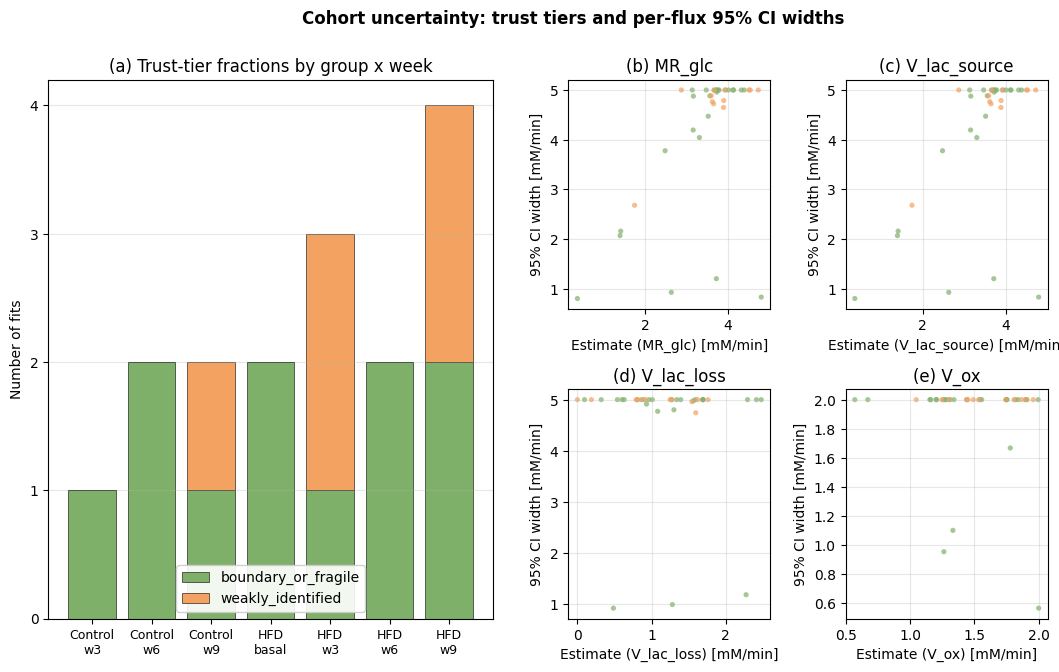

Saved /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/plotsC7_estimate_variations_oxDilution_KTfixed/paper_fig2_uncertainty.png


In [12]:
# ============================================================
# Fig 2 -- Uncertainty composite
# ============================================================
# Left panel: stacked-bar of trust-tier fractions by group x week.
# Right side (2x2): CI-width vs estimate scatter for the four fluxes that
#   carry draw-based 95% intervals in df_mouse (MR_glc, V_lac, V_ox, phi_tca).
# Inputs:  df_fit_diag (trust labels), df_mouse (estimates + draw quantiles).
# Output:  PLOTS_DIR / 'paper_fig2_uncertainty.png'

import matplotlib.gridspec as gridspec

TIER_COLORS = {
    'boundary_sensitive': '#7FB069',   # green: identifiable but at a bound
    'weakly_identified':  '#F4A261',   # orange: poorly constrained
    'degraded':           '#E76F51',   # red: numerical breakdown
    'missing':            '#B0B0B0',   # grey fallback
}
TIER_ORDER_BAR = ['boundary_sensitive', 'weakly_identified', 'degraded', 'missing']

# --- Left panel data: fit counts per (group, week, trust_label) ------------
# We treat each (mouseID, week) as ONE fit (rows of df_fit_diag are already that).
counts = (df_fit_diag.groupby(['group', 'week', 'trust_label'])
          .size().unstack(fill_value=0))
# Order weeks in canonical order if available
week_order = [w for w in m7.mf.WEEKS if w in df_fit_diag['week'].unique()]
group_week = [(g, w) for g in ['norm', 'dia'] for w in week_order
              if (g, w) in counts.index]

# --- Layout: left full-height bar | right 2x2 of CI scatters ---------------
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(2, 4, width_ratios=[2.2, 1, 1, 0.05], wspace=0.35, hspace=0.35)

ax_bar = fig.add_subplot(gs[:, 0])
xs = np.arange(len(group_week))
bottom = np.zeros(len(group_week))
for tier in TIER_ORDER_BAR:
    if tier not in counts.columns:
        continue
    heights = np.array([counts.loc[(g, w), tier] if (g, w) in counts.index else 0
                        for (g, w) in group_week], dtype=float)
    ax_bar.bar(xs, heights, bottom=bottom, color=TIER_COLORS[tier],
               edgecolor='black', linewidth=0.4, label=tier.replace('boundary_sensitive', 'boundary_or_fragile'))
    bottom += heights
# # Annotate total N atop each bar
# for x, total in zip(xs, bottom):
#     ax_bar.text(x, total + 0.15, f'N={int(total)}', ha='center', va='bottom', fontsize=8)
ax_bar.set_xticks(xs)
ax_bar.set_xticklabels([f'{g}\n{w}'.replace('norm', 'Control').replace('dia', 'HFD') for (g, w) in group_week], fontsize=9)
ax_bar.set_ylabel('Number of fits')
ax_bar.set_yticks(range(0, int(bottom.max()) + 1, 1))
ax_bar.set_title('(a) Trust-tier fractions by group x week')
ax_bar.legend(loc='lower center', fontsize=10, framealpha=0.9)
ax_bar.grid(True, axis='y', alpha=0.3)

# --- Right panels: CI-width vs estimate, one per flux ----------------------
FLUXES_FIG2 = ['MR_glc', 'V_lac_source', 'V_lac_loss', 'V_ox', 'phi_tca', 'V_TCA_total']
arr_labels = ['b', 'c', 'd', 'e']
positions = [(0, 1), (0, 2), (1, 1), (1, 2)]
for (row_i, col_i), flux, cur_label in zip(positions, FLUXES_FIG2, arr_labels):
    ax = fig.add_subplot(gs[row_i, col_i])
    qlo = f'{flux}_draw_q025'
    qhi = f'{flux}_draw_q975'
    if not {flux, qlo, qhi}.issubset(df_mouse.columns):
        ax.text(0.5, 0.5, f'{flux}: no draws', transform=ax.transAxes,
                ha='center', va='center')
        ax.set_title(flux)
        continue
    sub = df_mouse[[flux, qlo, qhi, 'trust_label']].dropna()
    width = sub[qhi] - sub[qlo]
    for tier, color in TIER_COLORS.items():
        m = sub['trust_label'] == tier
        if not m.any():
            continue
        ax.scatter(sub.loc[m, flux], width[m], s=14, color=color, alpha=0.7,
                   edgecolors='none', label=tier.replace('boundary_sensitive', 'boundary_or_fragile'))
    unit = '' if flux == 'phi_tca' else ' [mM/min]'
    ax.set_xlabel(f'Estimate ({flux}){unit}')
    ax.set_ylabel(f'95% CI width{unit}')
    ax.set_title(f"({cur_label}) {flux}")
    ax.grid(True, alpha=0.3)
    # if (row_i, col_i) == positions[0]:
    #     ax.legend(fontsize=7, loc='best')

fig.suptitle('Cohort uncertainty: trust tiers and per-flux 95% CI widths',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
out = PLOTS_DIR / 'paper_fig2_uncertainty.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {out}')


Saved mouse_level_uncertainty_MR_glc.png
Saved mouse_level_uncertainty_V_lac_loss.png
Saved mouse_level_uncertainty_V_ox.png
Saved mouse_level_uncertainty_phi_tca.png
Saved mouse_level_uncertainty_V_TCA_total.png


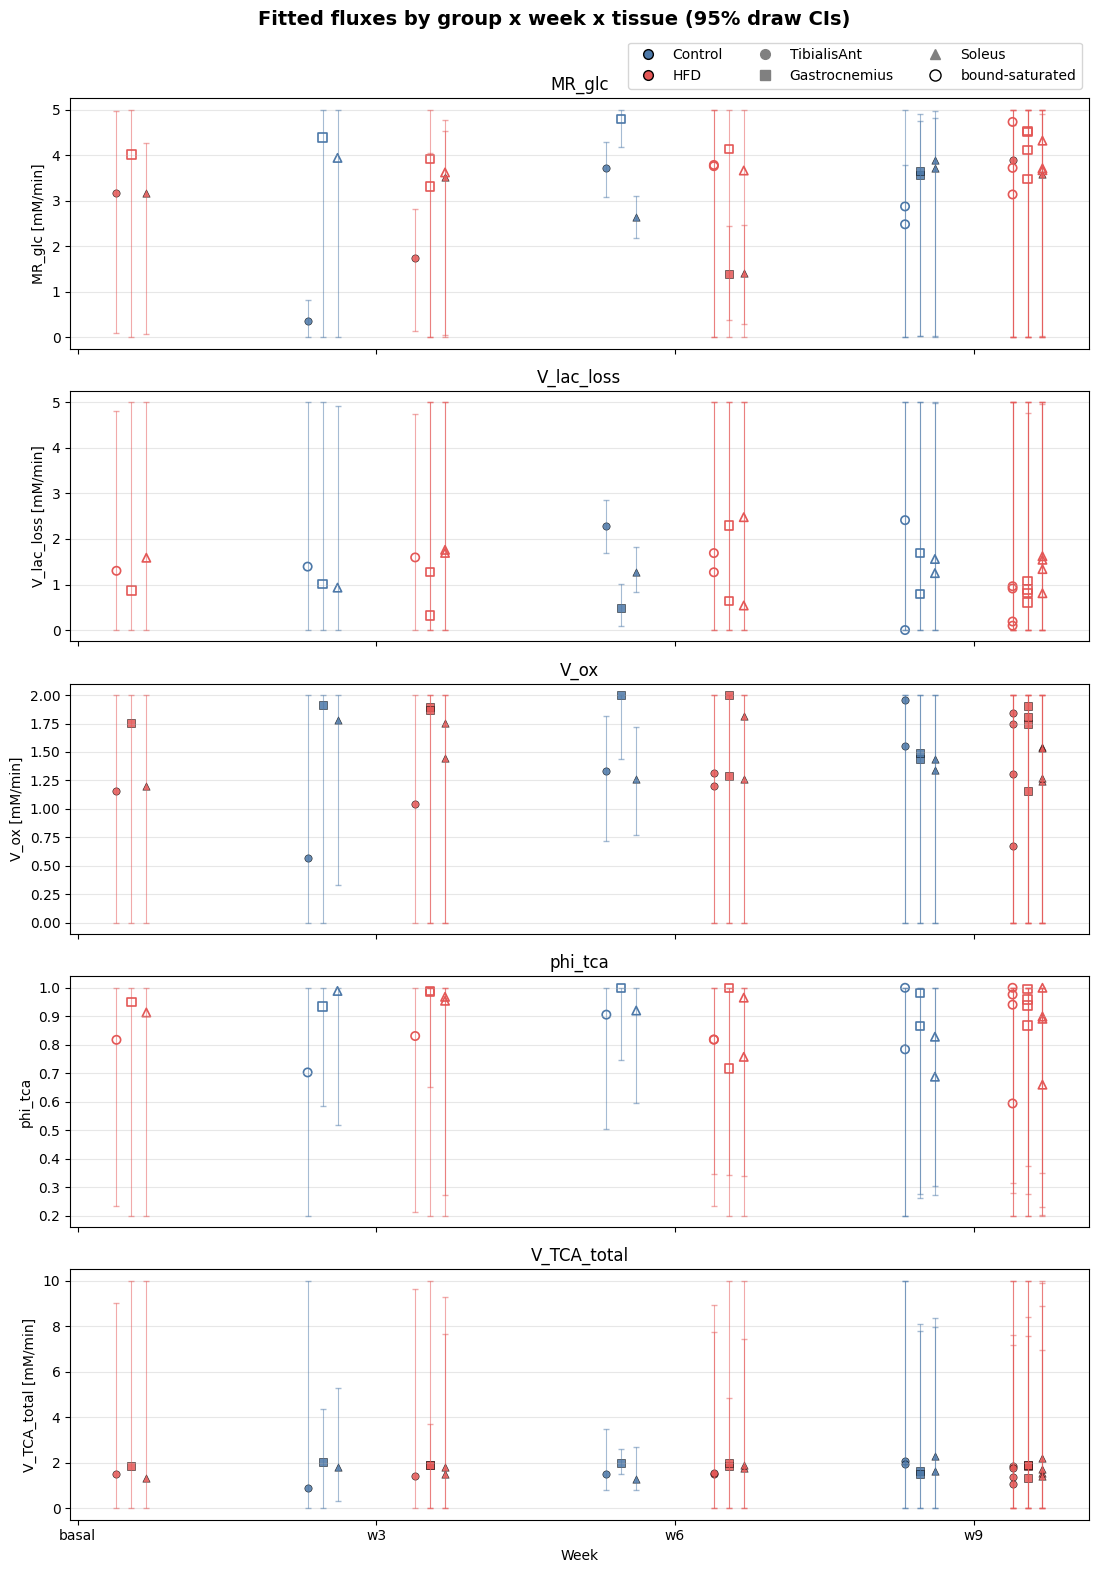

Saved /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/plotsC7_estimate_variations_oxDilution_KTfixed/paper_fig3_flux_intervals.png


In [13]:
# ============================================================
# Fig 3 -- Fitted fluxes by group x week x tissue (with 95% draw CIs)
# ============================================================
# These are the MRI-derived fluxes that go on to constrain the FBA model.
# Inputs:  df_mouse (point estimates + draw q025/q975 + saturation flags).
# Output:  PLOTS_DIR / 'paper_fig3_flux_intervals.png'  (composite)
#          plus the existing per-flux PNGs from plot_mouse_level_intervals.

FLUXES_FIG3 = ['MR_glc', 'V_lac_loss', 'V_ox', 'phi_tca', 'V_TCA_total']

# Re-use the existing per-flux plotter for supplementary detail (one PNG per flux).
for flux in FLUXES_FIG3:
    plot_mouse_level_intervals(df_mouse, flux, save_dir=PLOTS_DIR, show=False)

# --- Composite paper figure: one row per flux, x = (group, week) ----------
week_order = [w for w in m7.mf.WEEKS if w in df_mouse['week'].unique()]
tissues_present = [t for t in m7.mf.TISSUES if t in set(df_mouse['tissue'])]
TISSUE_MARKERS = {'TibialisAnt': 'o', 'Gastrocnemius': 's', 'Soleus': '^'}
GROUP_COLORS_FIG3 = {'norm': '#4C78A8', 'dia': '#E45756'}
GROUP_OFFSET = {'norm': -0.18, 'dia': 0.18}
TISSUE_DODGE = {t: (i - (len(tissues_present) - 1) / 2) * 0.05
                for i, t in enumerate(tissues_present)}

fig, axes = plt.subplots(len(FLUXES_FIG3), 1, figsize=(11, 3.2 * len(FLUXES_FIG3)),
                         sharex=True)
for ax, flux in zip(axes, FLUXES_FIG3):
    qlo = f'{flux}_draw_q025'
    qhi = f'{flux}_draw_q975'
    sat_lo = f'{flux}_lower_saturated'
    sat_hi = f'{flux}_upper_saturated'
    for wi, week in enumerate(week_order):
        for grp in ['norm', 'dia']:
            for tissue in tissues_present:
                sub = df_mouse[(df_mouse['week'] == week)
                               & (df_mouse['group'] == grp)
                               & (df_mouse['tissue'] == tissue)]
                if sub.empty:
                    continue
                x = wi + GROUP_OFFSET[grp] + TISSUE_DODGE[tissue]
                xs = np.full(len(sub), x)
                ys = sub[flux].values
                # CI errorbars (only if draws exist for this flux)
                if qlo in sub.columns and qhi in sub.columns:
                    yerr_lo = ys - sub[qlo].values
                    yerr_hi = sub[qhi].values - ys
                    yerr = np.vstack([yerr_lo, yerr_hi])
                    ax.errorbar(xs, ys, yerr=yerr, fmt='none', ecolor=GROUP_COLORS_FIG3[grp],
                                alpha=0.5, linewidth=0.8, capsize=2)
                # Saturation marker swap (open triangle) for any fit that saturates a bound
                if sat_lo in sub.columns:
                    sat_mask = sub[sat_lo].fillna(False) | sub[sat_hi].fillna(False)
                else:
                    sat_mask = pd.Series(False, index=sub.index)
                # Plain points
                ok = ~sat_mask.values
                if ok.any():
                    ax.scatter(xs[ok], ys[ok], marker=TISSUE_MARKERS[tissue],
                               color=GROUP_COLORS_FIG3[grp], s=28,
                               edgecolors='black', linewidths=0.4, alpha=0.85)
                # Saturated points (hollow)
                if (~ok).any():
                    ax.scatter(xs[~ok], ys[~ok], marker=TISSUE_MARKERS[tissue],
                               facecolors='none', edgecolors=GROUP_COLORS_FIG3[grp],
                               linewidths=1.2, s=36)
    ax.set_xticks(np.arange(len(week_order)))
    ax.set_xticklabels(week_order)
    unit = '' if flux == 'phi_tca' else ' [mM/min]'
    ax.set_ylabel(f'{flux}{unit}')
    ax.set_title(flux)
    ax.grid(True, axis='y', alpha=0.3)

# Shared legend (group color + tissue marker + saturation note)
from matplotlib.lines import Line2D
legend_handles = (
    [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
            markeredgecolor='black', markersize=7, label=g.replace('norm', 'Control').replace('dia', 'HFD'))
     for g, c in GROUP_COLORS_FIG3.items()]
    + [Line2D([0], [0], marker=TISSUE_MARKERS[t], color='gray',
              linestyle='', markersize=7, label=t) for t in tissues_present]
    + [Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor='black',
              linestyle='', markersize=8, label='bound-saturated')]
)
axes[0].legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(1.0, 1.01), fontsize=10, ncol=3)
axes[-1].set_xlabel('Week')
fig.suptitle('Fitted fluxes by group x week x tissue (95% draw CIs)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
out = PLOTS_DIR / 'paper_fig3_flux_intervals.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {out}')


Saved mouse_level_uncertainty_MR_glc.png
Saved mouse_level_uncertainty_V_lac_loss.png
Saved mouse_level_uncertainty_V_ox.png
Saved mouse_level_uncertainty_phi_tca.png
Saved mouse_level_uncertainty_V_TCA_total.png


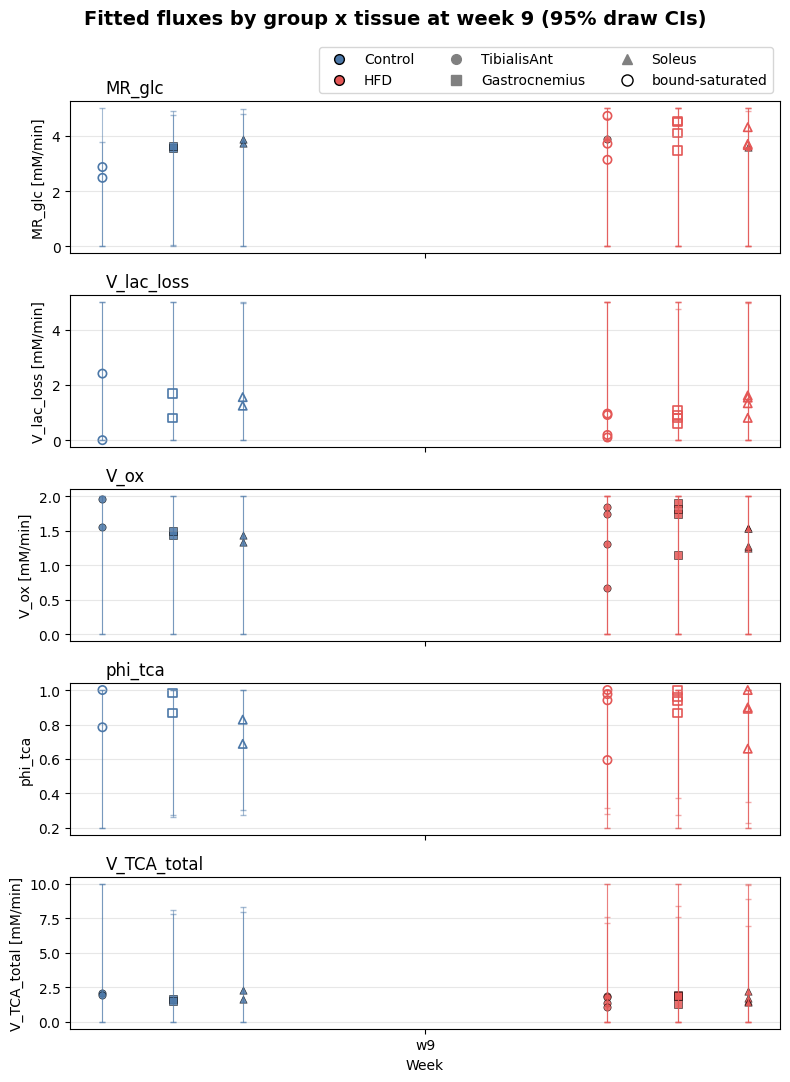

Saved /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/plotsC7_estimate_variations_oxDilution_KTfixed/paper_fig3_flux_intervals_w9.png


In [14]:
# same as above but with only w9 (used by FBA)

# ============================================================
# Fitted fluxes by group x w9 x tissue (with 95% draw CIs)
# ============================================================

FLUXES_FIG3 = ['MR_glc', 'V_lac_loss', 'V_ox', 'phi_tca', 'V_TCA_total']

# Re-use the existing per-flux plotter for supplementary detail (one PNG per flux).
for flux in FLUXES_FIG3:
    plot_mouse_level_intervals(df_mouse, flux, save_dir=PLOTS_DIR, show=False)

# --- Composite paper figure: one row per flux, x = (group, week) ----------
# week_order = [w for w in m7.mf.WEEKS if w in df_mouse['week'].unique()]
week_order = ['w9']
tissues_present = [t for t in m7.mf.TISSUES if t in set(df_mouse['tissue'])]
TISSUE_MARKERS = {'TibialisAnt': 'o', 'Gastrocnemius': 's', 'Soleus': '^'}
GROUP_COLORS_FIG3 = {'norm': '#4C78A8', 'dia': '#E45756'}
GROUP_OFFSET = {'norm': -0.18, 'dia': 0.18}
TISSUE_DODGE = {t: (i - (len(tissues_present) - 1) / 2) * 0.05
                for i, t in enumerate(tissues_present)}

fig, axes = plt.subplots(len(FLUXES_FIG3), 1, figsize=(8, 2.2 * len(FLUXES_FIG3)),
                         sharex=True)
for ax, flux in zip(axes, FLUXES_FIG3):
    qlo = f'{flux}_draw_q025'
    qhi = f'{flux}_draw_q975'
    sat_lo = f'{flux}_lower_saturated'
    sat_hi = f'{flux}_upper_saturated'
    for wi, week in enumerate(week_order):
        for grp in ['norm', 'dia']:
            for tissue in tissues_present:
                sub = df_mouse[(df_mouse['week'] == week)
                               & (df_mouse['group'] == grp)
                               & (df_mouse['tissue'] == tissue)]
                if sub.empty:
                    continue
                x = wi + GROUP_OFFSET[grp] + TISSUE_DODGE[tissue]
                xs = np.full(len(sub), x)
                ys = sub[flux].values
                # CI errorbars (only if draws exist for this flux)
                if qlo in sub.columns and qhi in sub.columns:
                    yerr_lo = ys - sub[qlo].values
                    yerr_hi = sub[qhi].values - ys
                    yerr = np.vstack([yerr_lo, yerr_hi])
                    ax.errorbar(xs, ys, yerr=yerr, fmt='none', ecolor=GROUP_COLORS_FIG3[grp],
                                alpha=0.5, linewidth=0.8, capsize=2)
                # Saturation marker swap (open triangle) for any fit that saturates a bound
                if sat_lo in sub.columns:
                    sat_mask = sub[sat_lo].fillna(False) | sub[sat_hi].fillna(False)
                else:
                    sat_mask = pd.Series(False, index=sub.index)
                # Plain points
                ok = ~sat_mask.values
                if ok.any():
                    ax.scatter(xs[ok], ys[ok], marker=TISSUE_MARKERS[tissue],
                               color=GROUP_COLORS_FIG3[grp], s=28,
                               edgecolors='black', linewidths=0.4, alpha=0.85)
                # Saturated points (hollow)
                if (~ok).any():
                    ax.scatter(xs[~ok], ys[~ok], marker=TISSUE_MARKERS[tissue],
                               facecolors='none', edgecolors=GROUP_COLORS_FIG3[grp],
                               linewidths=1.2, s=36)
    ax.set_xticks(np.arange(len(week_order)))
    ax.set_xticklabels(week_order)
    unit = '' if flux == 'phi_tca' else ' [mM/min]'
    ax.set_ylabel(f'{flux}{unit}')
    ax.set_title(flux, loc='left', x=0.05)
    ax.grid(True, axis='y', alpha=0.3)

# Shared legend (group color + tissue marker + saturation note)
from matplotlib.lines import Line2D
legend_handles = (
    [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
            markeredgecolor='black', markersize=7, label=g.replace('norm', 'Control').replace('dia', 'HFD'))
     for g, c in GROUP_COLORS_FIG3.items()]
    + [Line2D([0], [0], marker=TISSUE_MARKERS[t], color='gray',
              linestyle='', markersize=7, label=t) for t in tissues_present]
    + [Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor='black',
              linestyle='', markersize=8, label='bound-saturated')]
)
axes[0].legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(1.0, 1.01), fontsize=10, ncol=3)
axes[-1].set_xlabel('Week')
fig.suptitle('Fitted fluxes by group x tissue at week 9 (95% draw CIs)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
out = PLOTS_DIR / 'paper_fig3_flux_intervals_w9.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {out}')


In [15]:
# ============================================================
# Supplementary table -- w9 condition-level mean MRI-derived fluxes
# ============================================================
# This table accompanies the w9 fitted-flux interval plot above. It reports
# mouse-level central estimates by tissue and state so readers can inspect
# whether the fitted rates are physiologically coherent even when individual
# draw CIs are wide. Values are summarized across mouse-tissue rows, not
# across voxels, to avoid pseudoreplication.

SUPP_TABLE_WEEK = 'w9'
SUPP_TABLE_METRICS = [
    metric for metric in ['MR_glc', 'V_lac_source', 'V_lac_loss', 'V_ox', 'phi_tca', 'V_TCA_total', 'V_dil_tca']
    if metric in df_mouse.columns
]

df_w9_flux = df_mouse[df_mouse['week'] == SUPP_TABLE_WEEK].copy()

summary_parts = []
for metric in SUPP_TABLE_METRICS:
    part = (
        df_w9_flux
        .groupby(['tissue', 'group'], observed=True)
        .agg(
            n_mouse_tissue=('mouseID', 'nunique'),
            mean=(metric, 'mean'),
            sd=(metric, 'std'),
            median=(metric, 'median'),
        )
        .reset_index()
    )
    part.insert(2, 'flux', metric)
    summary_parts.append(part)

df_supp_w9_flux_means = pd.concat(summary_parts, ignore_index=True)
df_supp_w9_flux_means['state'] = (
    df_supp_w9_flux_means['group']
    .replace({'norm': 'Control', 'dia': 'HFD'})
)

# Add dia - norm contrasts for quick biological reading.
contrast_parts = []
for metric in SUPP_TABLE_METRICS:
    tmp = df_w9_flux.pivot_table(
        index='tissue', columns='group', values=metric, aggfunc='mean', observed=True
    )
    if {'norm', 'dia'}.issubset(tmp.columns):
        contrast = pd.DataFrame({
            'tissue': tmp.index,
            'flux': metric,
            'dia_minus_norm': tmp['dia'] - tmp['norm'],
            'dia_minus_norm_pct': 100.0 * (tmp['dia'] - tmp['norm']) / tmp['norm'],
        })
        contrast_parts.append(contrast)

df_supp_w9_flux_contrasts = pd.concat(contrast_parts, ignore_index=True)

df_supp_w9_flux_table = df_supp_w9_flux_means.merge(
    df_supp_w9_flux_contrasts, on=['tissue', 'flux'], how='left'
)
df_supp_w9_flux_table = df_supp_w9_flux_table[[
    'tissue', 'state', 'flux', 'n_mouse_tissue',
    'mean', 'sd', 'median', 'dia_minus_norm_pct'
]].rename(columns={'dia_minus_norm_pct': 'HFD_minus_Control_pct'}).sort_values(['tissue', 'flux', 'state'])

out_csv = PLOTS_DIR / 'supp_table_w9_mri_flux_means_by_tissue_state.csv'
df_supp_w9_flux_table.to_csv(out_csv, index=False)

print(f'Saved {out_csv}')
display(df_supp_w9_flux_table.round({
    'mean': 3, 'sd': 3, 'median': 3,
    'HFD_minus_Control_pct': 1,
}))


Saved /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/plotsC7_estimate_variations_oxDilution_KTfixed/supp_table_w9_mri_flux_means_by_tissue_state.csv


,tissue,state,flux,n_mouse_tissue,mean,sd,median,HFD_minus_Control_pct
1,Gastrocnemius,Control,MR_glc,2,3.605,0.064,3.605,15.3
0,Gastrocnemius,HFD,MR_glc,4,4.157,0.494,4.311,15.3
31,Gastrocnemius,Control,V_TCA_total,2,1.587,0.093,1.587,9.9
30,Gastrocnemius,HFD,V_TCA_total,4,1.744,0.285,1.875,9.9
37,Gastrocnemius,Control,V_dil_tca,2,0.121,0.128,0.121,-24.6
36,Gastrocnemius,HFD,V_dil_tca,4,0.091,0.067,0.098,-24.6
13,Gastrocnemius,Control,V_lac_loss,2,1.241,0.636,1.241,-31.8
12,Gastrocnemius,HFD,V_lac_loss,4,0.847,0.199,0.853,-31.8
7,Gastrocnemius,Control,V_lac_source,2,3.605,0.064,3.605,15.3
6,Gastrocnemius,HFD,V_lac_source,4,4.157,0.494,4.311,15.3


In [16]:
# ============================================================
# Table 1 -- Aggregate diagnostics (one row per group x week)
# ============================================================
# Columns:
#   n_fits, pct_boundary_sensitive, pct_weakly_identified, pct_degraded,
#   median_trust_score, median_R2_glc, median_R2_lac, median_R2_glx,
#   median_CIwidth_MRglc
# Inputs:  df_fit_diag, df_mouse, analyzed_results.
# Output:  DATA_DIR / 'paper_table1_aggregate_diagnostics.csv'

# --- Per-fit median R^2 (from analyzed_results diagnostics) ----------------
r2_rows = []
for r in analyzed_results:
    diag = r.get('diagnostics', {})
    mr2 = diag.get('mean_r2_by_met', {})
    r2_rows.append({
        'mouseID': r['mouseID'], 'week': r['week'], 'group': r['group'],
        'r2_glc': mr2.get('glc', float('nan')),
        'r2_lac': mr2.get('lac', float('nan')),
        'r2_glx': mr2.get('glx', float('nan')),
    })
df_r2_per_fit = pd.DataFrame(r2_rows)

# --- Per-fit MR_glc CI width (mean across tissues for that fit) -----------
if {'MR_glc_draw_q025', 'MR_glc_draw_q975'}.issubset(df_mouse.columns):
    df_mouse_ciw = df_mouse.assign(
        _ciw=df_mouse['MR_glc_draw_q975'] - df_mouse['MR_glc_draw_q025']
    )
    ciw_per_fit = (df_mouse_ciw.groupby(['mouseID', 'week', 'group'])
                   ['_ciw'].mean().reset_index()
                   .rename(columns={'_ciw': 'ciw_MRglc'}))
else:
    ciw_per_fit = pd.DataFrame(columns=['mouseID', 'week', 'group', 'ciw_MRglc'])

# --- Merge per-fit data ----------------------------------------------------
df_per_fit = (df_fit_diag[['mouseID', 'week', 'group', 'trust_label', 'trust_score']]
              .merge(df_r2_per_fit, on=['mouseID', 'week', 'group'], how='left')
              .merge(ciw_per_fit,    on=['mouseID', 'week', 'group'], how='left'))

# --- Aggregate to (group, week) -------------------------------------------
def _agg(sub):
    n = len(sub)
    return pd.Series({
        'n_fits': n,
        'pct_boundary_sensitive': 100.0 * (sub['trust_label'] == 'boundary_sensitive').sum() / n,
        'pct_weakly_identified':  100.0 * (sub['trust_label'] == 'weakly_identified').sum() / n,
        'pct_degraded':           100.0 * (sub['trust_label'] == 'degraded').sum() / n,
        'median_trust_score':     sub['trust_score'].median(skipna=True),
        'median_R2_glc':          sub['r2_glc'].median(skipna=True),
        'median_R2_lac':          sub['r2_lac'].median(skipna=True),
        'median_R2_glx':          sub['r2_glx'].median(skipna=True),
        'median_CIwidth_MRglc':   sub['ciw_MRglc'].median(skipna=True),
    })

df_table1 = (df_per_fit.groupby(['group', 'week'], as_index=False)
             .apply(_agg, include_groups=False).reset_index(drop=True))

# Reorder weeks if canonical order is available
if hasattr(m7, 'mf') and hasattr(m7.mf, 'WEEKS'):
    df_table1['_wk_order'] = df_table1['week'].apply(
        lambda w: m7.mf.WEEKS.index(w) if w in m7.mf.WEEKS else 99)
    df_table1 = df_table1.sort_values(['group', '_wk_order']).drop(columns='_wk_order').reset_index(drop=True)

df_table1 = df_table1.replace({'dia': 'HFD', 'norm': 'Control'})
tmparr = ['pct_boundary_or_fragile' if x == 'pct_boundary_sensitive' else x for x in df_table1.columns]
tmparr = [x[4:]+ ' (%)' if x.startswith('pct_') else x for x in tmparr]
tmparr = [x if x == 'n_fits' else x.replace('_', ' ') for x in tmparr]
df_table1.columns = tmparr

display(df_table1.round(3))

out_csv = DATA_DIR / 'paper_table1_aggregate_diagnostics.csv'
df_table1.to_csv(out_csv, index=False)
print(f'Saved {out_csv}')


,group,week,n_fits,boundary or fragile (%),weakly identified (%),degraded (%),median trust score,median R2 glc,median R2 lac,median R2 glx,median CIwidth MRglc
0,HFD,basal,2.0,100.000,0.000,0.0,0.000,0.827,-0.093,-1.522,4.690
1,HFD,w3,3.0,33.333,66.667,0.0,0.150,0.836,-0.821,-1.589,4.202
2,HFD,w6,2.0,100.000,0.000,0.0,0.075,0.794,-1.980,-2.791,4.037
3,HFD,w9,4.0,50.000,50.000,0.0,0.125,0.771,-0.617,-0.647,4.980
4,Control,w3,1.0,100.000,0.000,0.0,0.000,0.531,-1.675,0.091,3.601
5,Control,w6,2.0,100.000,0.000,0.0,0.175,0.722,-0.626,0.078,0.988
6,Control,w9,2.0,50.000,50.000,0.0,0.150,0.610,-0.461,-1.706,4.687


Saved /home/pty/work/project_MRI/extract_MRI_metabolite_concentration_and_fitting/model_fittingC/paper_table1_aggregate_diagnostics.csv
